# UBS and JPMorgan earnings calls, 2022 to 2025: topics around the two mergers

Willian Angelo · Team 10 · Bank of England employer project (CAM_DS_401) · release `2026-09-30`

The topic track for Assignment 3. It reads the analyst and management Q&A of 33 earnings calls (UBS and JPMorgan, 2022-Q1 to 2025-Q4, plus JPMorgan's First Republic deal call) and asks which subjects the calls talk about, how they changed around the 2023 acquisitions (UBS took over Credit Suisse, JPMorgan bought First Republic), and where the negative tone sits.

**Pipeline**

1. Grab the data structure built by the team (release `2026-09-30`).
2. First investigation of the sentences.
3. Prepare the dataset for modelling.
4. BERTopic: the most relevant topics for the whole dataset, the year before the mergers (2022), the merger year (2023) and the year after (2024).
5. Sentence-BERT: the same periods read through seven fixed themes, which also describe the topics.
6. Topics against the team's sentiment labels: the negative sentences of 2022, 2023, 2024 and the three years together.
7. Findings and discoveries.

**Time windows**, by calendar year and the same for both banks: 2022 is the year before the mergers, 2023 the merger year, 2024 the year after. 2025 ("later") belongs to the whole dataset only.

Outputs print transcript text. **Clear all outputs before every commit** (public repository).

## Environment

Team setup cell with `NAME = "angelo"`, then `EXPORT = "2026-09-30"`. The cells below expect `ROOT`, `DATA`, `EXPORT` and `loading`.

In [1]:
# 0.0 local Windows only, run before the setup cell: pandas loads pyarrow, whose bundled msvcp140.dll
# is older than the one torch needs, and torch then fails with WinError 1114. Harmless in Colab.
import torch

Housekeeping, not relevant to the findings: loads PyTorch first so the notebook runs on Windows.

In [2]:
# project setup - run first, do not edit except NAME
NAME = "angelo"  # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")

ok  python 3.13.15  pandas 2.2.3  data C:\local_CAM\Emp_Proj\boe-financial-analysis\data


Housekeeping: finds the project folder, installs the pinned library versions and checks them (Python 3.13, pandas 2.2.3), so anyone can rerun the notebook and get the same numbers.

In [3]:
EXPORT = "2026-09-30"  # pin the export this notebook was written against
print("exports:", loading.exports(DATA))
print("files:  ", loading.files(DATA, EXPORT))

sentences_df = loading.load(DATA, "structured_sentences.csv", EXPORT)

exports: ['2026-09-13', '2026-09-23', '2026-09-30', 'Never ever upload or change something in the folder above']
files:   ['exchange_texts.csv', 'qa_exchanges_utterance_level.csv', 'structured_sentences.csv', 'structured_utterances.csv']
loaded structured_sentences.csv  19092 rows


Fixes the analysis to the team's release of 30 September and loads its sentence file: 19,092 sentences from 33 earnings calls. Pinning the release means every number below traces back to one version of the data.

In [4]:
sentences_df

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,utterance_id,sentence_raw,is_filler_sentence
0,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38068,1,"Good morning, ladies and gentlemen.",0,"Good morning, ladies and gentlemen.",True
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,2,Welcome to JPMorgan Chase's First Quarter 2022...,0,Welcome to JPMorgan Chase's First Quarter 2022...,False
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,3,This call is being recorded.,0,This call is being recorded.,False
3,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38071,4,Your line will be muted for the duration of th...,0,Your line will be muted for the duration of th...,False
4,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38072,5,We will now go live to the presentation.,0,We will now go live to the presentation.,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19087,UBS,2025-Q4,earnings,2026-02-04,42,qa,management,Todd Tuckner,NaN,38063,11,"But look, we always believe that the IB will b...",41,"But look, we always believe that the IB will b...",False
19088,UBS,2025-Q4,earnings,2026-02-04,43,qa,analyst,Benjamin Goy,Deutsche Bank,38064,1,Thank you.,42,Thank you.,True
19089,UBS,2025-Q4,earnings,2026-02-04,44,qa,ir,Sarah Mackey,NaN,38065,1,I think there are no further questions.,43,I think there are no further questions.,False
19090,UBS,2025-Q4,earnings,2026-02-04,44,qa,ir,Sarah Mackey,NaN,38066,2,We just thank everyone for dialing in and we l...,43,We just thank everyone for dialing in and we l...,False


A first look at the release: one row per sentence, with bank, quarter, section (prepared remarks or Q&A), speaker and the filler flag the team set. This is the raw material; nothing has been chosen yet.

## 1. Grab the data structure built by the team

The team's release `2026-09-30` holds the transcripts already split into sentences, speaker turns and Q&A exchanges, with a flag for filler sentences. It is read as it is, checked against its guide, and given a few working columns. Nothing in the data folder is changed.

In [5]:
# 1.0 settings shared by every section
try:
    import torch
except OSError as e:
    raise OSError("torch failed to load because pandas loaded first: restart the kernel "
                  "and run the 0.0 cell before the setup cell") from e
import gc, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for name in ("ROOT", "DATA", "EXPORT", "loading"):
    if name not in globals():
        raise NameError(f"run the Environment cell first: {name} is not defined")
if EXPORT not in loading.exports(DATA):
    raise FileNotFoundError(f"release {EXPORT} is not in {DATA / 'results'}")

SEED = 42
OUT = ROOT / "notebooks" / "angelo" / "outputs" / EXPORT      # outputs/ is kept out of git by .git/info/exclude
if DATA in OUT.parents:
    raise RuntimeError(f"never write inside {DATA}: it holds the read-only release")
OUT.mkdir(parents=True, exist_ok=True)
FIG = OUT / "figures"                                           # charts saved for the slides
FIG.mkdir(exist_ok=True)

BANKS = ["UBS", "JPM"]
ROLES = ["analyst", "management"]
YEARS = [2022, 2023, 2024, 2025]
QUARTERS = [f"{y}-Q{q}" for y in YEARS for q in (1, 2, 3, 4)]
CALL_ID = ["bank", "quarter", "call_type"]
TURN = CALL_ID + ["position_in_call"]
KEY = TURN + ["sentence_number"]               # joins results across releases and across the team's tracks

# windows by calendar year, the same for both banks: 2022 is the year before the mergers, 2023 the merger period
# (UBS announced Credit Suisse in March and completed it in June; JPMorgan bought First Republic on 1 May),
# 2024 the year after, and 2025 the later year
WINDOWS = {"before": QUARTERS[0:4], "merger": QUARTERS[4:8], "after": QUARTERS[8:12], "later": QUARTERS[12:16]}
WINDOW_OF = {q: w for w, qs in WINDOWS.items() for q in qs}
WINDOW_NAMES = list(WINDOWS)
FOCUS_YEARS = [2022, 2023, 2024]                 # the three years the pipeline reads one by one

# breaks marked on every time chart
BREAKS = {"UBS": ("2023-Q2", "Credit Suisse consolidated"),
          "JPM": ("2024-Q2", "Visa gain, CFO-only call")}

# the one event call: JPMorgan's First Republic deal call (1 May 2023), filed under 2023-Q2 next to that
# quarter's earnings call. It stays in the corpus; results per quarter pool it with the earnings call.
EVENT = ("JPM", "2023-Q2", "event")
EVENT_NOTE = "Diamond: JPM's First Republic deal call on its own (1 May 2023)"

# chart style: one fixed colour per bank, recessive grid and axes
BANK_COLOR = {"UBS": "#2a78d6", "JPM": "#eb6834"}
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.6, "lines.linewidth": 2,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "legend.frameon": False,
})
pd.set_option("display.max_colwidth", 120)
print(f"release {EXPORT}   outputs {OUT}")

release 2026-09-30   outputs C:\local_CAM\Emp_Proj\boe-financial-analysis\notebooks\angelo\outputs\2026-09-30


Sets the rules every later step shares: the two banks, the 16 quarters, the time windows (2022 the year before the mergers, 2023 the merger year, 2024 the year after, 2025 later), the output folder and a fixed random seed. These choices define what "before" and "after" mean in every result, the same for both banks.

In [6]:
# 1.1 load the pinned release: sentences, speaker turns (utterances) and the Q&A exchanges
sent_raw = loading.load(DATA, "structured_sentences.csv", EXPORT)
utt_raw = loading.load(DATA, "structured_utterances.csv", EXPORT)
exch_raw = loading.load(DATA, "qa_exchanges_utterance_level.csv", EXPORT)

loaded structured_sentences.csv  19092 rows
loaded structured_utterances.csv  2570 rows
loaded qa_exchanges_utterance_level.csv  2473 rows


Loads the three tables the team built: 19,092 sentences, 2,570 speaker turns and 2,473 rows that link each Q&A turn to its exchange. The team's work is used as delivered.

In [7]:
# 1.2 data tests: stop if the release is not what its guide describes
FUSED = re.compile(r"\b(?:do|did|does|would|wo|have|are|should|ca|is|was|has|had|were|could)not\b", re.I)
linked = sent_raw.merge(utt_raw[TURN], on=TURN, how="left", indicator=True)
exch_linked = exch_raw.merge(utt_raw[TURN], on=TURN, how="left", indicator=True)
event_calls = set(sent_raw.loc[sent_raw["call_type"] == "event", ["bank", "quarter"]]
                  .itertuples(index=False, name=None))
earnings = sent_raw[sent_raw["call_type"] == "earnings"].groupby("bank")["quarter"].agg(lambda s: sorted(s.unique()))

checks = {
    "19,092 sentences, 2,570 utterances, 2,473 Q&A exchange rows":
        (len(sent_raw), len(utt_raw), len(exch_raw)) == (19092, 2570, 2473),
    "16 earnings calls per bank, 2022-Q1 to 2025-Q4": all(earnings[b] == QUARTERS for b in BANKS),
    "one event call, JPM 2023-Q2": event_calls == {("JPM", "2023-Q2")},
    "sentence_id unique": sent_raw["sentence_id"].is_unique,
    "cross-release key unique": not sent_raw.duplicated(KEY).any(),
    "no nulls in key columns, text or filler flag":
        sent_raw[KEY + ["section", "speaker_role", "sentence", "is_filler_sentence"]].notna().all().all(),
    "section and role values as documented":
        set(sent_raw["section"]) <= {"prepared", "qa"}
        and set(sent_raw["speaker_role"]) <= {"management", "analyst", "ir", "operator"},
    "text not rewritten (sentence equals sentence_raw)": sent_raw["sentence"].equals(sent_raw["sentence_raw"]),
    "every sentence links to its utterance": linked["_merge"].eq("both").all(),
    "every exchange row links to a Q&A utterance":
        exch_linked["_merge"].eq("both").all() and exch_raw["section"].eq("qa").all(),
    "no fused negations left": not sent_raw["sentence"].str.contains(FUSED).any(),
}
print(pd.Series(checks).map({True: "pass", False: "FAIL"}).to_string())
failed = [name for name, ok in checks.items() if not ok]
if failed:
    raise AssertionError(f"release checks failed: {failed}")

19,092 sentences, 2,570 utterances, 2,473 Q&A exchange rows    pass
16 earnings calls per bank, 2022-Q1 to 2025-Q4                 pass
one event call, JPM 2023-Q2                                    pass
sentence_id unique                                             pass
cross-release key unique                                       pass
no nulls in key columns, text or filler flag                   pass
section and role values as documented                          pass
text not rewritten (sentence equals sentence_raw)              pass
every sentence links to its utterance                          pass
every exchange row links to a Q&A utterance                    pass
no fused negations left                                        pass


Eleven automatic checks that the release matches its guide, and all pass. The corpus is complete (16 earnings calls per bank plus JPMorgan's deal call) and its text has not been altered, so no result below rests on broken data.

In [8]:
# 1.3 working columns: year, window, a turn id per utterance, a text key per sentence, and the release's
# Q&A exchange (an analyst's question with the answers to it), numbered within each call
def add_columns(df):
    df = df.copy()
    df["year"] = df["quarter"].str[:4].astype(int)
    df["window"] = df["quarter"].map(WINDOW_OF)
    df["call"] = df["bank"] + " " + df["quarter"] + " " + df["call_type"]
    df["turn_id"] = df[TURN].astype(str).agg("|".join, axis=1)
    return df

sent = add_columns(sent_raw)
utt = add_columns(utt_raw)
sent["key"] = sent[KEY].astype(str).agg("|".join, axis=1)

ex = exch_raw[TURN + ["qa_exchange_id"]].copy()
ex["exchange_id"] = ex[CALL_ID].astype(str).agg("|".join, axis=1) + "|" + ex["qa_exchange_id"].astype(str)
sent = sent.merge(ex[TURN + ["exchange_id"]], on=TURN, how="left", validate="many_to_one")
utt = utt.merge(ex[TURN + ["exchange_id"]], on=TURN, how="left", validate="one_to_one")

per_call = utt.groupby(CALL_ID)["exchange_id"].nunique()
print("Q&A exchanges per call, from the release:")
print(per_call.groupby(["bank", "call_type"]).describe()[["count", "min", "50%", "max"]].to_string())
print("Q&A utterances without an exchange id:", int((utt["section"].eq("qa") & utt["exchange_id"].isna()).sum()))

Q&A exchanges per call, from the release:
                count   min   50%   max
bank call_type                         
JPM  earnings    16.0  27.0  39.0  57.0
     event        1.0  32.0  32.0  32.0
UBS  earnings    16.0  15.0  23.0  44.0
Q&A utterances without an exchange id: 17


Adds working columns: year, window, speaker turn, a unique sentence key and the team's Q&A exchange number. The key matters most: it is how the team's sentiment labels are joined to the topics in step 6, one sentence at a time.

### Summary

The team's release of 30 September is complete and passes all eleven checks: 19,092 sentences from 16 earnings calls per bank (2022 to 2025) and JPMorgan's First Republic deal call, each with a key that other analyses can join on. Nothing in the data folder was changed. The topic work starts from the same data as the rest of the team, which keeps the tracks comparable.

## 2. First investigation of the sentences

A first look at the team's sentences before any modelling choice: the Q&A of analysts and management, without the sentences the team's filler flag marks. How many there are per call and year, what the flag removes, how the two banks run their Q&A, how often the merger is named, and how long the answers are.

In [9]:
# 2.0 helpers used by every step. Charts: 16 quarters on the x axis, the four windows named at the top, 2023 (the
# merger year) shaded, one line per bank, breaks as dotted lines. Resampling: 95% intervals from resampling whole
# answers (sentences of one answer are not independent, so the answer is the unit that is resampled).
from matplotlib.colors import LinearSegmentedColormap
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
QLABELS = [q[2:] for q in QUARTERS]                                    # 22-Q1 ...
BREAK_NOTE = "Dotted lines: " + " · ".join(f"{b} {q}, {why}" for b, (q, why) in BREAKS.items())
EVENT_X = QUARTERS.index(EVENT[1]) - 0.3                               # just left of JPM's 2023-Q2 point
X = np.arange(len(QUARTERS))

def quarter_axis(ax):
    ax.set_xticks(X, QLABELS, rotation=45, fontsize=8)
    ax.set_xlim(-0.5, len(QUARTERS) - 0.5)

def mark_windows(ax):
    merger = [QUARTERS.index(q) for q in WINDOWS["merger"]]
    ax.axvspan(merger[0] - 0.5, merger[-1] + 0.5, color="#efeee8", lw=0, zorder=0)
    for w, qs in WINDOWS.items():
        mid = (QUARTERS.index(qs[0]) + QUARTERS.index(qs[-1])) / 2
        ax.text(mid, 1.01, w, transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                fontsize=7, color="#898781")

def mark_breaks(ax, banks=BANKS):
    for b in banks:
        ax.axvline(QUARTERS.index(BREAKS[b][0]), color=BANK_COLOR[b], lw=1, ls=":", zorder=0)

def mark_event(ax, value, label="JPM deal call"):
    # the First Republic deal call alone, as a hollow diamond beside the 2023-Q2 point
    ax.scatter([EVENT_X], [value], marker="D", s=36, facecolors="white", edgecolors=BANK_COLOR["JPM"],
               linewidths=1.5, zorder=4, label=label)

def time_axis(ax, title, banks=BANKS):
    quarter_axis(ax)
    mark_windows(ax)
    mark_breaks(ax, banks)
    ax.set_title(title, loc="left", pad=14)

def bank_lines(ax, series, title):
    # series indexed by (bank, quarter); each line labelled at its last point
    for b in BANKS:
        s = series.xs(b, level="bank").reindex(QUARTERS).astype(float)
        ax.plot(X, s.to_numpy(), color=BANK_COLOR[b], marker="o", ms=3.5, label=b)
    time_axis(ax, title)

B = 1000

def resample_weights(rng, n_units, n=B):
    # n bootstrap samples as counts: row i says how often each unit was drawn in sample i
    W = np.zeros((n, n_units))
    np.add.at(W, (np.arange(n)[:, None], rng.integers(0, n_units, size=(n, n_units))), 1)
    return W

def unit_counts(df, col, cats):
    return pd.crosstab(df["turn_id"], df[col]).reindex(columns=cats, fill_value=0).to_numpy()

def shares(df, col, cats, rng):
    # point shares per category, and B bootstrap replicates from resampled utterances
    counts = unit_counts(df, col, cats)
    boot = resample_weights(rng, len(counts)) @ counts
    return counts.sum(axis=0) / counts.sum(), boot / boot.sum(axis=1, keepdims=True)

def unit(X):
    return X / np.linalg.norm(X, axis=-1, keepdims=True)

No output: chart and statistics helpers used later (one colour per bank, 2023 shaded, ranges from resampling whole answers). Housekeeping, not a finding.

In [10]:
# 2.1 the team's sentences: the Q&A of analysts and management, without the sentences its filler flag marks.
# Sentences per call, and per bank and year.
team = sent[(sent["section"] == "qa") & sent["speaker_role"].isin(ROLES) & ~sent["is_filler_sentence"]].reset_index(drop=True)
coverage = pd.DataFrame({
    "statements": utt.groupby(CALL_ID).size(),
    "sentences": sent.groupby(CALL_ID).size(),
    "Q&A sentences": sent[sent["section"] == "qa"].groupby(CALL_ID).size(),
    "team's Q&A sentences": team.groupby(CALL_ID).size(),
}).fillna(0).astype(int)
print(f"{len(sent):,} sentences in {sent['call'].nunique()} calls; Q&A sentences of analysts and management without "
      f"the filler flag: {len(team):,} (UBS {int((team['bank'] == 'UBS').sum()):,}, JPM {int((team['bank'] == 'JPM').sum()):,})")
display(coverage["team's Q&A sentences"].unstack("quarter").reindex(columns=QUARTERS))
by_year = team.groupby(["bank", "year"]).agg(calls=("call", "nunique"), sentences=("key", "size"),
                                             analyst_pct=("speaker_role", lambda r: 100 * (r == "analyst").mean()))
by_year["sentences_per_call"] = by_year["sentences"] / by_year["calls"]
display(by_year.round(1))

19,092 sentences in 33 calls; Q&A sentences of analysts and management without the filler flag: 10,957 (UBS 4,589, JPM 6,368)


quarter         2022-Q1  2022-Q2  2022-Q3  2022-Q4  2023-Q1  2023-Q2  2023-Q3  \
bank call_type                                                                  
JPM  earnings     386.0    384.0    284.0    414.0    333.0    338.0    333.0   
     event          NaN      NaN      NaN      NaN      NaN    191.0      NaN   
UBS  earnings     341.0    453.0    364.0    301.0    299.0    333.0    264.0   

quarter         2023-Q4  2024-Q1  2024-Q2  2024-Q3  2024-Q4  2025-Q1  2025-Q2  \
bank call_type                                                                  
JPM  earnings     251.0    428.0    311.0    478.0    291.0    491.0    528.0   
     event          NaN      NaN      NaN      NaN      NaN      NaN      NaN   
UBS  earnings     383.0    239.0    207.0    237.0    262.0    210.0    141.0   

quarter         2025-Q3  2025-Q4  
bank call_type                    
JPM  earnings     456.0    471.0  
     event          NaN      NaN  
UBS  earnings     279.0    276.0

calls  sentences  analyst_pct  sentences_per_call
bank year                                                   
JPM  2022      4       1468         29.1               367.0
     2023      5       1446         30.6               289.2
     2024      4       1508         27.3               377.0
     2025      4       1946         23.6               486.5
UBS  2022      4       1459         34.8               364.8
     2023      4       1279         36.5               319.8
     2024      4        945         39.4               236.2
     2025      4        906         37.2               226.5

The team's Q&A sentences of analysts and management: 10,957 (UBS 4,589, JPMorgan 6,368). UBS's Q&A shrinks after the merger, from 1,459 sentences in 2022 to 945 in 2024, while JPMorgan's stays at about 1,450 to 1,500 and grows in 2025. The banks must therefore be compared on shares, not counts.

In [11]:
# 2.2 what the team's filler flag marks in the Q&A of analysts and management.
# Prints transcript text: clear outputs before committing.
pre = sent[(sent["section"] == "qa") & sent["speaker_role"].isin(ROLES)]
flagged = pre[pre["is_filler_sentence"]]
DIGIT = re.compile(r"\d")
print(f"filler flag: {len(flagged):,} of {len(pre):,} sentences ({100 * len(flagged) / len(pre):.1f}%), "
      f"up to {flagged['sentence'].str.split().str.len().max()} words, "
      f"{int(flagged['sentence'].str.contains(DIGIT).sum())} with a number")
print(flagged["sentence"].value_counts().head(12).to_string())
print("share flagged, % of each group's Q&A sentences")
display((100 * pre.groupby(["bank", "speaker_role"])["is_filler_sentence"].mean()).unstack().round(1))

filler flag: 2,237 of 13,194 sentences (17.0%), up to 5 words, 0 with a number
sentence
Thank you.              432
Yeah.                   343
Okay.                   225
Good morning.           157
Thanks.                 119
Hi.                     111
Yes.                     78
Thank you very much.     61
Got it.                  57
All right.               44
Great.                   37
Sure.                    37
share flagged, % of each group's Q&A sentences


speaker_role,analyst,management
bank,,
JPM,31.8,9.6
UBS,28.7,8.0


The team's filler flag removes 2,237 of 13,194 Q&A sentences (17%), all short courtesies such as "Thank you." and "Yeah." with no number in them: about 30% of analyst sentences and 8% to 10% of management sentences. It cleans greetings out of the conversation without touching its content.

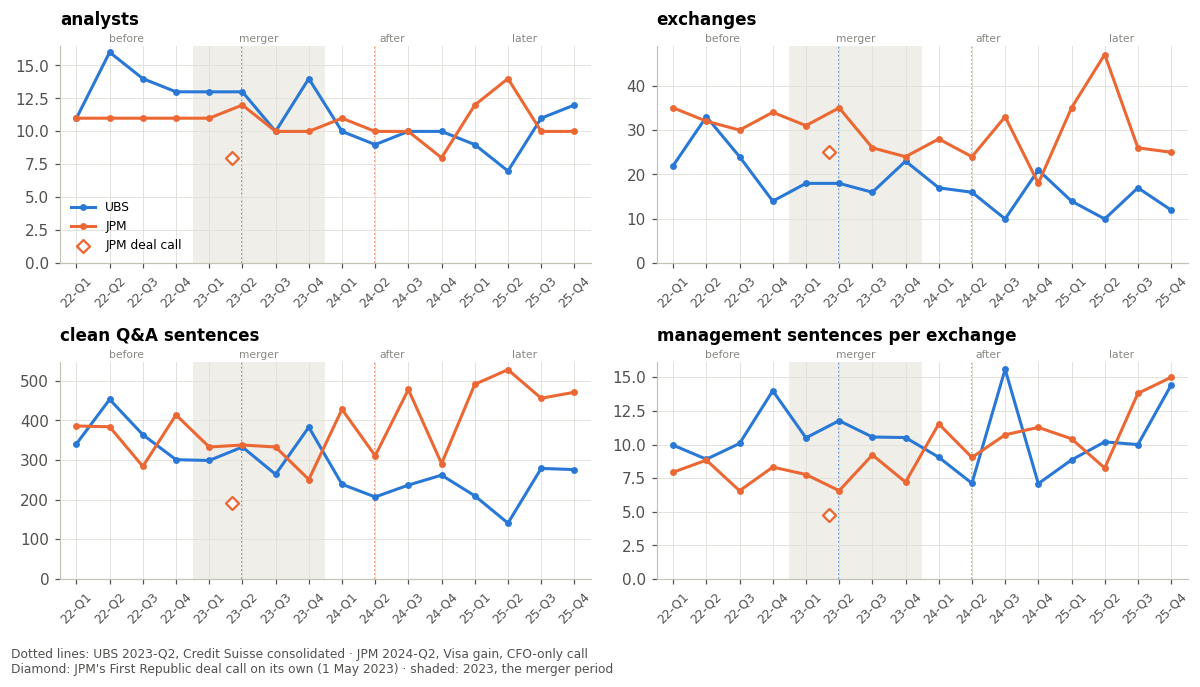

analysts  exchanges  clean Q&A sentences  \
bank call_type                                             
JPM  earnings       10.8       30.2                386.1   
     event           8.0       25.0                191.0   
UBS  earnings       11.4       17.8                286.8   

                management sentences  management sentences per exchange  
bank call_type                                                           
JPM  earnings                  281.8                                9.5  
     event                     120.0                                4.8  
UBS  earnings                  181.6                               10.5

clean Q&A sentences per year: {'JPM': {2022: 1468, 2023: 1446, 2024: 1508, 2025: 1946}, 'UBS': {2022: 1459, 2023: 1279, 2024: 945, 2025: 906}}


In [12]:
# 2.3 Q&A volume per call: analysts, exchanges with a clean analyst sentence, and how much management says
# per exchange. Lines: the earnings calls; diamond: the JPM deal call on its own.
turns = utt[utt["section"] == "qa"]
asked = team[team["speaker_role"] == "analyst"]
volume = pd.DataFrame({
    "analysts": turns[turns["speaker_role"] == "analyst"].groupby(CALL_ID)["speaker_name"].nunique(),
    "exchanges": asked.groupby(CALL_ID)["exchange_id"].nunique(),
    "clean Q&A sentences": team.groupby(CALL_ID).size(),
    "management sentences": team[team["speaker_role"] == "management"].groupby(CALL_ID).size(),
})
volume["management sentences per exchange"] = volume["management sentences"] / volume["exchanges"]
panels = ["analysts", "exchanges", "clean Q&A sentences", "management sentences per exchange"]
fig, axes = plt.subplots(2, 2, figsize=(11, 6.2))
for ax, col in zip(axes.flat, panels):
    bank_lines(ax, volume[col].xs("earnings", level="call_type"), col)
    mark_event(ax, volume.loc[EVENT, col])
    ax.set_ylim(bottom=0)
axes[0, 0].legend(loc="lower left", fontsize=8)
fig.text(0.01, 0.005, BREAK_NOTE + "\n" + EVENT_NOTE + " · shaded: 2023, the merger period",
         fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.05, 1, 1))
fig.savefig(FIG / "fig_2.3_qa_volume.png", dpi=150, bbox_inches="tight")
plt.show()
display(volume.groupby(["bank", "call_type"]).mean().round(1))
print("clean Q&A sentences per year:", team.groupby(["bank", "year"]).size().unstack().to_dict("index"))

How the two banks run their Q&A: about 11 analysts per call at both, but JPMorgan has more exchanges (30 against 18 per call) and its deal call (the diamond) was shorter. Context rather than a finding: the formats differ, which is another reason to compare shares.

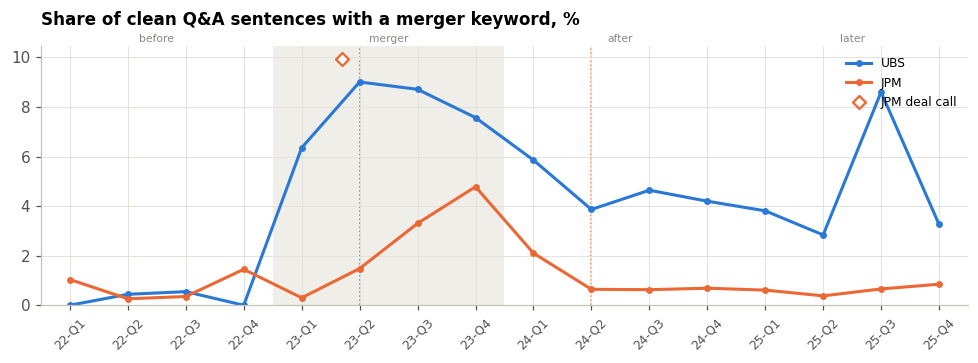

year,2022,2023,2024,2025,share_% all years
bank,,,,,
JPM,12,48,16,12,1.4
UBS,4,101,44,45,4.2


2022 hits, UBS:
    And I know that Wealthfront is not yet integrated within UBS, but maybe just a quick qualitative comment on how Wealthfront is doing in such a volatile environment regard
    So, it's not for us to update you on how they are doing, so – but I can tell you that, you know, we have prepared everything for this acquisition to be executed, and we'r
    Can you just confirm that and how you going on about your bidding out the US offering without the Wealthfront acquisition.
    And on the other side, it shows the flexibility of our investment bank in terms of the allocation of resources to move quickly from a market that is more micro related to


In [13]:
# 2.4 keyword baseline for merger talk, per quarter. Before 2023 a hit can be another deal (an acquisition
# that was planned or done elsewhere), so this is a rough count, not a measure of the merger.
MERGER_KW = re.compile(r"(?i:credit suisse|first republic|\bintegrat\w*|\bacquisi\w*|\bmerger\w*)|\bCS\b|\bFRC\b")
team["merger_keyword"] = team["sentence"].str.contains(MERGER_KW)
kw_share = 100 * team[team["call_type"] == "earnings"].groupby(["bank", "quarter"])["merger_keyword"].mean()
fig, ax = plt.subplots(figsize=(9, 3.4))
bank_lines(ax, kw_share, "Share of clean Q&A sentences with a merger keyword, %")
mark_event(ax, 100 * team.loc[team["call_type"] == "event", "merger_keyword"].mean())
ax.set_ylim(bottom=0)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
fig.savefig(FIG / "fig_2.4_merger_keywords.png", dpi=150, bbox_inches="tight")
plt.show()
kw = team.pivot_table(index="bank", columns="year", values="merger_keyword", aggfunc="sum")
kw["share_% all years"] = 100 * team.groupby("bank")["merger_keyword"].mean()
display(kw.round(1))
print("2022 hits, UBS:")
for s in team.loc[(team["bank"] == "UBS") & (team["year"] == 2022) & team["merger_keyword"], "sentence"]:
    print("   ", s[:170])

A simple keyword count for merger talk ("Credit Suisse", "First Republic", "integration", "acquisition", "merger"): at UBS 4 sentences in 2022, 101 in 2023, 44 in 2024 and 45 in 2025; at JPMorgan 12, 48, 16 and 12. The merger is clearly a UBS subject, and the 2022 UBS hits are about another deal (Wealthfront). This rough count is the yardstick the models are checked against.

In [14]:
# 2.5 answer length: words per management answer and clean sentences per answer, by bank and year
answers = utt[(utt["section"] == "qa") & (utt["speaker_role"] == "management")].copy()
answers["words"] = answers["text"].str.split().str.len()
length = answers.groupby(["bank", "year"]).agg(answers=("words", "size"), median_words=("words", "median"))
length["clean_sentences_per_answer"] = (team[team["speaker_role"] == "management"].groupby(["bank", "year", "turn_id"])
                                        .size().groupby(["bank", "year"]).mean())
display(length.unstack("bank").round(1))

answers      median_words        clean_sentences_per_answer     
bank     JPM  UBS          JPM    UBS                        JPM  UBS
year                                                                 
2022     203  133         53.0  117.0                        5.8  7.3
2023     214   86         73.5  189.5                        5.5  9.4
2024     152   83        104.0  151.0                        9.2  6.9
2025     265   60         38.0  244.5                        6.6  9.8

UBS management answers are long and get longer (median 117 words in 2022, 245 in 2025), while JPMorgan's are short. Long answers are why the models read single sentences: a whole UBS answer would be cut off at the models' input limit. Relevant for the method, not a business finding.

### Summary

The team's Q&A holds 10,957 sentences from analysts and management once its filler flag is applied. The banks run their calls differently: JPMorgan has more exchanges per call, UBS gives longer answers, and UBS's Q&A shrinks from 2022 to 2024 while JPMorgan's holds steady. A keyword count already points to the story: merger words are rare at UBS in 2022, jump in 2023 (101 sentences) and stay well above the 2022 level after, while JPMorgan's merger talk is a small peak in 2023.

For the project, this sets the expectation that the models should find a UBS merger subject and little at JPMorgan, and it fixes the rule of comparing shares, not counts.

## 3. Prepare the dataset for modelling

The modelling corpus is built from the team's sentences with as few changes as possible: editorial notes in square brackets come out of the text, sentences of four words or fewer are dropped for the topic models, and courtesy and procedure sentences are tagged but kept. Then every sentence is turned into a vector with two Sentence-BERT models, which steps 4 and 5 share.

In [15]:
# 3.1 text for the transformers: the raw sentence, minus editorial notes in square brackets ("[indiscernible]",
# "[year-on-year]"). Nothing else is removed: stop words, negations and numbers stay, because the models read them.
# Stop words are used only to name BERTopic's topics (4.1). `text_plain` is the same text with curly quotes and long
# dashes written as plain characters; no model reads it except in the robustness check 4.9.
BRACKET = re.compile(r"\[[^\]]*\]")
TYPOGRAPHY = str.maketrans({"\u2018": "'", "\u2019": "'", "\u201c": '"', "\u201d": '"', "\u2013": "-", "\u2014": "-",
                            "\u2026": "...", "\u00a0": " "})
sent["had_bracket"] = sent["sentence"].str.contains(BRACKET)
sent["text"] = (sent["sentence"].str.replace(BRACKET, " ", regex=True)
                .str.replace(r"\s+([,.;:?!])", r"\1", regex=True)
                .str.replace(r"\s{2,}", " ", regex=True).str.strip())
sent["text_plain"] = sent["text"].map(lambda s: s.translate(TYPOGRAPHY))
sent["typography_changed"] = sent["text_plain"] != sent["text"]
sent["n_words"] = sent["text"].str.split().str.len().fillna(0).astype(int)
MAX_SHORT = 4          # topic models also drop sentences of 4 words or fewer ("Clear.", "That's helpful.")

# courtesy and procedure sentences the release's filler flag leaves behind ("Thanks for taking my questions.",
# "My second question is on capital.", "Let me take that one."). They are tagged, not removed: every sentence keeps its
# place in the corpus and its join key, and 6.5 shows what the results look like without them.
low, nw = sent["text"].str.lower(), sent["n_words"]
PROCEDURAL = {
    "thanks": low.str.contains(r"\b(?:thanks?|thank you|appreciate[ds]?)\b") & (nw <= 8),
    "question count": (low.str.contains(r"\bquestions?\b|\bfollow[- ]?ups?\b")
                       & low.str.contains(r"\b(?:first|second|third|last|final|one more|two|three|quick|another|couple)\b"
                                          r"|\bfollow[- ]?ups?\b") & (nw <= 9)),
    "routing": low.str.contains(r"\b(?:go ahead|please proceed|line is open|next question|stand ?by|"
                                r"let me (?:ask|take|turn)|move on to|turn it over|pass it (?:on|over)|"
                                r"hand (?:it )?over)\b") & (nw <= 9),
    "praise": ((low.str.contains(r"\b(?:good|fair|great|excellent|interesting|helpful|useful) "
                                 r"(?:question|colou?r|perspective|context|detail)\b") & (nw <= 9))
               | (low.str.contains(r"\b(?:that's|that is|that was|that makes) (?:very |really |super |a |an )*"
                                   r"(?:helpful|clear|great|good|fair|perfect|useful|sense|interesting)\b") & (nw <= 8))),
}
sent["is_procedural"] = np.logical_or.reduce(list(PROCEDURAL.values()))
sent["procedural_rule"] = np.select(list(PROCEDURAL.values()), list(PROCEDURAL), default="")
print("sentences with an editorial bracket:", sent.groupby("bank")["had_bracket"].sum().to_dict())
print("sentences with curly quotes or long dashes (plain-character copy differs):", sent.groupby("bank")["typography_changed"].sum().to_dict())
print("sentences tagged as courtesy or procedure:", sent.groupby("bank")["is_procedural"].sum().to_dict())

sentences with an editorial bracket: {'JPM': 10, 'UBS': 39}
sentences with curly quotes or long dashes (plain-character copy differs): {'JPM': 599, 'UBS': 1075}
sentences tagged as courtesy or procedure: {'JPM': 890, 'UBS': 755}


Prepares the text the models read, changing as little as possible: only 49 editorial notes in square brackets are removed, and negations, numbers and common words stay because they carry meaning. Courtesy and procedure sentences (thanks, question counts) are tagged, not deleted, so every sentence stays joinable with the team's sentiment labels.

**One sentence, a different text for each model.** The Sentence-BERT and BERTopic models read the sentence as spoken: only editorial notes in square brackets are taken out. The sentiment models of the other track read a cleaned copy with stop words, negations and numbers removed and the words reduced to their base form. Both start from the same release and the same sentences, so results are always joined on the sentence key (bank, quarter, call type, position in call, sentence number) and never on the text. Cleaning the text differently changes what a model sees, not which sentence a label belongs to; this is why no sentence is deleted here beyond the release's own flag and the four-word rule of 3.2. Section 4.9 shows how sensitive the topic model is even to a change as small as plain quotes.

In [16]:
# 3.2 filter funnel. The shared base is the team's own filler flag, so every track counts the same
# sentences; the topic track adds one step of its own (short sentences out) and reports it here.
steps = {
    "all sentences": pd.Series(True, index=sent.index),
    "Q&A section only": sent["section"] == "qa",
    "analysts and management (operator, IR out)": sent["speaker_role"].isin(ROLES),
    "release filler flag false (shared base)": ~sent["is_filler_sentence"],
    f"more than {MAX_SHORT} words (topic models)": sent["n_words"] > MAX_SHORT,
}
keep, rows, masks = pd.Series(True, index=sent.index), [], {}
for step, cond in steps.items():
    keep &= cond
    masks[step] = keep.copy()
    n = sent.loc[keep, "bank"].value_counts()
    rows.append({"step": step, **{b: int(n.get(b, 0)) for b in BANKS}, "total": int(keep.sum())})
funnel = pd.DataFrame(rows).set_index("step")
funnel["kept_%"] = (100 * funnel["total"] / funnel["total"].iloc[0]).round(1)

base = sent[masks["release filler flag false (shared base)"]].reset_index(drop=True)
qa = sent[keep].reset_index(drop=True)
qa["merger_keyword"] = qa["text"].str.contains(MERGER_KW)        # the keyword search of 2.4, on the corpus
display(funnel)
print(f"shared base {len(base):,} sentences · topic corpus {len(qa):,} sentences")
print("from the JPM deal call:", int((qa["call_type"] == "event").sum()))
print(f"courtesy and procedure sentences kept but tagged: {int(qa['is_procedural'].sum()):,} "
      f"({100 * qa['is_procedural'].mean():.1f}% of the topic corpus)")
display(qa.pivot_table(index=["bank", "speaker_role"], columns="window", values="key", aggfunc="count",
                       margins=True).reindex(columns=WINDOW_NAMES + ["All"]))

,UBS,JPM,total,kept_%
step,,,,
all sentences,9187,9905,19092,100.0
Q&A section only,5551,8219,13770,72.1
"analysts and management (operator, IR out)",5520,7674,13194,69.1
release filler flag false (shared base),4589,6368,10957,57.4
more than 4 words (topic models),4316,5743,10059,52.7


shared base 10,957 sentences · topic corpus 10,059 sentences
from the JPM deal call: 172
courtesy and procedure sentences kept but tagged: 293 (2.9% of the topic corpus)


window             before  merger  after  later    All
bank speaker_role                                     
JPM  analyst          373     396    359    393   1521
     management       933     929   1012   1348   4222
UBS  analyst          471     420    335    317   1543
     management       893     777    553    550   2773
All                  2670    2522   2259   2608  10059

Builds the modelling corpus: the team's 10,957 sentences minus 898 sentences of four words or fewer, which carry no subject for a topic model. 10,059 sentences remain (UBS 4,316, JPMorgan 5,743), about 2,300 to 2,700 per year, enough to model each year on its own in step 4.

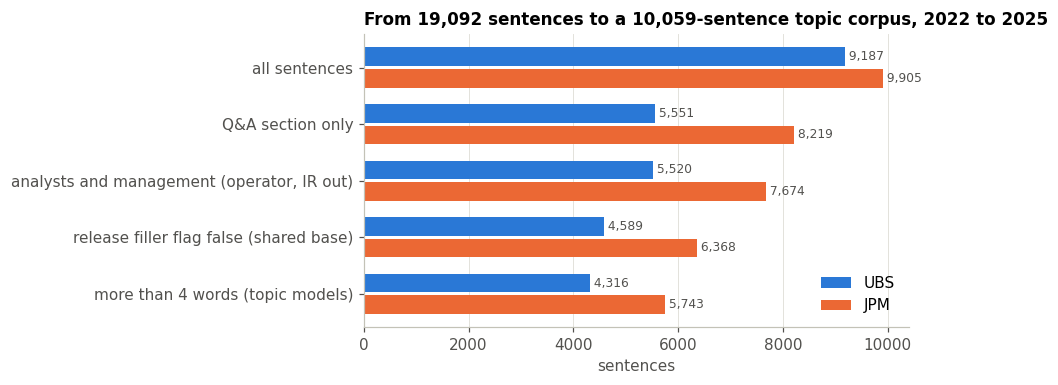

In [17]:
# 3.3 filter funnel with reasons
fig, ax = plt.subplots(figsize=(8.5, 3.6))
y, h = np.arange(len(funnel)), 0.38
for i, b in enumerate(BANKS):
    ys = y + (i - 0.5) * h
    ax.barh(ys, funnel[b], height=h - 0.05, color=BANK_COLOR[b], label=b)
    for yy, v in zip(ys, funnel[b]):
        ax.text(v, yy, f" {v:,}", va="center", fontsize=8, color="#52514e")
ax.set_yticks(y, funnel.index)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlabel("sentences")
ax.legend(loc="lower right")
ax.set_title(f"From {funnel['total'].iloc[0]:,} sentences to a "
             f"{funnel['total'].iloc[-1]:,}-sentence topic corpus, 2022 to 2025", loc="left")
plt.tight_layout()
fig.savefig(FIG / "fig_3.3_funnel.png", dpi=150, bbox_inches="tight")
plt.show()

The same filtering as a chart, from 19,092 sentences to the 10,059 the models read. Useful for the report's data slide; not a finding.

In [18]:
# 3.4 what the four-word rule drops and what the courtesy tag marks. Prints transcript text: clear outputs before committing.
pre = sent[(sent["section"] == "qa") & sent["speaker_role"].isin(ROLES)]
short = pre[~pre["is_filler_sentence"] & (pre["n_words"] <= MAX_SHORT)]
print(f"{MAX_SHORT} words or fewer, kept by the team's flag: {len(short):,} sentences, "
      f"{int(short['text'].str.contains(DIGIT).sum())} with a number")
print(short["text"].value_counts().head(12).to_string())
print("\nshort sentences: 15 random examples")
for s in short["text"].sample(15, random_state=SEED):
    print("   ", s)

tagged = qa[qa["is_procedural"]]
print(f"\ncourtesy and procedure sentences kept but tagged (is_procedural): {len(tagged):,}")
print(tagged["procedural_rule"].value_counts().to_string())
print("share tagged, %, per bank:", (100 * qa.groupby("bank")["is_procedural"].mean()).round(1).to_dict(),
      "| per window:", (100 * qa.groupby("window")["is_procedural"].mean()).round(1).to_dict())
print("15 random tagged examples")
for s in tagged["text"].sample(15, random_state=SEED):
    print("   ", s)
print("\nsentences with curly quotes or long dashes, topic corpus, per bank:",
      qa.groupby("bank")["typography_changed"].agg(["sum", "mean"]).round(3).to_dict("index"))

4 words or fewer, kept by the team's flag: 898 sentences, 17 with a number
text
Thanks a lot.                12
That's great.                12
Understood.                  11
Two questions, please.       11
That's helpful.              10
Sorry.                        8
Yeah, exactly.                8
Exactly.                      8
Thanks for the questions.     8
Thank you so much.            7
Thanks for that.              6
Good question.                6

short sentences: 15 random examples
    And then, finally buybacks.
    Plus Basel.
    As a quick follow-up.
    What has changed?
    May 23rd.
    So, that's my question.
    Thank you both.
    Thanks, Steve.
    Like, why not?
    I get it.
    I get it.
    For sure.
    Happy to clarify that.
    And banks will consolidate.
    Jeremy – I agree.

courtesy and procedure sentences kept but tagged (is_procedural): 293
procedural_rule
question count    128
thanks            124
praise             28
routing            13
share

Shows what the four-word rule removes ("Understood.", "Two questions, please.") and what the courtesy tag marks (293 sentences, 2.9%, spread evenly over the years). Neither changes the subjects of the calls, and 6.5 checks the results without the tagged sentences.

In [19]:
# 3.5 save the corpora (parquet, in the outputs folder): the topic corpus and the shared base's keys
cols = ["key", "sentence_id", "utterance_id", "bank", "quarter", "year", "window", "call_type", "call_date",
        "position_in_call", "sentence_number", "speaker_role", "speaker_name", "speaker_institution",
        "turn_id", "exchange_id", "text", "n_words", "is_procedural"]
qa[cols].to_parquet(OUT / "qa_sentences.parquet", index=False)
base[["key", "sentence_id", "bank", "quarter", "call_type", "speaker_role"]].to_csv(OUT / "base_keys.csv", index=False)
funnel.to_csv(OUT / "filter_funnel.csv")
print(f"wrote qa_sentences.parquet ({len(qa):,}), base_keys.csv ({len(base):,}) and filter_funnel.csv")

wrote qa_sentences.parquet (10,059), base_keys.csv (10,957) and filter_funnel.csv


Saves the corpus and the team's sentence keys in the outputs folder, so other analyses can join their results to the same sentences. Housekeeping.

In [20]:
# 3.6 sentence embeddings with two pre-trained Sentence-BERT models, cached next to the row keys and the text
# fingerprints they belong to (a cache_key is the sentence key plus a hash of its text, so changed text is never
# served from an old cache).
# These are the vectors before fine-tuning (5.3 adds the fine-tuned ones). MiniLM also feeds BERTopic (step 4).
import hashlib
from sentence_transformers import SentenceTransformer

qa["cache_key"] = [f"{k}#{hashlib.md5(t.encode()).hexdigest()[:8]}" for k, t in zip(qa["key"], qa["text"])]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODELS = {"MiniLM": "sentence-transformers/all-MiniLM-L6-v2",
          "mpnet": "sentence-transformers/all-mpnet-base-v2"}

def free_gpu():
    # a SentenceTransformer holds a reference to itself, so `del` alone leaves its weights on the GPU
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

def encode(model, texts, batch_size=64):
    return model.encode([str(t) for t in texts], batch_size=batch_size, normalize_embeddings=True,
                        convert_to_numpy=True, show_progress_bar=False)

def cached(name, keys):
    # vectors saved by an earlier run, used only if they belong to exactly these sentences in this order
    path, key_path = OUT / f"emb_qa_{name}.npy", OUT / f"emb_qa_{name}_keys.csv"
    if path.exists() and key_path.exists() and pd.read_csv(key_path)["key"].tolist() == list(keys):
        return np.load(path)
    return None

def save_vectors(name, E, keys):
    np.save(OUT / f"emb_qa_{name}.npy", E)
    pd.Series(list(keys), name="key").to_csv(OUT / f"emb_qa_{name}_keys.csv", index=False)   # keys here are cache keys

def embed(tag, texts, keys, batch_size=64):
    E = cached(tag, keys)
    if E is not None:
        print(f"{tag}: loaded from emb_qa_{tag}.npy")
        return E
    model = SentenceTransformer(MODELS[tag], device=DEVICE)
    t0 = time.time()
    E = encode(model, texts, batch_size)
    print(f"{tag}: {E.shape[0]:,} x {E.shape[1]} in {time.time() - t0:.0f}s on {DEVICE}, "
          f"max_seq_length {model.max_seq_length}")
    save_vectors(tag, E, keys)
    del model
    free_gpu()
    return E

emb = {tag: embed(tag, qa["text"], qa["cache_key"], batch_size=64 if tag == "MiniLM" else 32) for tag in MODELS}
for tag, E in emb.items():
    norms = np.linalg.norm(E, axis=1)
    print(f"{tag:7s} {E.shape[0]:,} x {E.shape[1]}   norms {norms.min():.3f} to {norms.max():.3f}")

C:\local_CAM\Emp_Proj\boe-financial-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MiniLM: loaded from emb_qa_MiniLM.npy
mpnet: loaded from emb_qa_mpnet.npy
MiniLM  10,059 x 384   norms 1.000 to 1.000
mpnet   10,059 x 768   norms 1.000 to 1.000


Turns every sentence into two vectors that capture its meaning, with the pre-trained MiniLM and mpnet models; sentences that mean similar things get similar vectors. Steps 4 and 5 both start from these vectors, so topics and themes are built on the same reading of each sentence.

### Summary

The modelling corpus is the team's sentences with three light, documented changes: editorial notes removed, sentences of four words or fewer dropped (898), and courtesy sentences tagged but kept (293). It holds 10,059 sentences, UBS 4,316 and JPMorgan 5,743, about 2,300 to 2,700 per year, each turned into two Sentence-BERT vectors. Every sentence keeps its key, so the topic results can be joined to the team's sentiment labels one sentence at a time.

Little cleaning means the models see what was actually said, and the same sentences can be compared across the team's tracks.

## 4. BERTopic: the most relevant topics

BERTopic groups sentences that mean similar things and names each group by the words that set it apart from the others (class-based TF-IDF). Nobody tells it which subjects exist, so it shows the agenda as the calls set it. Each sentence becomes a vector (MiniLM, from 3.6); UMAP squeezes the vectors into five dimensions; HDBSCAN finds dense groups, and sentences that fit no group stay unassigned. One model is fitted on both banks and all 16 quarters, so a topic means the same thing for UBS and JPMorgan in every quarter. Topics are labelled automatically by their top words; no topic is named or edited by hand.

**Tuning.** The setting that matters most is HDBSCAN's minimum cluster size, the smallest group that counts as a topic. It is tried at 15, 25, 40, 60, 80, 100, 150 and 200 sentences, each with three UMAP seeds, and every setting is scored on three properties:

- **Stability:** do the same topics come back with another random start? Adjusted Rand index (ARI) between the seed-42 run and the two other seeds, on the sentences both runs assign.
- **Coherence:** do a topic's top 10 words actually appear together? Normalised pointwise mutual information (NPMI) of every pair of top words, counted over speaker turns, from -1 (never together) to 1 (always together), averaged over topics. A single sentence is too short a context for ten words, so the speaker turn is the unit, as in the standard coherence measures that count co-occurrence within a window or document (Röder, Both and Hinneburg, 2015). The sentence-level value is reported as a check.
- **Diversity:** the share of distinct words among all topics' top words; 1 means no two topics share a top word.

**Rule for the final setting, fixed before the run:** the highest topic quality, coherence times diversity (Dieng, Ruiz and Blei, 2020), among the settings whose topics are stable across seeds (mean ARI of at least 0.80, "good" agreement in Steinley's 2004 scale). The rule replaces a choice by eye with published measures.

**Merger-related topics, rule fixed before the run:** a topic is merger-related when the share of its sentences with a merger keyword (2.4) is at least four times the corpus rate and at least 10 of its sentences have one.

**Four reads of the same corpus.** The whole dataset (2022 to 2025) is modelled once (4.2 to 4.9), so a topic means the same thing for both banks in every year and the years can be compared. Then each of the three focus years (2022, 2023, 2024) gets a model of its own (4.10), with the same method and rule and minimum cluster sizes scaled to one year, because a subject that matters in one year only can be too small for the whole-dataset model. 4.11 matches each year's topics to the whole-dataset topics, and 4.12 reads the merger year across both banks. 4.13 and 4.14 then measure how the topics changed: in what they are about, and at UBS against JPMorgan.

In [21]:
# 4.1 stop list for the topic labels only (CountVectorizer), never applied to the text the models read
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

name_tokens = {t for n in utt_raw["speaker_name"].dropna().unique() for t in re.findall(r"[a-z]{2,}", n.lower())}
other_names = {  # short forms, and executives named in the Q&A who never speak
    "steve", "ben", "nick", "andy", "charlie", "ralph", "colm", "kelleher", "iqbal", "khan",
    "marianne", "jen", "jennifer", "doug", "mary", "daniel", "pinto", "sergio", "todd", "jamie", "jeremy", "mikael"}
filler_words = {  # contraction fragments and spoken fillers, plus time words
    "ve", "ll", "re", "don", "didn", "doesn", "isn", "wasn", "aren", "won", "wouldn", "couldn", "haven", "hasn",
    "just", "thank", "thanks", "okay", "ok", "right", "good", "great", "morning", "yeah", "yes", "sure",
    "know", "think", "maybe", "wanted", "guess", "really", "actually", "obviously", "look", "mean",
    "kind", "sort", "bit", "little", "lot", "going", "terms", "thing", "things", "way", "say", "said",
    "got", "like", "want", "talk", "talked", "talking", "question", "questions", "helpful", "color", "colour",
    "quarter", "quarters", "year", "years", "today",
    # BERTopic strips apostrophes before counting words, so contractions arrive as one word
    "thats", "dont", "im", "ill", "id", "youre", "theyre", "weve", "whats", "doesnt", "didnt", "isnt", "wasnt",
    "shouldnt", "wont", "cant", "ive", "youve", "lets", "theres", "hes", "wouldnt", "couldnt", "arent", "havent",
    "hasnt", "et", "cetera", "guys"}
NAMES = name_tokens | other_names
NAMES |= {n + "s" for n in NAMES}                                   # possessives: "Jamie's" arrives as "jamies"
STOP_WORDS = sorted(ENGLISH_STOP_WORDS | NAMES | filler_words)
pd.Series(STOP_WORDS, name="token").to_csv(OUT / "stoplist_topic_labels.csv", index=False)
print(f"{len(STOP_WORDS)} stop words: {len(ENGLISH_STOP_WORDS)} English, {len(name_tokens)} speaker-name tokens, "
      f"{len(other_names)} other names, {len(filler_words)} fillers")

623 stop words: 318 English, 91 speaker-name tokens, 22 other names, 93 fillers


Builds the list of words left out of the topic names only (common English words, speaker names and spoken fillers, 623 in all); the models still read every word. It keeps the labels readable: no topic is named after a person or a filler.

UMAP for 3 seeds in 62s
8 settings x 3 seeds clustered and scored in 20s


,topics,"topics, other seeds",unassigned %,largest topic %,agreement across seeds (ARI),"coherence (NPMI, turns)",diversity,topic quality,"coherence (NPMI, sentences)","topic quality, sentence context",name words in top-10
min_cluster_size,,,,,,,,,,,
15,159,149 / 159,31.206,2.853,0.942,-0.170,0.682,-0.116,-0.402,-0.274,0
25,96,106 / 98,30.421,4.165,0.887,-0.090,0.752,-0.067,-0.335,-0.252,0
40,68,68 / 67,32.707,4.165,0.885,-0.022,0.788,-0.017,-0.282,-0.222,0
60,36,43 / 41,31.584,14.753,0.824,0.060,0.831,0.050,-0.166,-0.138,0
80,31,31 / 32,32.816,14.753,0.934,0.054,0.858,0.046,-0.186,-0.160,0
100,25,28 / 22,36.485,14.753,0.954,0.067,0.872,0.058,-0.158,-0.137,0
150,17,17 / 15,40.511,17.527,0.931,0.149,0.882,0.132,-0.036,-0.032,0
200,11,2 / 11,42.688,17.527,0.451,0.175,0.909,0.159,0.015,0.013,0


stable settings (ARI >= 0.8): [15, 25, 40, 60, 80, 100, 150]; chosen minimum cluster size: 150; with sentences as the coherence context the rule would choose 150


,unit,data,topics,unassigned %
run,,,,
minimum 15,sentence,2022 to 2025,159,31.2
minimum 25,sentence,2022 to 2025,96,30.4
minimum 40,sentence,2022 to 2025,68,32.7
minimum 60,sentence,2022 to 2025,36,31.6
minimum 80,sentence,2022 to 2025,31,32.8
minimum 100,sentence,2022 to 2025,25,36.5
minimum 150 (chosen),sentence,2022 to 2025,17,40.5
minimum 200,sentence,2022 to 2025,11,42.7


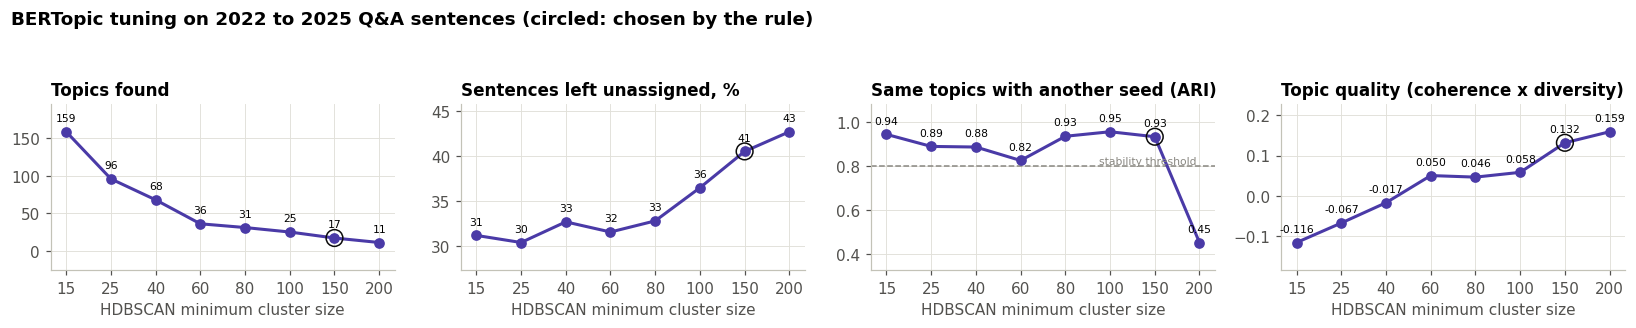

In [22]:
# 4.2 tuning: eight minimum cluster sizes, each with three UMAP seeds. UMAP runs once per seed; BERTopic then
# clusters the reduced vectors, so all settings of one seed see the same reduction. Seed 42 is the full BERTopic
# fit (topics, words); seeds 43 and 44 only check whether the groups come back. Coherence counts word pairs with
# BERTopic's own text cleaning and vocabulary, over speaker turns (main) and over single sentences (check).
from bertopic import BERTopic
from bertopic.dimensionality import BaseDimensionalityReduction
from umap import UMAP
from hdbscan import HDBSCAN
from scipy import sparse
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import adjusted_rand_score

GRID = [15, 25, 40, 60, 80, 100, 150, 200]
MIN_ARI = 0.80                                     # "good" agreement (Steinley 2004)
SEEDS = [SEED, SEED + 1, SEED + 2]
UMAP_ARGS = {"n_neighbors": 15, "n_components": 5, "min_dist": 0.0, "metric": "cosine"}
docs = qa["text"].tolist()

t0 = time.time()
reduced = {s: UMAP(random_state=s, **UMAP_ARGS).fit_transform(emb["MiniLM"]) for s in SEEDS}
print(f"UMAP for {len(SEEDS)} seeds in {time.time() - t0:.0f}s")

def vectorizer():
    return CountVectorizer(stop_words=STOP_WORDS, ngram_range=(1, 2), min_df=5)

def clusterer(m):
    return HDBSCAN(min_cluster_size=m, min_samples=5, metric="euclidean", cluster_selection_method="eom",
                   prediction_data=True)

def fit_bertopic(m, seed=SEED):
    model = BERTopic(umap_model=BaseDimensionalityReduction(), hdbscan_model=clusterer(m),
                     vectorizer_model=vectorizer(), top_n_words=10, calculate_probabilities=False)
    topics, _ = model.fit_transform(docs, embeddings=reduced[seed])
    return model, np.asarray(topics)

def topic_words(model, n=10):
    # BERTopic pads a topic with blank words when it has fewer than n
    return {t: [w for w, _ in model.get_topic(t) if w][:n] for t in sorted(set(model.topics_)) if t != -1}

def agreement(a, b):
    # adjusted Rand index on the sentences both runs assign to a topic
    ok = (a != -1) & (b != -1)
    return adjusted_rand_score(a[ok], b[ok])

# word presence per sentence and per speaker turn, as BERTopic counts words (letters and digits only)
clean_docs = [re.sub(r"[^A-Za-z0-9 ]+", "", d.replace("\n", " ").replace("\t", " ")) for d in docs]
vocab_vec = vectorizer().fit(clean_docs)
VOCAB = vocab_vec.vocabulary_
in_sentence = (vocab_vec.transform(clean_docs) > 0).astype(np.int32)
turn_codes, turn_ids = pd.factorize(qa["turn_id"])
to_turn = sparse.csr_matrix((np.ones(len(turn_codes)), (turn_codes, np.arange(len(turn_codes)))),
                            shape=(len(turn_ids), len(turn_codes)))
in_turn = ((to_turn @ in_sentence) > 0).astype(np.int32)

def npmi(words, X):
    # mean NPMI over all pairs of the words; a pair that never appears together scores -1
    cols = X[:, [VOCAB[w] for w in words]].tocsc()
    p = np.asarray(cols.sum(axis=0)).ravel() / X.shape[0]
    co = (cols.T @ cols).toarray() / X.shape[0]
    pairs = [(i, j) for i in range(len(words)) for j in range(i + 1, len(words))]
    return np.mean([-1.0 if co[i, j] == 0 else np.log(co[i, j] / (p[i] * p[j])) / -np.log(co[i, j])
                    for i, j in pairs])

fits, tuning = {}, []
t0 = time.time()
for m in GRID:
    fits[m] = fit_bertopic(m)
    labels = {SEED: fits[m][1], **{s: clusterer(m).fit_predict(reduced[s]) for s in SEEDS[1:]}}
    words = topic_words(fits[m][0])
    sizes = pd.Series(labels[SEED][labels[SEED] != -1]).value_counts()
    diversity = len({w for ws in words.values() for w in ws}) / sum(len(ws) for ws in words.values())
    coherence = np.mean([npmi(ws, in_turn) for ws in words.values()])
    coherence_sent = np.mean([npmi(ws, in_sentence) for ws in words.values()])
    tuning.append({
        "min_cluster_size": m, "topics": len(words),
        "topics, other seeds": " / ".join(str(len(set(labels[s]) - {-1})) for s in SEEDS[1:]),
        "unassigned %": 100 * (labels[SEED] == -1).mean(),
        "largest topic %": 100 * sizes.max() / len(docs),
        "agreement across seeds (ARI)": np.mean([agreement(labels[SEED], labels[s]) for s in SEEDS[1:]]),
        "coherence (NPMI, turns)": coherence, "diversity": diversity,
        "topic quality": coherence * diversity,
        "coherence (NPMI, sentences)": coherence_sent, "topic quality, sentence context": coherence_sent * diversity,
        "name words in top-10": sum(any(p in NAMES for p in w.split()) for ws in words.values() for w in ws),
    })
print(f"{len(GRID)} settings x {len(SEEDS)} seeds clustered and scored in {time.time() - t0:.0f}s")
tuning = pd.DataFrame(tuning).set_index("min_cluster_size")

stable = tuning[tuning["agreement across seeds (ARI)"] >= MIN_ARI]
MIN_TOPIC = stable["topic quality"].idxmax()
display(tuning.round(3))
print(f"stable settings (ARI >= {MIN_ARI}): {stable.index.tolist()}; chosen minimum cluster size: {MIN_TOPIC}; "
      f"with sentences as the coherence context the rule would choose {stable['topic quality, sentence context'].idxmax()}")

runs = pd.DataFrame([{"run": f"minimum {m}" + (" (chosen)" if m == MIN_TOPIC else ""), "unit": "sentence",
                      "data": "2022 to 2025", "topics": str(r["topics"]), "unassigned %": f"{r['unassigned %']:.1f}"}
                     for m, r in tuning.iterrows()]).set_index("run")
display(runs)
tuning.round(4).to_csv(OUT / "topic_tuning.csv")
runs.to_csv(OUT / "topic_runs.csv")

panels = [("topics", "Topics found", "{:.0f}"), ("unassigned %", "Sentences left unassigned, %", "{:.0f}"),
          ("agreement across seeds (ARI)", "Same topics with another seed (ARI)", "{:.2f}"),
          ("topic quality", "Topic quality (coherence x diversity)", "{:.3f}")]
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
gx = np.arange(len(GRID))
axes[2].axhline(MIN_ARI, color="#898781", lw=1, ls="--")
axes[2].text(len(GRID) - 1, MIN_ARI, "stability threshold ", ha="right", va="bottom", fontsize=7, color="#898781")
for ax, (col, title, fmt) in zip(axes, panels):
    ax.plot(gx, tuning[col], color="#4a3aa7", marker="o")
    ax.scatter([GRID.index(MIN_TOPIC)], [tuning.loc[MIN_TOPIC, col]], s=120, facecolors="none", edgecolors="#0b0b0b",
               zorder=3)
    for i, m in enumerate(GRID):
        ax.annotate(fmt.format(tuning.loc[m, col]), (i, tuning.loc[m, col]), xytext=(0, 7), textcoords="offset points",
                    ha="center", fontsize=7)
    ax.set_xticks(gx, GRID)
    ax.set_xlabel("HDBSCAN minimum cluster size")
    ax.set_title(title, loc="left")
    ax.margins(y=0.25)
fig.suptitle("BERTopic tuning on 2022 to 2025 Q&A sentences (circled: chosen by the rule)", x=0.01, ha="left",
             fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig(FIG / "fig_4.2_topic_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

Tries eight minimum topic sizes, three random starts each, and scores them on stability, coherence and diversity. The rule picks a minimum of 150 sentences: 17 topics that come back almost unchanged with other random starts (agreement 0.93) and have the best coherence among the stable settings; the next size up (200) is not stable (0.45). The choice is made by published measures, not by eye; the price is that 40.5% of sentences belong to no topic.

In [23]:
# 4.3 the final model and its topics. Each topic is labelled automatically by its top words (a word already inside
# an earlier two-word term is skipped); step 5 adds its main theme. Coherence per topic as in 4.2. A topic is
# merger-related by the rule fixed above.
topic_model, topics = fits[MIN_TOPIC]
qa["topic"] = topics
words = topic_words(topic_model)

def short_label(ws, n=3):
    chosen, seen = [], set()
    for w in ws:
        if set(w.split()) <= seen:
            continue
        chosen.append(w)
        seen |= set(w.split())
        if len(chosen) == n:
            break
    return ", ".join(chosen)

def topic_label(t):
    return "unassigned" if t == -1 else f"{t}: {short_label(words[t])}"

counts = pd.crosstab(qa["topic"], qa["bank"])
share_bank = 100 * counts / counts.sum()
MERGER_RATE = qa["merger_keyword"].mean()
kw = qa.groupby("topic")["merger_keyword"].agg(["mean", "sum"]).drop(index=-1)
MERGER_TOPICS = kw.index[(kw["mean"] >= 4 * MERGER_RATE) & (kw["sum"] >= 10)].tolist()
topic_table = pd.DataFrame({
    "label": pd.Series({t: topic_label(t) for t in words}),
    "sentences": counts.sum(axis=1),
    "UBS %": share_bank["UBS"], "JPM %": share_bank["JPM"],
    "analyst %": 100 * pd.crosstab(qa["topic"], qa["speaker_role"], normalize="index")["analyst"],
    "merger keyword %": 100 * kw["mean"],
    "coherence": pd.Series({t: npmi(ws, in_turn) for t, ws in words.items()}),
    "top words": pd.Series({t: ", ".join(ws[:7]) for t, ws in words.items()}),
}).drop(index=-1).sort_values("sentences", ascending=False)
topic_table["merger-related"] = topic_table.index.isin(MERGER_TOPICS)
qa["topic_label"] = qa["topic"].map(topic_label)
topic_table.round(3).to_csv(OUT / "topic_info.csv")
qa[["key", "sentence_id", "topic", "topic_label"]].to_csv(OUT / "topics_sentence.csv", index=False)
print(f"{len(topic_table)} topics; unassigned {100 * (qa['topic'] == -1).mean():.1f}% of sentences; corpus "
      f"merger-keyword rate {100 * MERGER_RATE:.1f}%; merger-related topics: {[topic_label(t) for t in MERGER_TOPICS]}")
display(topic_table.round(2))

17 topics; unassigned 40.5% of sentences; corpus merger-keyword rate 2.8%; merger-related topics: ['10: credit suisse, swiss, switzerland']


,label,sentences,UBS %,JPM %,analyst %,merger keyword %,coherence,top words,merger-related
0,"0: let, risk, answer",1763,14.34,19.92,20.48,0.11,0.12,"let, risk, answer, time, second, couple, point",False
1,"1: clients, wealth, business",484,7.39,2.87,23.35,2.69,0.25,"clients, wealth, business, wealth management, management, client, advisors",False
2,"2: billion, cost, million",409,5.72,2.82,33.01,1.47,0.22,"billion, cost, million, expenses, ratio, expense, costincome",False
3,"3: nii, gwm, income",380,4.19,3.47,44.74,3.16,0.15,"nii, gwm, income, net income, headwinds, guidance, net",False
4,"4: lending, loan, loan growth",317,1.14,4.67,35.96,2.52,0.12,"lending, loan, loan growth, card, loans, growth, real",False
5,"5: deposit, deposits, migration",305,2.62,3.34,36.72,1.64,0.24,"deposit, deposits, migration, beta, mix, consumer, rate",False
6,"6: capital, excess, deploy",287,2.22,3.33,33.45,2.09,0.24,"capital, excess, excess capital, deploy, requirements, capital requirements, return",False
7,"7: banking, banks, bank",263,1.48,3.47,30.04,1.52,0.10,"banking, banks, bank, investment, investment banking, investment bank, regional",False
8,"8: rates, curve, rate",259,1.46,3.41,28.57,0.00,0.16,"rates, curve, rate, fed, cuts, yield, treasury",False
9,"9: net new, asia, assets",230,4.12,0.91,37.83,2.61,0.32,"net new, new, asia, net, assets, new money, fee",False


The 17 topics of the whole dataset, named automatically by their top words. The largest (1,763 sentences) is spoken framing with no subject ("let, risk, answer"); the rest are business subjects: wealth and clients, costs, net interest income (NII, with GWM, UBS's wealth division), lending, deposits, capital, banks, rates, net new assets, buybacks and markets. One topic is merger-related by the rule: "credit suisse, swiss, switzerland", 221 sentences, 45% of them with a merger keyword, almost all from UBS.

In [24]:
# 4.4 three sentences nearest each topic's centre (MiniLM vectors), printed so a reader can check the automatic
# labels; nothing in the analysis uses them. Prints transcript text: clear outputs before committing.
E = emb["MiniLM"]
topic_arr = qa["topic"].to_numpy()
for t in topic_table.index:
    idx = np.flatnonzero(topic_arr == t)
    nearest = idx[np.argsort(-(E[idx] @ E[idx].mean(axis=0)))[:3]]
    print(f"\n{topic_label(t)} · {len(idx)} sentences")
    for i in nearest:
        print(f"   {qa.at[i, 'bank']} {qa.at[i, 'quarter']} {qa.at[i, 'speaker_role'][:4]}  {qa.at[i, 'text'][:160]}")


0: let, risk, answer · 1763 sentences
   JPM 2025-Q3 mana  So, that's how we think about it.
   JPM 2022-Q4 mana  So we just want to be clear about that.
   UBS 2024-Q2 mana  So, you know, as I said, I gave some views on considerations that we – that we will factor in.

1: clients, wealth, business · 484 sentences
   UBS 2025-Q4 mana  And in addition, we are very focused on net new client acquisition in the context of wealth transfer as well.
   UBS 2022-Q3 mana  And therefore, you see the – you see clients moving to get more advice and do more mandate business with us.
   JPM 2025-Q1 mana  And so we try to be more complete and invest in technology and work more closely with our clients.

2: billion, cost, million · 409 sentences
   UBS 2025-Q3 mana  So we have 3 billion that we expect to convert a significant part to net saves over the course of 2026 and drive to our underlying cost-income ratio target by t
   UBS 2022-Q3 mana  So, we mentioned, for example, that we're executing this

Prints the three sentences closest to each topic's centre, so a reader can check that the automatic labels make sense; nothing in the analysis uses them. They match: cost saves for the costs topic, the NII outlook for the NII topic, the integration of Credit Suisse for the merger topic.

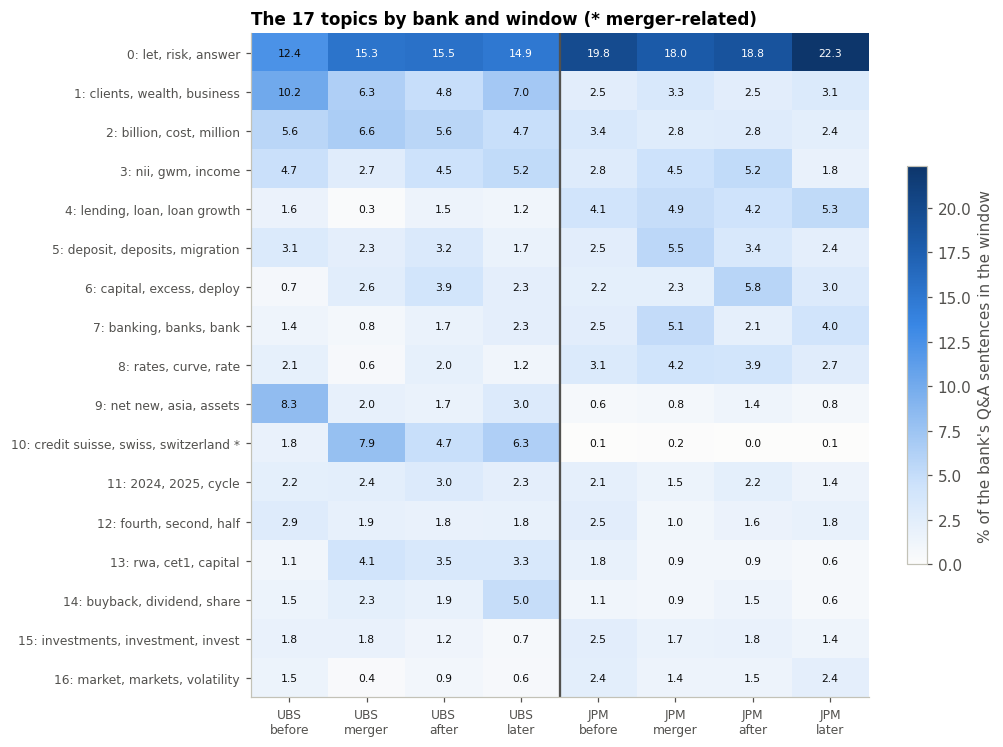

changes from before (2022) to after (2024) whose 95% interval excludes zero, largest first


,bank,topic,label,before %,after %,lo,hi,change,clear
10,UBS,9,"9: net new, asia, assets",8.3,1.7,-8.8,-4.4,-6.6,True
2,UBS,1,"1: clients, wealth, business",10.2,4.8,-8.6,-2.0,-5.3,True
7,UBS,6,"6: capital, excess, deploy",0.7,3.9,1.5,5.0,3.2,True
11,UBS,10,"10: credit suisse, swiss, switzerland",1.8,4.7,1.3,4.6,2.9,True
14,UBS,13,"13: rwa, cet1, capital",1.1,3.5,0.9,3.9,2.4,True


,bank,topic,label,before %,after %,lo,hi,change,clear
25,JPM,6,"6: capital, excess, deploy",2.2,5.8,1.4,5.7,3.5,True
22,JPM,3,"3: nii, gwm, income",2.8,5.2,0.3,4.2,2.3,True


In [25]:
# 4.5 topic shares per bank and window, with 95% intervals from resampling whole utterances. Shares are of all the
# bank's sentences in the window, unassigned ones included, so they compare across banks and windows. Then the
# change from the year before the mergers (2022) to the year after (2024), with a 95% interval.
TOPICS = [-1] + topic_table.index.tolist()

def before_after(df, col, cats, rng):
    # share of each category before and after per bank, the change, and a 95% interval for the change
    rows = []
    for b in BANKS:
        point, boot = {}, {}
        for w in ("before", "after"):
            point[w], boot[w] = shares(df[(df["bank"] == b) & (df["window"] == w)], col, cats, rng)
        lo, hi = np.percentile(100 * (boot["after"] - boot["before"]), [2.5, 97.5], axis=0)
        rows += [{"bank": b, "topic": c, "before %": 100 * point["before"][k], "after %": 100 * point["after"][k],
                  "lo": lo[k], "hi": hi[k]} for k, c in enumerate(cats)]
    out = pd.DataFrame(rows)
    out["change"] = out["after %"] - out["before %"]
    out["clear"] = (out["lo"] > 0) | (out["hi"] < 0)
    return out

rng = np.random.default_rng(SEED)
rows = []
for (b, w), g in qa.groupby(["bank", "window"]):
    point, boot = shares(g, "topic", TOPICS, rng)
    lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)
    rows += [{"bank": b, "window": w, "topic": t, "label": topic_label(t), "share": 100 * point[k],
              "lo": 100 * lo[k], "hi": 100 * hi[k]} for k, t in enumerate(TOPICS)]
topic_win = pd.DataFrame(rows)
topic_win.round(2).to_csv(OUT / "topic_shares_bank_window.csv", index=False)

show = topic_table.index.tolist()
mat = topic_win.pivot_table(index="topic", columns=["bank", "window"], values="share").reindex(
    index=show, columns=pd.MultiIndex.from_product([BANKS, WINDOW_NAMES]))
fig, ax = plt.subplots(figsize=(9.5, 0.3 * len(show) + 1.8))
im = ax.imshow(mat.to_numpy(), aspect="auto", cmap=BLUES, vmin=0)
for (i, j), v in np.ndenumerate(mat.to_numpy()):
    ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7,
            color="white" if v > 0.6 * np.nanmax(mat.to_numpy()) else "#0b0b0b")
ax.set_xticks(range(mat.shape[1]), [f"{b}\n{w}" for b, w in mat.columns], fontsize=8)
ax.set_yticks(range(len(show)), [topic_label(t) + (" *" if t in MERGER_TOPICS else "") for t in show], fontsize=8)
ax.axvline(len(WINDOW_NAMES) - 0.5, color="#52514e", lw=1.5)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.6, label="% of the bank's Q&A sentences in the window")
ax.set_title(f"The {len(show)} topics by bank and window (* merger-related)", loc="left")
plt.tight_layout()
fig.savefig(FIG / "fig_4.5_topics_by_window.png", dpi=150, bbox_inches="tight")
plt.show()

moves = before_after(qa, "topic", TOPICS, np.random.default_rng(SEED))
moves.insert(2, "label", moves["topic"].map(topic_label))
moves.round(2).to_csv(OUT / "topic_change_before_after.csv", index=False)
print("changes from before (2022) to after (2024) whose 95% interval excludes zero, largest first")
for b in BANKS:
    m = moves[(moves["bank"] == b) & moves["clear"]]
    display(m.reindex(m["change"].abs().sort_values(ascending=False).index).round(1))

Topic shares by bank and year, and the change from 2022 to 2024. At UBS five topics move beyond normal variation: the Credit Suisse topic (1.8% to 4.7%) and the two capital topics rise, while wealth and clients (10.2% to 4.8%) and net new assets in Asia (8.3% to 1.7%) fall. At JPMorgan only capital deployment and NII rise. This is the core finding of the topic model: UBS's agenda changed after the merger, JPMorgan's hardly did.

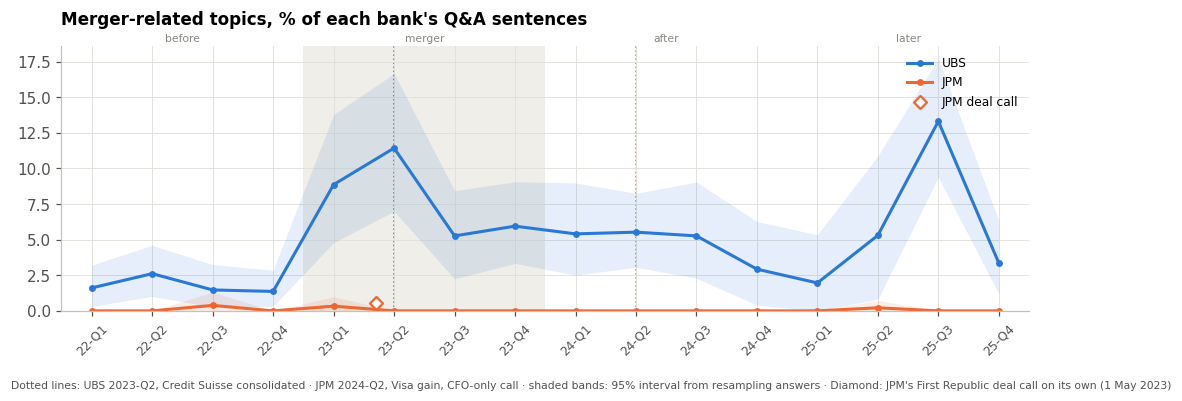

quarter,2022-Q1,2022-Q2,2022-Q3,2022-Q4,2023-Q1,2023-Q2,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4
bank,,,,,,,,,,,,,,,,
JPM,0.0,0.0,0.4,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0
UBS,1.6,2.6,1.5,1.4,8.9,11.4,5.3,5.9,5.4,5.5,5.3,2.9,2.0,5.3,13.3,3.4


JPM deal call alone: 0.6%


In [26]:
# 4.6 merger-related topics per quarter: their combined share of each bank's sentences, with 95% intervals
qa["merger_topic"] = qa["topic"].isin(MERGER_TOPICS)
rng = np.random.default_rng(SEED)
rows = []
for (b, q), g in qa[qa["call_type"] == "earnings"].groupby(["bank", "quarter"]):
    point, boot = shares(g, "merger_topic", [False, True], rng)
    lo, hi = np.percentile(boot[:, 1], [2.5, 97.5])
    rows.append({"bank": b, "quarter": q, "share": 100 * point[1], "lo": 100 * lo, "hi": 100 * hi})
merger_q = pd.DataFrame(rows).set_index(["bank", "quarter"])
deal_call = 100 * qa.loc[qa["call_type"] == "event", "merger_topic"].mean()

fig, ax = plt.subplots(figsize=(9.5, 3.6))
for b in BANKS:
    s = merger_q.xs(b, level="bank").reindex(QUARTERS)
    ax.fill_between(X, s["lo"], s["hi"], color=BANK_COLOR[b], alpha=0.12, lw=0)
    ax.plot(X, s["share"], color=BANK_COLOR[b], marker="o", ms=3.5, label=b)
mark_event(ax, deal_call)
time_axis(ax, "Merger-related topics, % of each bank's Q&A sentences")
ax.set_ylim(bottom=0)
ax.legend(loc="upper right", fontsize=8)
fig.text(0.01, 0.005, BREAK_NOTE + " · shaded bands: 95% interval from resampling answers · " + EVENT_NOTE,
         fontsize=7, color="#52514e")
plt.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig(FIG / "fig_4.6_merger_topics.png", dpi=150, bbox_inches="tight")
plt.show()
merger_q.round(2).to_csv(OUT / "merger_topics_bank_quarter.csv")
display(merger_q["share"].unstack("quarter").reindex(columns=QUARTERS).round(1))
print(f"JPM deal call alone: {deal_call:.1f}%")

The Credit Suisse topic quarter by quarter: 1% to 3% of UBS's Q&A in 2022, 8.9% and 11.4% in the first two quarters of 2023, 5% to 6% from 2023-Q3 to 2024-Q3, then 2.9% and 2.0% in 2024-Q4 and 2025-Q1 and a new peak of 13.3% in 2025-Q3; at JPMorgan it is near zero. For a supervisor this is the timeline of how long the takeover stayed on analysts' and management's minds: on average it stayed above its 2022 level, but in two quarters it came close to it.

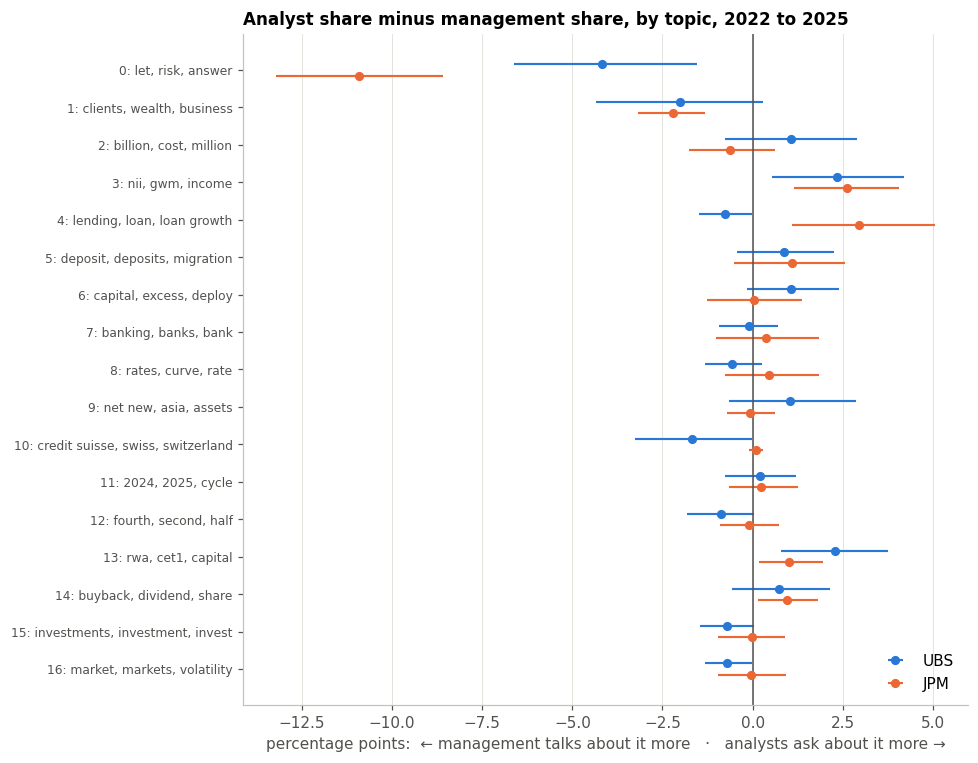

topics where the gap's 95% interval excludes zero, largest first


name   gap    lo   hi
bank topic                                                        
JPM  0                       0: let, risk, answer -10.9 -13.2 -8.6
UBS  0                       0: let, risk, answer  -4.2  -6.6 -1.6
JPM  4              4: lending, loan, loan growth   3.0   1.1  5.1
     3                        3: nii, gwm, income   2.6   1.1  4.1
UBS  3                        3: nii, gwm, income   2.3   0.6  4.2
     13                    13: rwa, cet1, capital   2.3   0.8  3.8
JPM  1               1: clients, wealth, business  -2.2  -3.2 -1.3
UBS  10     10: credit suisse, swiss, switzerland  -1.7  -3.3 -0.0
JPM  13                    13: rwa, cet1, capital   1.0   0.2  2.0
     14              14: buyback, dividend, share   1.0   0.2  1.8
UBS  4              4: lending, loan, loan growth  -0.8  -1.5 -0.0
     16           16: market, markets, volatility  -0.7  -1.3 -0.0

In [27]:
# 4.7 analyst share minus management share per topic, in percentage points, for each bank over 2022 to 2025.
# Positive: analysts raise the topic more than management talks about it. 95% intervals from resampling
# utterances within each role.
rng = np.random.default_rng(SEED)
gap_rows = []
for b in BANKS:
    for w in ["all"] + WINDOW_NAMES:
        g = qa[(qa["bank"] == b) & ((qa["window"] == w) | (w == "all"))]
        (pa, ba), (pm, bm) = (shares(g[g["speaker_role"] == r], "topic", TOPICS, rng) for r in ROLES)
        lo, hi = np.percentile(100 * (ba - bm), [2.5, 97.5], axis=0)
        gap_rows += [{"bank": b, "window": w, "topic": t, "name": topic_label(t), "gap": 100 * (pa[k] - pm[k]),
                      "lo": lo[k], "hi": hi[k]} for k, t in enumerate(TOPICS)]
gap = pd.DataFrame(gap_rows)
gap.round(2).to_csv(OUT / "analyst_management_topic_gap.csv", index=False)

g = gap[gap["window"] == "all"].set_index(["bank", "topic"])
fig, ax = plt.subplots(figsize=(9, 0.32 * len(show) + 1.6))
y = np.arange(len(show))
for i, b in enumerate(BANKS):
    r = g.xs(b, level="bank").reindex(show)
    yy = y + (i - 0.5) * 0.3
    ax.errorbar(r["gap"], yy, xerr=[r["gap"] - r["lo"], r["hi"] - r["gap"]], fmt="o", ms=5,
                color=BANK_COLOR[b], ecolor=BANK_COLOR[b], elinewidth=1.4, capsize=0, label=b)
ax.axvline(0, color="#52514e", lw=1)
ax.set_yticks(y, [topic_label(t) for t in show], fontsize=8)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlabel("percentage points:  ← management talks about it more   ·   analysts ask about it more →")
ax.legend(loc="lower right")
ax.set_title("Analyst share minus management share, by topic, 2022 to 2025", loc="left")
plt.tight_layout()
fig.savefig(FIG / "fig_4.7_analyst_gap_topics.png", dpi=150, bbox_inches="tight")
plt.show()

clear = g[(g["lo"] > 0) | (g["hi"] < 0)].drop(index=-1, level="topic", errors="ignore")
print("topics where the gap's 95% interval excludes zero, largest first")
display(clear.reindex(clear["gap"].abs().sort_values(ascending=False).index)[["name", "gap", "lo", "hi"]]
        .head(16).round(1))

Compares what analysts ask about with what management talks about. At both banks analysts push NII and income guidance more than management raises it (by 2 to 3 points), at UBS also capital ratios and at JPMorgan lending, while management fills more of its answers with spoken framing. The analyst side shows what the market wants explained.

In [28]:
# 4.8 do the results depend on the unassigned sentences? Each unassigned sentence is given the topic whose centre
# (mean MiniLM vector of its sentences) is closest by cosine, and the before-and-after changes of 4.5 are computed
# again. A change that keeps its direction and stays beyond its range does not depend on the unassigned sentences.
E = emb["MiniLM"]
T = qa["topic"].to_numpy()
ids = [t for t in TOPICS if t != -1]
centres = unit(np.vstack([E[T == t].mean(axis=0) for t in ids]))
qa["topic_all"] = T
qa.loc[T == -1, "topic_all"] = np.array(ids)[(E[T == -1] @ centres.T).argmax(axis=1)]
print(f"{(T == -1).sum():,} unassigned sentences reassigned; the largest topic now holds "
      f"{100 * qa['topic_all'].value_counts(normalize=True).max():.1f}% of sentences")

moves_all = before_after(qa, "topic_all", ids, np.random.default_rng(SEED))
check = moves[moves["topic"] != -1].merge(moves_all, on=["bank", "topic"], suffixes=("", ", all assigned"))
check["same direction"] = np.sign(check["change"]) == np.sign(check["change, all assigned"])
main_clear = check[check["clear"]]
print(f"changes beyond their range in 4.5: {len(main_clear)}; with every sentence assigned they keep their direction "
      f"in {int(main_clear['same direction'].sum())} and stay beyond their range in "
      f"{int((main_clear['same direction'] & main_clear['clear, all assigned']).sum())}")
display(check[check["clear"] | check["clear, all assigned"]]
        [["bank", "label", "change", "lo", "hi", "change, all assigned", "lo, all assigned", "hi, all assigned",
          "clear, all assigned"]].round(1))

4,075 unassigned sentences reassigned; the largest topic now holds 26.9% of sentences
changes beyond their range in 4.5: 7; with every sentence assigned they keep their direction in 7 and stay beyond their range in 7


,bank,label,change,lo,hi,"change, all assigned","lo, all assigned","hi, all assigned","clear, all assigned"
0,UBS,"0: let, risk, answer",3.2,-0.4,6.5,5.0,0.7,9.2,True
1,UBS,"1: clients, wealth, business",-5.3,-8.6,-2.0,-7.1,-11.6,-3.0,True
6,UBS,"6: capital, excess, deploy",3.2,1.5,5.0,4.3,2.4,6.2,True
9,UBS,"9: net new, asia, assets",-6.6,-8.8,-4.4,-7.0,-9.5,-4.6,True
10,UBS,"10: credit suisse, swiss, switzerland",2.9,1.3,4.6,3.5,1.8,5.2,True
13,UBS,"13: rwa, cet1, capital",2.4,0.9,3.9,3.2,1.3,5.2,True
20,JPM,"3: nii, gwm, income",2.3,0.3,4.2,2.2,0.0,4.3,True
23,JPM,"6: capital, excess, deploy",3.5,1.4,5.7,3.0,0.8,5.6,True
30,JPM,"13: rwa, cet1, capital",-1.0,-2.1,0.1,-1.8,-3.4,-0.2,True
32,JPM,"15: investments, investment, invest",-0.6,-1.9,0.6,-2.5,-4.5,-0.5,True


Checks whether the 40.5% unassigned sentences change the results: each is given its nearest topic and the 2022 to 2024 changes are computed again. All 7 changes keep their direction and stay beyond normal variation, so the findings of 4.5 do not depend on the sentences the model leaves out.

In [29]:
# 4.9 how much does the topic model depend on tiny differences in the text? About one sentence in ten contains curly
# quotes or long dashes. Here they are written with plain characters (the vectors barely move, see the first table) and
# BERTopic is refitted at every minimum cluster size with the same seed and settings. Nothing else changes.
plain_idx = qa.index[qa["typography_changed"]]
plain_model = SentenceTransformer(MODELS["MiniLM"], device=DEVICE)
E_plain = emb["MiniLM"].copy()
E_plain[plain_idx] = encode(plain_model, qa.loc[plain_idx, "text_plain"], 64)
del plain_model
free_gpu()
cos = (E_plain[plain_idx] * emb["MiniLM"][plain_idx]).sum(axis=1)
typo = (pd.DataFrame({"bank": qa.loc[plain_idx, "bank"].to_numpy(), "cosine": cos})
        .groupby("bank")["cosine"].agg(sentences="size", mean="mean", lowest="min"))
typo["share of the bank's corpus %"] = 100 * typo["sentences"] / qa["bank"].value_counts()
typo.round(4).to_csv(OUT / "typography_effect_minilm.csv")
display(typo.round(4))

red_plain = UMAP(random_state=SEED, **UMAP_ARGS).fit_transform(E_plain)
docs_plain = qa["text_plain"].tolist()
rows = []
for m in GRID:
    model_p = BERTopic(umap_model=BaseDimensionalityReduction(), hdbscan_model=clusterer(m),
                       vectorizer_model=vectorizer(), top_n_words=10, calculate_probabilities=False)
    t_p = np.asarray(model_p.fit_transform(docs_plain, embeddings=red_plain)[0])
    t_a = fits[m][1]
    both = (t_a != -1) & (t_p != -1)
    row = {"min_cluster_size": m}
    for name, t in (("as spoken", t_a), ("plain characters", t_p)):
        kw_t = pd.DataFrame({"t": t, "k": qa["merger_keyword"]}).groupby("t")["k"].agg(["mean", "sum"]).drop(index=-1, errors="ignore")
        mt = kw_t.index[(kw_t["mean"] >= 4 * MERGER_RATE) & (kw_t["sum"] >= 10)]
        sizes = pd.Series(t).value_counts()
        row[f"topics, {name}"] = len(set(t) - {-1})
        row[f"merger-related topic sizes, {name}"] = sorted((int(sizes[x]) for x in mt), reverse=True)
    row["same topics (ARI, shared assigned)"] = adjusted_rand_score(t_a[both], t_p[both])
    rows.append(row)
robust = pd.DataFrame(rows).set_index("min_cluster_size")
robust.round(3).to_csv(OUT / "topic_text_robustness.csv")
display(robust.round(2))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2782.95it/s]


,sentences,mean,lowest,share of the bank's corpus %
bank,,,,
JPM,559,0.9945,0.9269,9.7336
UBS,476,0.9951,0.9457,11.0287


,"topics, as spoken","merger-related topic sizes, as spoken","topics, plain characters","merger-related topic sizes, plain characters","same topics (ARI, shared assigned)"
min_cluster_size,,,,,
15,159,"[93, 24, 22, 15]",150,"[62, 62, 23, 21]",0.92
25,96,"[93, 70]",93,"[97, 71, 62]",0.92
40,68,"[122, 70]",68,"[98, 97, 71]",0.87
60,36,"[122, 70]",39,"[172, 97, 71]",0.91
80,31,[122],28,"[172, 97]",0.87
100,25,[221],23,[172],0.89
150,17,[221],17,[172],0.91
200,11,[221],12,[],0.79


Checks how fragile the topic model is: writing curly quotes and long dashes as plain characters (one sentence in ten, vectors moved by only 0.5%) changes the Credit Suisse topic from 221 to 172 sentences and removes it at the largest setting. This is why topic results are always read with the themes of step 5 and the keyword count, and why no extra cleaning is done.

### One model per year

Each focus year is modelled on its own sentences: 2022 (the year before the mergers), 2023 (the merger year) and 2024 (the year after). The method is the one of 4.2: the saved MiniLM vectors, three UMAP seeds per setting, and the same scores, with coherence counted over the speaker turns of the whole corpus, the same reference as for the whole-dataset model. One year holds about a quarter of the corpus, so the minimum cluster sizes are scaled down (10, 15, 20, 30, 40 and 60 sentences).

**Rule fixed before the run:** in each year, the highest topic quality (coherence times diversity) among the settings whose topics agree across seeds with an ARI of at least 0.80. If no setting reaches it, the year has no stable topic structure of its own and is read through the whole-dataset model only. The merger-related rule is the one of the whole model.

3 years x 6 settings x 3 seeds in 166s


topics topics, other seeds  unassigned %  \
year min_cluster_size                                             
2022 10                    72             75 / 72        25.918   
     15                    45             50 / 49        21.685   
     20                    36             40 / 42        23.521   
     30                    29             26 / 27        26.292   
     40                    25             20 / 19        29.064   
     60                    12               2 / 2        31.386   
2023 10                    65             66 / 65        28.311   
     15                    45             45 / 46        31.879   
     20                    36             37 / 37        34.893   
     30                    25             19 / 22        41.158   
     40                    17             15 / 16        40.603   
     60                    11             12 / 11        35.527   
2024 10                    60             60 / 63        31.474   
     15                    43             41 / 41        31.563   
     20                    33             33 / 31        35.458   
     30                    24             22 / 24        40.682   
     40                    18             16 / 17        48.251   
     60                     7               8 / 7        46.038   

                       agreement across seeds (ARI)  coherence (NPMI, turns)  \
year min_cluster_size                                                          
2022 10                                       0.889                   -0.149   
     15                                       0.954                   -0.090   
     20                                       0.869                   -0.045   
     30                                       0.800                    0.005   
     40                                       0.775                    0.006   
     60                                       0.033                    0.052   
2023 10                                       0.963                   -0.109   
     15                                       0.959                   -0.055   
     20                                       0.945                   -0.045   
     30                                       0.642                   -0.009   
     40                                       0.931                    0.060   
     60                                       0.867                    0.062   
2024 10                                       0.861                   -0.098   
     15                                       0.894                   -0.078   
     20                                       0.909                   -0.064   
     30                                       0.853                   -0.005   
     40                                       0.731                    0.040   
     60                                       0.876                    0.133   

                       diversity  topic quality note  chosen  
year min_cluster_size                                         
2022 10                    0.920         -0.137        False  
     15                    0.904         -0.081        False  
     20                    0.903         -0.041         True  
     30                    0.903          0.005        False  
     40                    0.912          0.006        False  
     60                    0.958          0.050        False  
2023 10                    0.922         -0.101        False  
     15                    0.924         -0.051        False  
     20                    0.911         -0.041        False  
     30                    0.912         -0.008        False  
     40                    0.894          0.054        False  
     60                    0.882          0.054         True  
2024 10                    0.918         -0.090        False  
     15                    0.923         -0.072        False  
     20                    0.927         -0.059        False  
     30   


2022: minimum cluster size 20, 36 topics, 23.5% unassigned; merger-related: []


,label,sentences,UBS %,JPM %,deal call sentences,merger keyword %,coherence,merger-related
0,"2022-0: answer, let, second",335,10.0,15.2,0.0,0.0,0.0,False
1,"2022-1: nii, guidance, billion",92,4.3,2.6,0.0,1.1,0.0,False
2,"2022-2: loan, leverage, loan growth",92,2.3,4.7,0.0,0.0,0.1,False
3,"2022-3: forwards, strategy, forecast",87,3.4,3.1,0.0,0.0,-0.3,False
4,"2022-4: billion, million, savings",86,3.5,2.9,0.0,1.2,-0.1,False
5,"2022-5: fourth, change, end fourth",82,3.4,2.8,0.0,0.0,-0.1,False
6,"2022-6: rates, income, rate",72,1.8,3.7,0.0,0.0,0.1,False
7,"2022-7: deposit, deposits, betas",63,2.6,2.1,0.0,0.0,0.1,False
8,"2022-8: net new, assets, feegenerating",60,4.3,0.2,0.0,0.0,0.3,False
9,"2022-9: business, shape, consumer",59,2.3,2.1,0.0,0.0,-0.0,False



2023: minimum cluster size 60, 11 topics, 35.5% unassigned; merger-related: ['2023-1: credit, credit suisse, bank']


,label,sentences,UBS %,JPM %,deal call sentences,merger keyword %,coherence,merger-related
0,"2023-0: point, let, trying",417,12.9,19.8,25,0.2,0.1,False
1,"2023-1: credit, credit suisse, bank",277,5.5,15.9,47,18.8,0.1,True
2,"2023-2: billion, cost, revenue",256,15.2,5.6,7,1.2,0.2,False
3,"2023-3: capital, market, pricing",152,6.1,6.0,8,0.7,0.1,False
4,"2023-4: deposit, deposits, migration",109,2.4,6.0,14,3.7,0.3,False
5,"2023-5: rates, rate, higher",78,0.7,5.3,4,0.0,0.1,False
6,"2023-6: clients, client, services",74,3.9,2.0,8,2.7,0.2,False
7,"2023-7: cet1, rwa, return",72,4.7,1.2,3,0.0,0.1,False
8,"2023-8: number, normalized, numbers",66,2.4,2.8,1,0.0,0.1,False
9,"2023-9: nii, billion, guidance",64,1.8,3.2,1,9.4,-0.1,False



2024: minimum cluster size 60, 7 topics, 46.0% unassigned; merger-related: ['2024-4: cost, integration, ncl']


,label,sentences,UBS %,JPM %,deal call sentences,merger keyword %,coherence,merger-related
0,"2024-0: taking, let, answer",523,22.0,23.9,0.0,0.2,0.1,False
1,"2024-1: capital, business, wealth",238,11.3,10.1,0.0,3.4,0.0,False
2,"2024-2: banking, clients, market",141,4.4,7.4,0.0,0.0,0.2,False
3,"2024-3: lending, private, credit",91,1.8,5.5,0.0,3.3,0.2,False
4,"2024-4: cost, integration, ncl",79,5.5,2.2,0.0,16.5,0.2,True
5,"2024-5: nii, deposit, nii ex",75,1.8,4.3,0.0,0.0,0.1,False
6,"2024-6: deposit, deposits, sweep",72,3.2,3.2,0.0,1.4,0.1,False


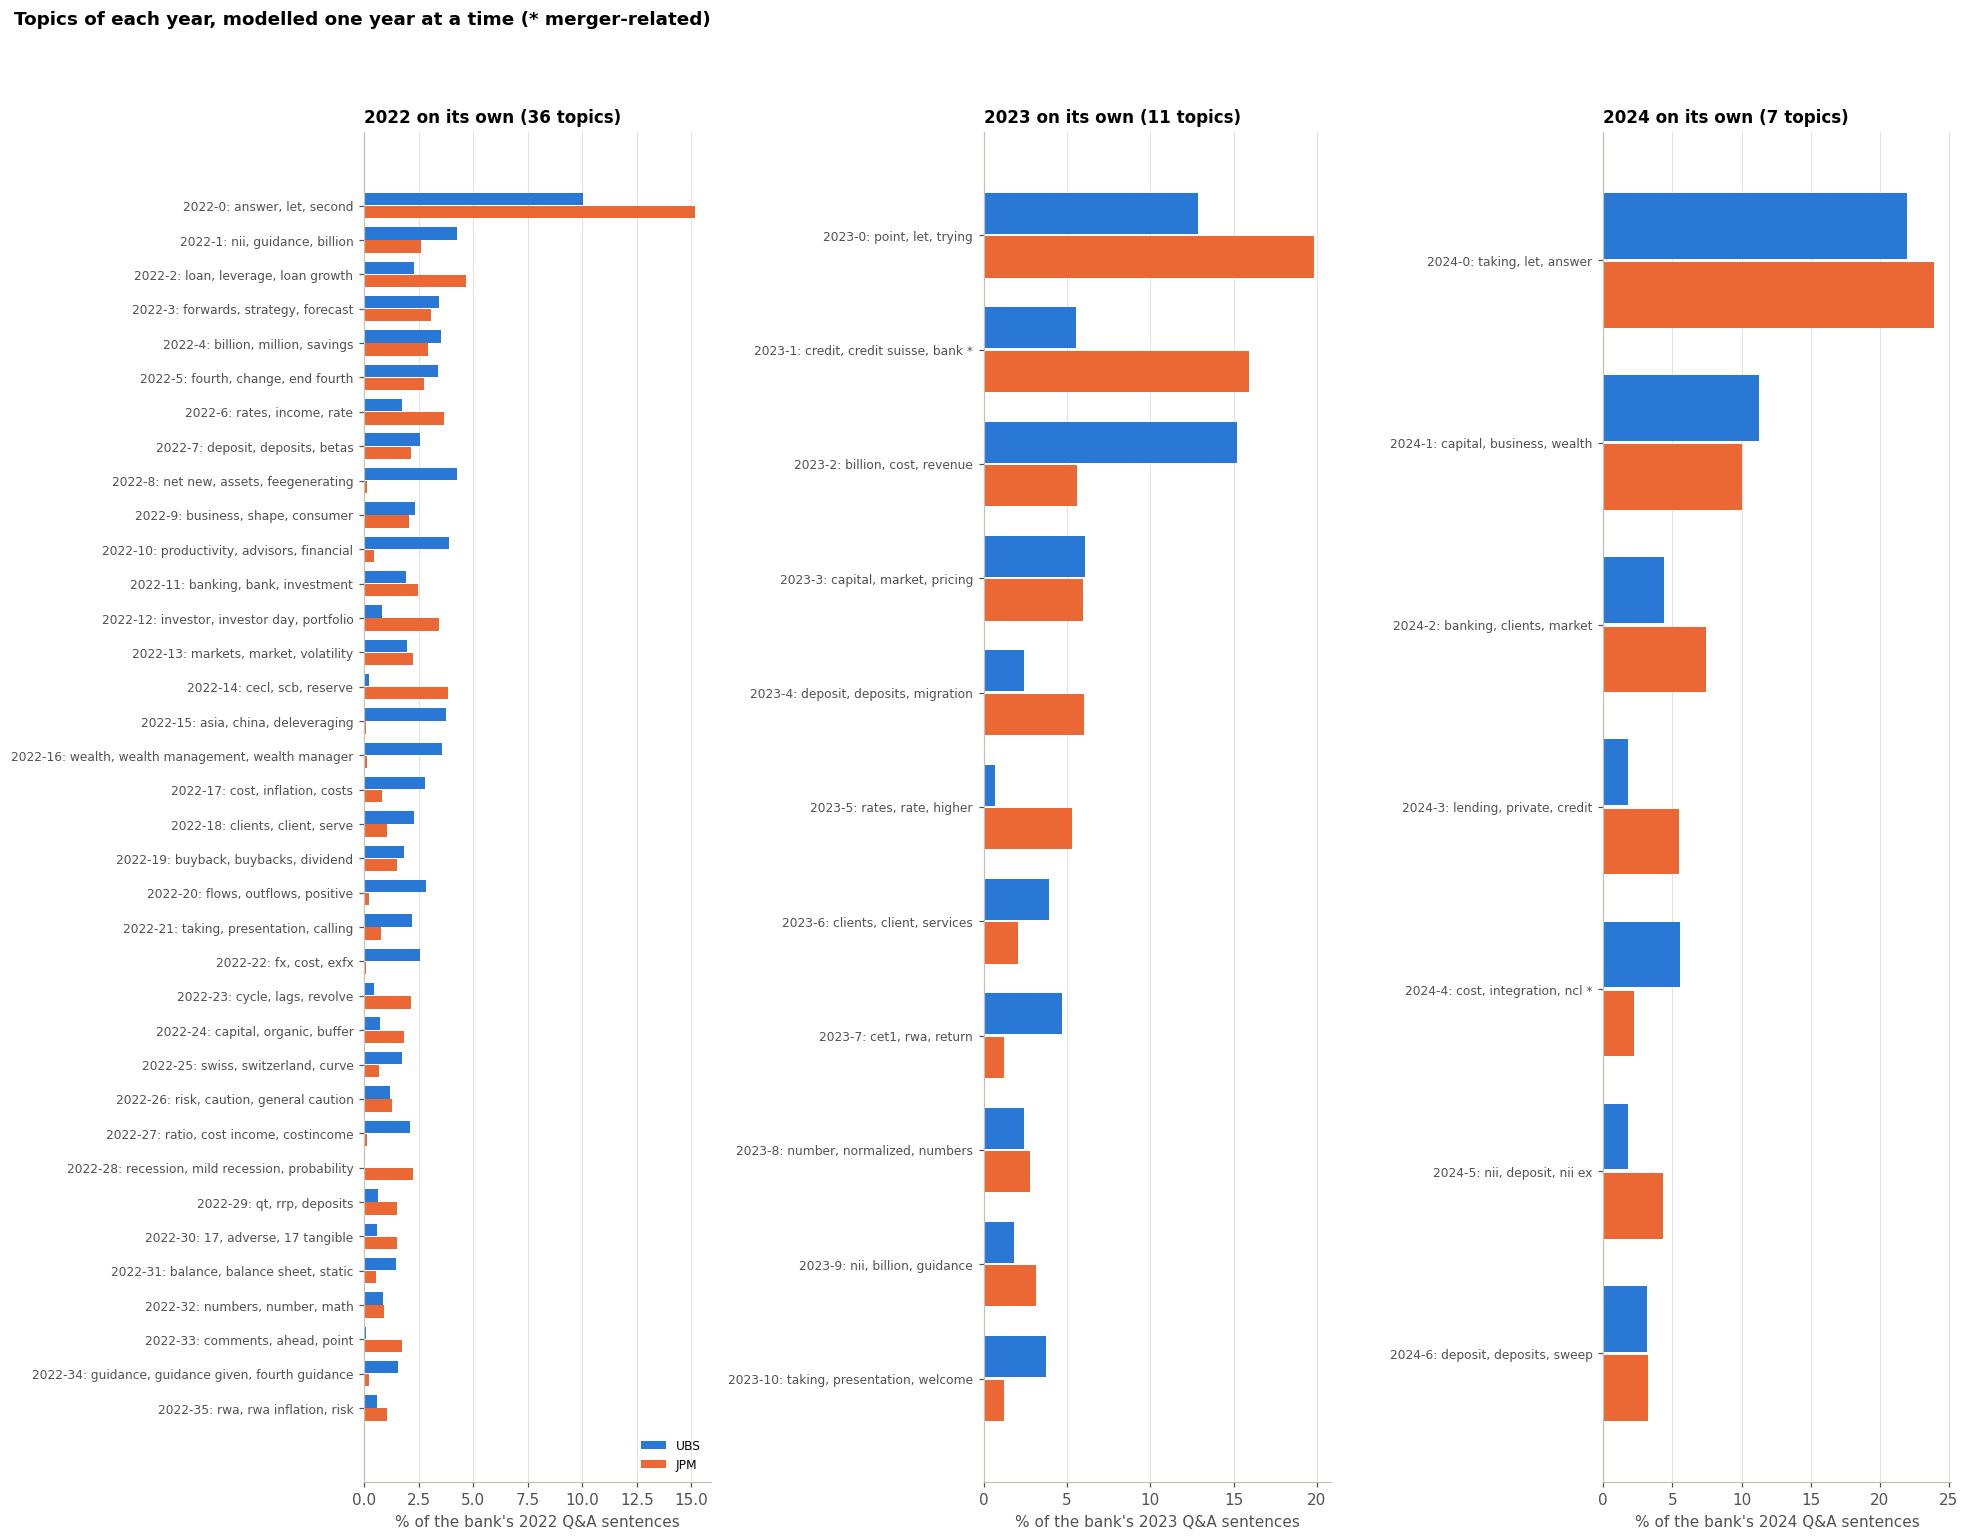

In [30]:
# 4.10 one topic model per year: BERTopic fitted again on the sentences of 2022, of 2023 and of 2024 alone, with the
# method of 4.2 (the saved MiniLM vectors, three UMAP seeds; stability, coherence, diversity) and minimum cluster sizes
# scaled to one year. Rule fixed before the run (see above).
# BERTopic counts its label vocabulary over topic documents (one per topic), not sentences, so with the few topics of
# one year the year models use min_df=1 (in the whole model min_df=5 or 1 gives the same chosen setting and almost the
# same labels). Coherence is counted over the speaker turns of the whole corpus, the same reference as in 4.2: one year
# alone has too few turns (most word pairs never meet, so coherence falls below zero, where coherence x diversity stops
# rewarding diverse topics). This reference was set after a first run that counted within each year.
GRID_YEAR = [10, 15, 20, 30, 40, 60]

def year_vectorizer():
    return CountVectorizer(stop_words=STOP_WORDS, ngram_range=(1, 2), min_df=1)

def year_label(y, t, w):
    return "unassigned" if t == -1 else f"{y}-{t}: {short_label(w[t])}"

ref_vec = year_vectorizer().fit(clean_docs)                  # every word and two-word term of the corpus
REF_VOCAB = ref_vec.vocabulary_
ref_turn = ((to_turn @ (ref_vec.transform(clean_docs) > 0).astype(np.int32)) > 0).astype(np.int32)

def coherence_ref(ws):
    # NPMI over the whole corpus's speaker turns; a two-word term that only exists across a sentence end is skipped
    ws = [w for w in ws if w in REF_VOCAB]
    cols = ref_turn[:, [REF_VOCAB[w] for w in ws]].tocsc()
    p = np.asarray(cols.sum(axis=0)).ravel() / ref_turn.shape[0]
    co = (cols.T @ cols).toarray() / ref_turn.shape[0]
    return np.mean([-1.0 if co[i, j] == 0 else np.log(co[i, j] / (p[i] * p[j])) / -np.log(co[i, j])
                    for i in range(len(ws)) for j in range(i + 1, len(ws))])

def fit_year(year):
    sub = np.flatnonzero(qa["year"].to_numpy() == year)
    docs_y = qa["text"].to_numpy()[sub].tolist()
    red = {s: UMAP(random_state=s, **UMAP_ARGS).fit_transform(emb["MiniLM"][sub]) for s in SEEDS}

    fits_y, rows = {}, []
    for m in GRID_YEAR:
        row = {"year": year, "min_cluster_size": m}
        try:
            model = BERTopic(umap_model=BaseDimensionalityReduction(), hdbscan_model=clusterer(m),
                             vectorizer_model=year_vectorizer(), top_n_words=10, calculate_probabilities=False)
            t = np.asarray(model.fit_transform(docs_y, embeddings=red[SEED])[0])
        except ValueError as e:                      # too few topics for a label vocabulary
            rows.append({**row, "note": f"no model: {e}"})
            continue
        w = topic_words(model)
        others = [clusterer(m).fit_predict(red[s]) for s in SEEDS[1:]]
        div = len({x for ws in w.values() for x in ws}) / sum(len(ws) for ws in w.values())
        coh = {k: coherence_ref(ws) for k, ws in w.items()}
        fits_y[m] = (model, t, coh)
        rows.append({**row, "topics": len(w), "topics, other seeds": " / ".join(str(len(set(o) - {-1})) for o in others),
                     "unassigned %": 100 * (t == -1).mean(),
                     "agreement across seeds (ARI)": np.mean([agreement(t, o) for o in others]),
                     "coherence (NPMI, turns)": np.mean(list(coh.values())), "diversity": div,
                     "topic quality": np.mean(list(coh.values())) * div, "note": ""})
    tune = pd.DataFrame(rows)
    stable_y = tune[tune["agreement across seeds (ARI)"].fillna(0) >= MIN_ARI]
    chosen = int(stable_y.loc[stable_y["topic quality"].idxmax(), "min_cluster_size"]) if len(stable_y) else None
    return sub, tune, chosen, fits_y

year_models, tunes = {}, []
t0 = time.time()
for y in FOCUS_YEARS:
    sub, tune, chosen, fits_y = fit_year(y)
    tune["chosen"] = tune["min_cluster_size"] == chosen
    tunes.append(tune)
    if chosen is None:
        print(f"{y}: no setting reaches ARI {MIN_ARI}; this year has no stable topic structure of its own")
        continue
    model, t, coh = fits_y[chosen]
    w = topic_words(model)
    yt = qa.iloc[sub][["key", "bank", "call_type", "merger_keyword", "topic"]].copy()
    yt["year_topic"] = t
    cnt = pd.crosstab(yt["year_topic"], yt["bank"]).reindex(columns=BANKS, fill_value=0)
    kwy = yt.groupby("year_topic")["merger_keyword"].agg(["mean", "sum"])
    table = pd.DataFrame({
        "label": pd.Series({k: year_label(y, k, w) for k in w}),
        "sentences": cnt.sum(axis=1),
        "UBS %": 100 * cnt["UBS"] / (yt["bank"] == "UBS").sum(), "JPM %": 100 * cnt["JPM"] / (yt["bank"] == "JPM").sum(),
        "deal call sentences": yt[yt["call_type"] == "event"].groupby("year_topic").size(),
        "merger keyword %": 100 * kwy["mean"],
        "coherence": pd.Series(coh),
        "top words": pd.Series({k: ", ".join(ws[:7]) for k, ws in w.items()}),
    }).drop(index=-1, errors="ignore").fillna({"deal call sentences": 0}).sort_values("sentences", ascending=False)
    table["merger-related"] = (table["merger keyword %"] >= 400 * MERGER_RATE) & (kwy["sum"].reindex(table.index) >= 10)
    table.round(3).to_csv(OUT / f"year_topics_{y}.csv")
    year_models[y] = {"chosen": chosen, "words": w, "sentences": yt, "table": table}
year_tuning = pd.concat(tunes, ignore_index=True)
year_tuning.round(4).to_csv(OUT / "year_topic_tuning.csv", index=False)
pd.concat({y: ym["sentences"][["key", "year_topic"]] for y, ym in year_models.items()}, names=["year"]) \
    .reset_index(level=0).to_csv(OUT / "year_topics_sentence.csv", index=False)
print(f"{len(FOCUS_YEARS)} years x {len(GRID_YEAR)} settings x {len(SEEDS)} seeds in {time.time() - t0:.0f}s")
display(year_tuning.set_index(["year", "min_cluster_size"]).round(3))
for y, ym in year_models.items():
    t = ym["table"]
    print(f"\n{y}: minimum cluster size {ym['chosen']}, {len(t)} topics, "
          f"{100 * (ym['sentences']['year_topic'] == -1).mean():.1f}% unassigned; merger-related: "
          f"{t.loc[t['merger-related'], 'label'].tolist()}")
    display(t.drop(columns=["top words"]).round(1))

fig, axes = plt.subplots(1, len(year_models), figsize=(6 * len(year_models), 0.34 * max(len(ym["table"]) for ym in year_models.values()) + 2))
for ax, (y, ym) in zip(np.atleast_1d(axes), year_models.items()):
    t = ym["table"]
    yy = np.arange(len(t))
    for k, b in enumerate(BANKS):
        ax.barh(yy + (k - 0.5) * 0.38, t[f"{b} %"], height=0.36, color=BANK_COLOR[b], label=b)
    ax.set_yticks(yy, [lab + (" *" if mr else "") for lab, mr in zip(t["label"], t["merger-related"])], fontsize=8)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    ax.set_xlabel(f"% of the bank's {y} Q&A sentences")
    ax.set_title(f"{y} on its own ({len(t)} topics)", loc="left")
np.atleast_1d(axes)[0].legend(loc="lower right", fontsize=8)
fig.suptitle("Topics of each year, modelled one year at a time (* merger-related)", x=0.01, ha="left", fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIG / "fig_4.10_year_topics.png", dpi=150, bbox_inches="tight")
plt.show()

Fits a separate topic model for each year with the same automatic rule. 2022 gets 36 topics (its larger settings are unstable; a minimum of 30 misses the stability threshold by less than 0.0001), 2023 gets 11 and 2024 gets 7. 2023's merger topic joins Credit Suisse with JPMorgan's talk about banks ("credit, credit suisse, bank", 16% of JPMorgan's 2023 sentences, 47 of them from the First Republic deal call), and 2024's is UBS's integration costs and non-core unit ("cost, integration, ncl"). The year models show what each year was about in its own terms.

In [31]:
# 4.11 each year's topics against the whole-dataset topics, on the same sentences: for each year topic, the whole topic
# most of its sentences belong to and the share the whole model leaves unassigned; the agreement between the two
# groupings (adjusted mutual information, sentences both models assign). A year topic that the whole model mostly
# leaves unassigned (50% or more, rule fixed here) is a subject only that year's model finds.
from sklearn.metrics import adjusted_mutual_info_score

rows, agree = [], []
for y, ym in year_models.items():
    s = ym["sentences"]
    st = s[s["year_topic"] != -1]
    cross = pd.crosstab(st["year_topic"], st["topic"])
    un = cross[-1] if -1 in cross.columns else pd.Series(0, index=cross.index)
    assigned_w = cross.drop(columns=-1, errors="ignore")
    for k in cross.index:
        n = cross.loc[k].sum()
        has = assigned_w.loc[k].sum() > 0
        rows.append({"year": y, "year topic": year_label(y, k, ym["words"]), "sentences": int(n),
                     "unassigned in the whole model %": 100 * un.loc[k] / n,
                     "main whole topic": topic_label(assigned_w.loc[k].idxmax()) if has else "none",
                     "share in that topic %": 100 * assigned_w.loc[k].max() / n if has else 0.0})
    both = s[(s["year_topic"] != -1) & (s["topic"] != -1)]
    agree.append({"year": y, "year topics": len(ym["table"]), "chosen minimum": ym["chosen"],
                  "unassigned, year model %": 100 * (s["year_topic"] == -1).mean(),
                  "unassigned, whole model %": 100 * (s["topic"] == -1).mean(),
                  "agreement with the whole model (AMI)": adjusted_mutual_info_score(both["year_topic"], both["topic"])})
matching = pd.DataFrame(rows).sort_values(["year", "sentences"], ascending=[True, False])
matching["only in the year model"] = matching["unassigned in the whole model %"] >= 50
year_vs_whole = pd.DataFrame(agree).set_index("year")
matching.round(1).to_csv(OUT / "year_topics_vs_whole.csv", index=False)
display(year_vs_whole.round(2))
display(matching.round(1))
for y in year_models:
    print(f"{y}, subjects only the year's model finds:",
          matching.loc[(matching["year"] == y) & matching["only in the year model"], "year topic"].tolist() or "none")

,year topics,chosen minimum,"unassigned, year model %","unassigned, whole model %",agreement with the whole model (AMI)
year,,,,,
2022,36,20,23.52,40.56,0.76
2023,11,60,35.53,40.33,0.74
2024,7,60,46.04,39.66,0.80


,year,year topic,sentences,unassigned in the whole model %,main whole topic,share in that topic %,only in the year model
0,2022,"2022-0: answer, let, second",335,11.0,"0: let, risk, answer",87.2,False
1,2022,"2022-1: nii, guidance, billion",92,6.5,"3: nii, gwm, income",91.3,False
2,2022,"2022-2: loan, leverage, loan growth",92,32.6,"4: lending, loan, loan growth",63.0,False
3,2022,"2022-3: forwards, strategy, forecast",87,37.9,"0: let, risk, answer",41.4,False
4,2022,"2022-4: billion, million, savings",86,14.0,"2: billion, cost, million",73.3,False
5,2022,"2022-5: fourth, change, end fourth",82,19.5,"12: fourth, second, half",64.6,False
6,2022,"2022-6: rates, income, rate",72,27.8,"8: rates, curve, rate",47.2,False
7,2022,"2022-7: deposit, deposits, betas",63,6.3,"5: deposit, deposits, migration",93.7,False
8,2022,"2022-8: net new, assets, feegenerating",60,3.3,"9: net new, asia, assets",91.7,False
9,2022,"2022-9: business, shape, consumer",59,54.2,"1: clients, wealth, business",39.0,True


2022, subjects only the year's model finds: ['2022-9: business, shape, consumer', '2022-10: productivity, advisors, financial', '2022-14: cecl, scb, reserve', '2022-17: cost, inflation, costs', '2022-20: flows, outflows, positive', '2022-21: taking, presentation, calling', '2022-22: fx, cost, exfx', '2022-28: recession, mild recession, probability', '2022-29: qt, rrp, deposits', '2022-30: 17, adverse, 17 tangible', '2022-31: balance, balance sheet, static', '2022-32: numbers, number, math', '2022-33: comments, ahead, point', '2022-34: guidance, guidance given, fourth guidance']
2023, subjects only the year's model finds: ['2023-8: number, normalized, numbers', '2023-10: taking, presentation, welcome']
2024, subjects only the year's model finds: none


Matches each year's topics to the whole-dataset topics. The two agree well (adjusted mutual information 0.74 to 0.80), so the whole-dataset model is a fair common reference. 2022's model finds 14 subjects the whole model mostly leaves unassigned, such as recession scenarios, US reserve rules (CECL, SCB) and quantitative tightening; 2023's finds only procedural ones and 2024's none. The year view mainly adds detail about 2022, the year before the mergers.

### The merger year across both banks

The team's plan asks for the topics of both banks in the merger period. In the whole-dataset model that is 2023: each bank's topic mix in 2023, UBS against JPMorgan, what 2023 added compared with 2022, and JPMorgan's First Republic deal call against its 2023 earnings calls. The 2023 model of 4.10 gives the same year read on its own.

2023 sentences: UBS 1,197, JPM 1,325 (deal call 172)
each bank's topic mix in 2023, largest first, and UBS minus JPM with its 95% interval


,label,UBS %,JPM %,UBS minus JPM,lo,hi,clear
topic,,,,,,,
-1,unassigned,39.6,41.0,-1.4,-5.9,3.7,False
0,"0: let, risk, answer",15.3,18.0,-2.7,-6.4,0.8,False
10,"10: credit suisse, swiss, switzerland",7.9,0.2,7.8,5.7,10.1,True
2,"2: billion, cost, million",6.6,2.8,3.8,1.7,6.0,True
1,"1: clients, wealth, business",6.3,3.3,3.0,0.5,5.8,True
5,"5: deposit, deposits, migration",2.3,5.5,-3.2,-5.5,-1.0,True
7,"7: banking, banks, bank",0.8,5.1,-4.3,-6.0,-2.4,True
4,"4: lending, loan, loan growth",0.3,4.9,-4.6,-6.3,-3.0,True
3,"3: nii, gwm, income",2.7,4.5,-1.9,-3.6,-0.1,True


what 2023 added: change from 2022 to 2023 whose 95% interval excludes zero


,bank,topic,label,before %,merger %,lo,hi,change,clear
10,UBS,9,"9: net new, asia, assets",8.3,2.0,-8.5,-4.1,-6.3,True
11,UBS,10,"10: credit suisse, swiss, switzerland",1.8,7.9,4.0,8.5,6.1,True
2,UBS,1,"1: clients, wealth, business",10.2,6.3,-7.4,-0.4,-3.8,True
14,UBS,13,"13: rwa, cet1, capital",1.1,4.1,1.4,4.8,3.0,True
4,UBS,3,"3: nii, gwm, income",4.7,2.7,-4.1,-0.1,-2.0,True
7,UBS,6,"6: capital, excess, deploy",0.7,2.6,0.6,3.2,1.9,True
9,UBS,8,"8: rates, curve, rate",2.1,0.6,-2.4,-0.4,-1.5,True
5,UBS,4,"4: lending, loan, loan growth",1.6,0.3,-2.5,-0.3,-1.3,True
17,UBS,16,"16: market, markets, volatility",1.5,0.4,-2.1,-0.1,-1.1,True


,bank,topic,label,before %,merger %,lo,hi,change,clear
24,JPM,5,"5: deposit, deposits, migration",2.5,5.5,1.0,4.9,3.1,True
26,JPM,7,"7: banking, banks, bank",2.5,5.1,0.8,4.6,2.7,True
22,JPM,3,"3: nii, gwm, income",2.8,4.5,0.0,3.5,1.7,True
31,JPM,12,"12: fourth, second, half",2.5,1.0,-2.7,-0.4,-1.5,True


JPMorgan's First Republic deal call against its 2023 earnings calls (% of each)


,label,deal call %,JPM 2023 earnings calls %
topic,,,
-1,unassigned,38.4,41.4
0,"0: let, risk, answer",15.7,18.4
7,"7: banking, banks, bank",11.0,4.2
1,"1: clients, wealth, business",9.3,2.4
5,"5: deposit, deposits, migration",8.1,5.1
4,"4: lending, loan, loan growth",6.4,4.7
3,"3: nii, gwm, income",1.7,4.9
8,"8: rates, curve, rate",1.7,4.5


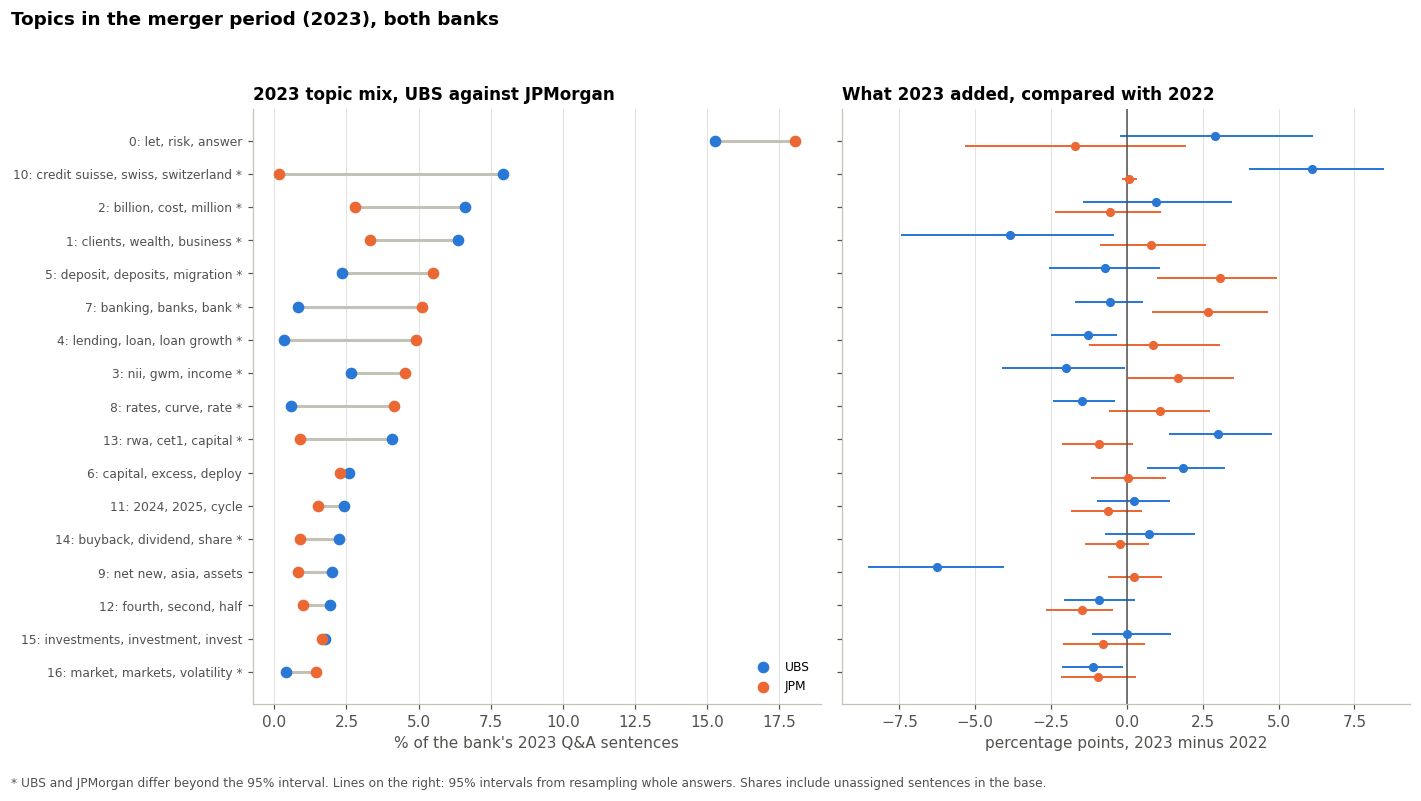

In [32]:
# 4.12 the merger year (2023) in the whole-dataset model: each bank's topic mix in 2023 with 95% intervals from resampling
# utterances, UBS minus JPMorgan per topic, and the change from 2022 to 2023 per bank. JPMorgan's First Republic deal
# call (1 May 2023) is also set against its 2023 earnings calls.
MERGER = "merger"

def window_change(df, col, cats, w_from, w_to, rng):
    # share of each category in two windows per bank, the change, and a 95% interval for the change
    rows = []
    for b in BANKS:
        point, boot = {}, {}
        for w in (w_from, w_to):
            point[w], boot[w] = shares(df[(df["bank"] == b) & (df["window"] == w)], col, cats, rng)
        lo, hi = np.percentile(100 * (boot[w_to] - boot[w_from]), [2.5, 97.5], axis=0)
        rows += [{"bank": b, "topic": c, f"{w_from} %": 100 * point[w_from][k], f"{w_to} %": 100 * point[w_to][k],
                  "lo": lo[k], "hi": hi[k]} for k, c in enumerate(cats)]
    out = pd.DataFrame(rows)
    out["change"] = out[f"{w_to} %"] - out[f"{w_from} %"]
    out["clear"] = (out["lo"] > 0) | (out["hi"] < 0)
    return out

rng = np.random.default_rng(SEED)
m23 = qa[qa["window"] == MERGER]
mix23, boot23 = {}, {}
for b in BANKS:
    mix23[b], boot23[b] = shares(m23[m23["bank"] == b], "topic", TOPICS, rng)
lo, hi = np.percentile(100 * (boot23["UBS"] - boot23["JPM"]), [2.5, 97.5], axis=0)
across = pd.DataFrame({"label": [topic_label(t) for t in TOPICS], "UBS %": 100 * mix23["UBS"],
                       "JPM %": 100 * mix23["JPM"]}, index=pd.Index(TOPICS, name="topic"))
across["UBS minus JPM"] = across["UBS %"] - across["JPM %"]
across["lo"], across["hi"] = lo, hi
across["clear"] = (across["lo"] > 0) | (across["hi"] < 0)
across.round(2).to_csv(OUT / "merger_period_topics_across_banks.csv")

added = window_change(qa, "topic", TOPICS, "before", MERGER, np.random.default_rng(SEED))
added.insert(2, "label", added["topic"].map(topic_label))
added.round(2).to_csv(OUT / "merger_period_change_from_2022.csv", index=False)

jpm23 = m23[m23["bank"] == "JPM"]
deal_call = pd.DataFrame({
    "deal call %": 100 * jpm23.loc[jpm23["call_type"] == "event", "topic"].value_counts(normalize=True),
    "JPM 2023 earnings calls %": 100 * jpm23.loc[jpm23["call_type"] == "earnings", "topic"].value_counts(normalize=True),
}).reindex(TOPICS).fillna(0)
deal_call.insert(0, "label", [topic_label(t) for t in deal_call.index])

print(f"2023 sentences: UBS {int((m23['bank'] == 'UBS').sum()):,}, JPM {int((m23['bank'] == 'JPM').sum()):,} "
      f"(deal call {int((jpm23['call_type'] == 'event').sum())})")
print("each bank's topic mix in 2023, largest first, and UBS minus JPM with its 95% interval")
display(across.reindex(across[["UBS %", "JPM %"]].max(axis=1).sort_values(ascending=False).index).round(1))
print("what 2023 added: change from 2022 to 2023 whose 95% interval excludes zero")
for b in BANKS:
    a = added[(added["bank"] == b) & added["clear"]]
    display(a.reindex(a["change"].abs().sort_values(ascending=False).index).round(1))
print("JPMorgan's First Republic deal call against its 2023 earnings calls (% of each)")
display(deal_call[(deal_call["deal call %"] >= 3) | (deal_call["JPM 2023 earnings calls %"] >= 3)]
        .sort_values("deal call %", ascending=False).round(1))

shown = [t for t in across.drop(index=-1)[["UBS %", "JPM %"]].max(axis=1).sort_values(ascending=False).index]
fig, axes = plt.subplots(1, 2, figsize=(13, 0.32 * len(shown) + 1.8), sharey=True)
y = np.arange(len(shown))
a = across.loc[shown]
axes[0].hlines(y, a["UBS %"], a["JPM %"], color="#c3c2b7", lw=2, zorder=1)
for b in BANKS:
    axes[0].scatter(a[f"{b} %"], y, s=44, color=BANK_COLOR[b], zorder=2, label=b)
axes[0].set_yticks(y, [topic_label(t) + (" *" if across.at[t, "clear"] else "") for t in shown], fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel("% of the bank's 2023 Q&A sentences")
axes[0].set_title("2023 topic mix, UBS against JPMorgan", loc="left")
axes[0].legend(loc="lower right", fontsize=8)
for k, b in enumerate(BANKS):
    r = added[added["bank"] == b].set_index("topic").loc[shown]
    yy = y + (k - 0.5) * 0.3
    axes[1].errorbar(r["change"], yy, xerr=[r["change"] - r["lo"], r["hi"] - r["change"]], fmt="o", ms=5,
                     color=BANK_COLOR[b], ecolor=BANK_COLOR[b], elinewidth=1.3, capsize=0, label=b)
axes[1].axvline(0, color="#52514e", lw=1)
axes[1].set_xlabel("percentage points, 2023 minus 2022")
axes[1].set_title("What 2023 added, compared with 2022", loc="left")
for ax in axes:
    ax.grid(axis="y", visible=False)
fig.suptitle("Topics in the merger period (2023), both banks", x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.005, "* UBS and JPMorgan differ beyond the 95% interval. Lines on the right: 95% intervals from "
         "resampling whole answers. Shares include unassigned sentences in the base.", fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.03, 1, 0.95))
fig.savefig(FIG / "fig_4.10_merger_period_topics.png", dpi=150, bbox_inches="tight")
plt.show()

The merger year across both banks, in the whole-dataset model. In 2023 UBS talks more than JPMorgan about Credit Suisse (7.9% against 0.2%), costs, wealth and capital ratios, and JPMorgan more about deposits, banks, lending, NII and rates. Against 2022, UBS's Credit Suisse topic rises by 6 points and net new assets fall by 6, while JPMorgan's deposits (+3.1 points), banks (+2.7) and NII (+1.7) rise; its First Republic call is mostly about banks, clients and deposits. This answers the team's question on topics across both banks in the merger period.

### How the topics changed: before, during and after the merger

The whole-dataset model gives one set of topics for every year, so change can be measured directly. Two tests, both on that model, with their rules fixed before the run:

- **What a topic is about, year by year (4.13).** BERTopic's topics over time: the topic stays the same, and its typical words are computed again for each bank and year from that year's sentences only. A topic can keep its size and still change its content, for example from Swiss business before the merger to integration after it. Whether the content changed is tested, not read from the words: the meaning of a topic's sentences in 2023 and in 2024 is compared with 2022 (distance between the average sentence vectors) against 500 reshuffles of whole answers between the two years. Many topics are tested at once, so the results are corrected for multiple testing (Benjamini-Hochberg, 5% false discovery rate). Only bank, topic and year combinations with at least 30 sentences are tested.
- **UBS against JPMorgan (4.14).** From 2022 to 2023 and to 2024, rates rose and banks failed, so some topics changed at every bank. A change at UBS that JPMorgan does not show is more likely to come from the merger. For each topic, the change in UBS's share minus the change in JPMorgan's share, with a 95% interval from resampling whole answers (a difference-in-differences). The same test is run on the themes in 5.4.

In [33]:
# 4.13 topics over time: the same topics, with their words computed again for each bank and year (BERTopic's
# topics_over_time on the fitted model; each period's own words, without averaging with the global or previous words),
# and a test of whether a topic's content moved from 2022 to 2023 and to 2024 more than chance: the distance between
# the average MiniLM vectors of the topic's sentences in the two years, against 500 reshuffles of whole answers
# between the years, per bank. Benjamini-Hochberg correction over all tests; at least 30 sentences per bank-year.
MIN_N = 30
PERIOD_CODE = {(b, y): 100 * i + (y - 2000) for i, b in enumerate(BANKS) for y in YEARS}   # sortable time stamps
CODE_PERIOD = {v: k for k, v in PERIOD_CODE.items()}
tot = topic_model.topics_over_time(docs, [PERIOD_CODE[b, y] for b, y in zip(qa["bank"], qa["year"])],
                                   evolution_tuning=False, global_tuning=False)
tot["bank"] = [CODE_PERIOD[c][0] for c in tot["Timestamp"]]
tot["year"] = [CODE_PERIOD[c][1] for c in tot["Timestamp"]]
words_by = {(r.Topic, r.bank, r.year): ", ".join(str(r.Words).split(", ")[:5]) for r in tot.itertuples()}

def shift_vs_chance(idx_a, idx_b, rng, n=500):
    # 1 - cosine between the average vectors of two groups of sentences, and a p-value from reshuffling whole answers
    E = emb["MiniLM"]
    def sums(idx):
        codes, units = pd.factorize(qa.loc[idx, "turn_id"])
        s = np.zeros((len(units), E.shape[1]))
        np.add.at(s, codes, E[idx])
        return s
    sa, sb = sums(idx_a), sums(idx_b)
    observed = 1 - unit(sa.sum(0)) @ unit(sb.sum(0))
    S, na = np.vstack([sa, sb]), len(sa)
    null = np.empty(n)
    for i in range(n):
        perm = rng.permutation(len(S))
        null[i] = 1 - unit(S[perm[:na]].sum(0)) @ unit(S[perm[na:]].sum(0))
    return observed, (1 + (null >= observed).sum()) / (n + 1)

rng = np.random.default_rng(SEED)
T_, B_, Y_ = qa["topic"].to_numpy(), qa["bank"].to_numpy(), qa["year"].to_numpy()
rows = []
for t in topic_table.index:
    for b in BANKS:
        idx = {y: np.flatnonzero((T_ == t) & (B_ == b) & (Y_ == y)) for y in FOCUS_YEARS}
        row = {"bank": b, "topic": t, "label": topic_label(t), **{f"n {y}": len(idx[y]) for y in FOCUS_YEARS},
               **{f"words {y}": words_by.get((t, b, y), "") for y in FOCUS_YEARS}}
        for y in (2023, 2024):
            if len(idx[2022]) >= MIN_N and len(idx[y]) >= MIN_N:
                row[f"shift to {y}"], row[f"p {y}"] = shift_vs_chance(idx[2022], idx[y], rng)
        rows.append(row)
content = pd.DataFrame(rows)

# Benjamini-Hochberg over every test run (both years, both banks, all topics)
pcols = [c for c in ("p 2023", "p 2024") if c in content]
p_all = content[pcols].stack()
order = p_all.sort_values().index
ranks = pd.Series(np.arange(1, len(order) + 1), index=order)
q = (p_all[order] * len(p_all) / ranks).iloc[::-1].cummin().iloc[::-1].clip(upper=1)
for c in pcols:
    y = c.split()[1]
    content[f"q {y}"] = q.xs(c, level=1).reindex(content.index)
    content[f"content changed {y}"] = content[f"q {y}"] < 0.05
content.round(4).to_csv(OUT / "topics_over_time_content.csv", index=False)
tot.to_csv(OUT / "topics_over_time_words.csv", index=False)

print(f"{len(p_all)} tests (topic, bank, year with at least {MIN_N} sentences in both years); "
      f"content changed beyond chance after correction: "
      + ", ".join(f"2022 to {c.split()[1]}: {int(content[f'content changed {c.split()[1]}'].sum())}" for c in pcols))
show_cols = ["bank", "label", "n 2022", "n 2023", "n 2024", "words 2022", "words 2023", "words 2024",
             "q 2023", "q 2024", "content changed 2023", "content changed 2024"]
changed = content[content[[f"content changed {c.split()[1]}" for c in pcols]].fillna(False).any(axis=1)]
with pd.option_context("display.max_colwidth", 60):
    display(changed[show_cols].round(3))
    print("the merger-related topics, every bank:")
    display(content[content["topic"].isin(MERGER_TOPICS)][show_cols].round(3))

23 tests (topic, bank, year with at least 30 sentences in both years); content changed beyond chance after correction: 2022 to 2023: 5, 2022 to 2024: 6


,bank,label,n 2022,n 2023,n 2024,words 2022,words 2023,words 2024,q 2023,q 2024,content changed 2023,content changed 2024
0,UBS,"0: let, risk, answer",169,183,138,"forwards, second, caution, exactly, start","second, clarity, need, months, details","second, speculate, early, focused, sorry",0.026,0.029,True,True
1,JPM,"0: let, risk, answer",258,239,258,"make, simple, happen, let, risks","followup, did, technical, couple, people","let, answer, important, geopolitical, try",0.023,0.023,True,True
2,UBS,"1: clients, wealth, business",139,76,43,"wealth, clients, business, management, advisors","clients, client, wealth management, wealth, management","wealth, business, wealth management, management, advisor",0.023,0.053,True,False
3,JPM,"1: clients, wealth, business",33,44,34,"serve, business, clients, shape, businesses","clients, company, advisors, better, best","clients, business, global, company, client",0.023,0.181,True,False
4,UBS,"2: billion, cost, million",77,79,50,"million, billion, costincome, ratio, payout","billion, cost, revenue, end, 2026","billion, cost, end, revenues, gross",0.023,0.041,True,True
6,UBS,"3: nii, gwm, income",64,32,40,"nii, gwm, guidance, sensitivity, pc","nii, gwm, revenue, americas, decline","nii, gwm, pc, guidance, income",0.053,0.023,False,True
11,JPM,"5: deposit, deposits, migration",32,73,46,"deposit, deposits, beta, cycle, attrition","deposit, deposits, migration, internal, reprice","deposit, deposits, consumer, balances, rate",0.235,0.042,False,True
17,JPM,"8: rates, curve, rate",40,55,54,"rates, curve, fed, treasury, forward curve","rates, rate, fed, higher, cuts","curve, yield, cuts, fed, rates",0.181,0.041,False,True


the merger-related topics, every bank:


,bank,label,n 2022,n 2023,n 2024,words 2022,words 2023,words 2024,q 2023,q 2024,content changed 2023,content changed 2024
20,UBS,"10: credit suisse, swiss, switzerland",25,95,42,"swiss, switzerland, ubs, course, rates","credit suisse, suisse, credit, switzerland, ubs","credit suisse, suisse, credit, ubs, switzerland",NaN,NaN,False,False
21,JPM,"10: credit suisse, swiss, switzerland",1,2,0,"lines, week, reserve, swiss, saw","acquisition, credit suisse, suisse, saw, second",,NaN,NaN,False,False


Shows what each topic was about, bank by bank and year by year (BERTopic's topics over time), and tests whether the meaning of its sentences moved from 2022 more than reshuffling the answers would produce. Of the bank-topic pairs with enough sentences (12 testable for 2023, 11 for 2024), 5 changed beyond chance by 2023 and 6 by 2024, after correcting for the number of tests. At UBS the costs topic moved from the cost/income ratio and payout in 2022 to costs, revenue and the 2026 horizon; at JPMorgan, deposits turned to consumer balances and rates to rate cuts in 2024 (the subject-free framing topic also moved, which says little). The Credit Suisse topic has only 25 UBS sentences in 2022, below the minimum of 30, so it is not tested, but its words show the change plainly: Swiss business in 2022, Credit Suisse from 2023. Topics changed what they are about, not only how often they come up.

topics whose change from 2022 to 2023 differs between UBS and JPMorgan beyond the 95% interval


,label,UBS change to 2023,JPM change to 2023,UBS minus JPM 2023,lo 2023,hi 2023
10,"9: net new, asia, assets",-6.3,0.2,-6.5,-8.9,-4.2
11,"10: credit suisse, swiss, switzerland",6.1,0.1,6.0,4.0,8.3
2,"1: clients, wealth, business",-3.8,0.8,-4.6,-8.6,-0.9
14,"13: rwa, cet1, capital",3.0,-0.9,3.9,2.1,6.0
6,"5: deposit, deposits, migration",-0.7,3.1,-3.8,-6.4,-1.2
4,"3: nii, gwm, income",-2.0,1.7,-3.7,-6.4,-1.1
8,"7: banking, banks, bank",-0.6,2.7,-3.2,-5.6,-1.1
9,"8: rates, curve, rate",-1.5,1.1,-2.6,-4.5,-0.7
7,"6: capital, excess, deploy",1.9,0.0,1.8,0.1,3.7


topics whose change from 2022 to 2024 differs between UBS and JPMorgan beyond the 95% interval


,label,UBS change to 2024,JPM change to 2024,UBS minus JPM 2024,lo 2024,hi 2024
10,"9: net new, asia, assets",-6.6,0.8,-7.4,-9.9,-4.9
2,"1: clients, wealth, business",-5.3,-0.0,-5.3,-9.2,-1.7
14,"13: rwa, cet1, capital",2.4,-1.0,3.4,1.5,5.4
11,"10: credit suisse, swiss, switzerland",2.9,-0.1,3.0,1.4,4.8


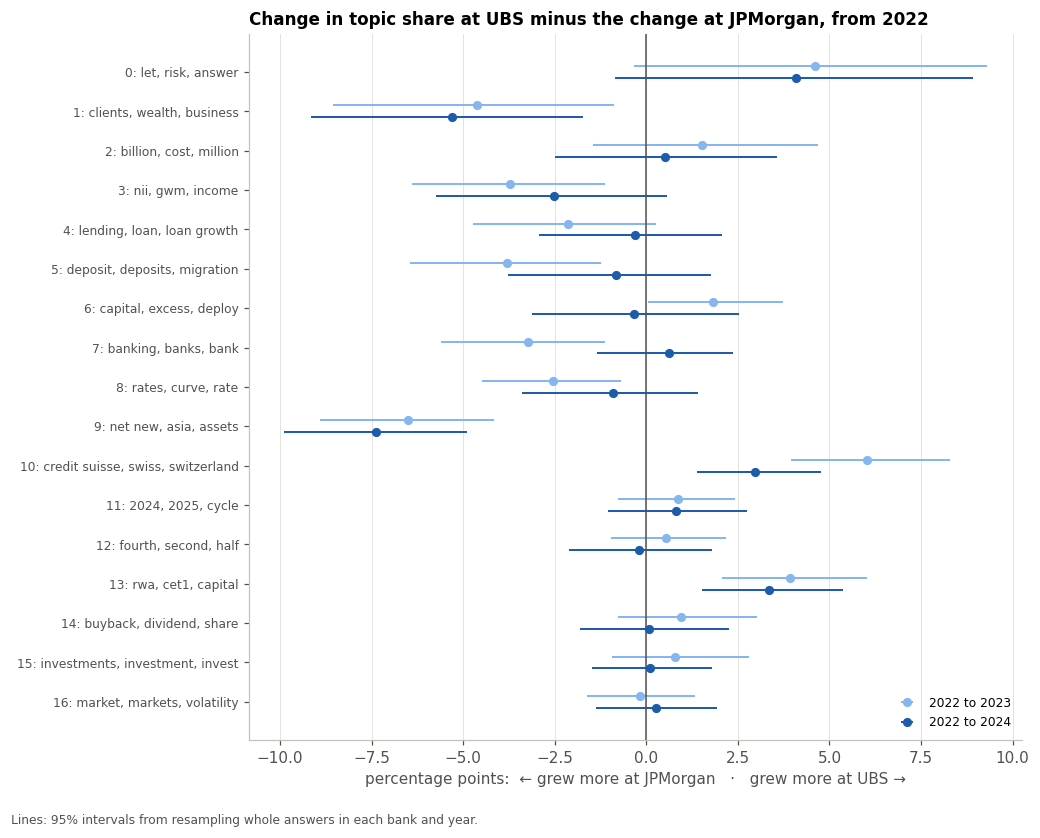

In [34]:
# 4.14 UBS against JPMorgan: for each topic, the change in UBS's share from 2022 to 2023 and to 2024 minus the change in
# JPMorgan's share over the same years (a difference-in-differences), with a 95% interval from resampling whole answers
# in each bank and year. A clear positive value: the topic grew at UBS more than at JPMorgan, so the rise is not only
# the sector's.
def ubs_minus_jpm(df, col, cats, rng, years=(2023, 2024)):
    point, boot = {}, {}
    for b in BANKS:
        for y in (2022, *years):
            point[b, y], boot[b, y] = shares(df[(df["bank"] == b) & (df["year"] == y)], col, cats, rng)
    rows = []
    for k, c in enumerate(cats):
        row = {col: c}
        for y in years:
            du, dj = point["UBS", y][k] - point["UBS", 2022][k], point["JPM", y][k] - point["JPM", 2022][k]
            bd = (boot["UBS", y][:, k] - boot["UBS", 2022][:, k]) - (boot["JPM", y][:, k] - boot["JPM", 2022][:, k])
            lo, hi = np.percentile(100 * bd, [2.5, 97.5])
            row.update({f"UBS change to {y}": 100 * du, f"JPM change to {y}": 100 * dj,
                        f"UBS minus JPM {y}": 100 * (du - dj), f"lo {y}": lo, f"hi {y}": hi,
                        f"clear {y}": bool(lo > 0 or hi < 0)})
        rows.append(row)
    return pd.DataFrame(rows)

did_topics = ubs_minus_jpm(qa, "topic", TOPICS, np.random.default_rng(SEED))
did_topics.insert(1, "label", did_topics["topic"].map(topic_label))
did_topics.round(2).to_csv(OUT / "ubs_minus_jpm_topics.csv", index=False)
for y in (2023, 2024):
    d = did_topics[did_topics[f"clear {y}"] & (did_topics["topic"] != -1)]
    print(f"topics whose change from 2022 to {y} differs between UBS and JPMorgan beyond the 95% interval")
    display(d.reindex(d[f"UBS minus JPM {y}"].abs().sort_values(ascending=False).index)
            [["label", f"UBS change to {y}", f"JPM change to {y}", f"UBS minus JPM {y}", f"lo {y}", f"hi {y}"]].round(1))

d = did_topics[did_topics["topic"] != -1].set_index("topic").reindex(show)
fig, ax = plt.subplots(figsize=(9.5, 0.34 * len(show) + 1.8))
yy = np.arange(len(show))
for k, (y, colr) in enumerate(((2023, "#86b6ef"), (2024, "#1c5cab"))):
    off = yy + (k - 0.5) * 0.3
    ax.errorbar(d[f"UBS minus JPM {y}"], off, xerr=[d[f"UBS minus JPM {y}"] - d[f"lo {y}"], d[f"hi {y}"] - d[f"UBS minus JPM {y}"]],
                fmt="o", ms=5, color=colr, ecolor=colr, elinewidth=1.3, capsize=0, label=f"2022 to {y}")
ax.axvline(0, color="#52514e", lw=1)
ax.set_yticks(yy, [topic_label(t) for t in show], fontsize=8)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlabel("percentage points:  ← grew more at JPMorgan   ·   grew more at UBS →")
ax.legend(loc="lower right", fontsize=8)
ax.set_title("Change in topic share at UBS minus the change at JPMorgan, from 2022", loc="left")
fig.text(0.01, 0.005, "Lines: 95% intervals from resampling whole answers in each bank and year.", fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(FIG / "fig_4.14_ubs_minus_jpm.png", dpi=150, bbox_inches="tight")
plt.show()

Tests which changes are UBS's own: UBS's change from 2022 minus JPMorgan's change over the same years. Beyond the 95% interval, the Credit Suisse topic grew more at UBS (+6.0 points by 2023, +3.0 by 2024) and so did capital ratios (+3.9 and +3.4), while net new assets in Asia (-6.5 and -7.4) and wealth and clients (-4.6 and -5.3) fell more at UBS. In 2023 deposits, banks, NII and rates grew more at JPMorgan, which fits its own year with the First Republic deal; by 2024 those differences are gone. This separates what is specific to UBS from what both banks share, though JPMorgan is not a clean comparison because it also made an acquisition in 2023.

### Summary

BERTopic was run on the whole dataset and on each focus year, with the setting chosen by published measures (stability across random starts, coherence, diversity) rather than by eye. The whole-dataset model finds 17 stable topics. One of them, Credit Suisse and Switzerland, is the merger topic and belongs almost entirely to UBS: 1.8% of its Q&A in 2022, 7.9% in 2023, 4.7% in 2024 and a new peak in 2025-Q3. Measured against JPMorgan, the rise of the Credit Suisse topic (+6 points by 2023, +3 by 2024) and of capital ratios (+4 and +3), and the falls in wealth, clients and net new assets in Asia (-5 to -7), are UBS's own changes, while JPMorgan's 2023 rise in deposits, banks and rates fits its own year with the First Republic deal. Topics also changed in content: 5 to 6 bank-topic pairs talk about different things in 2023 and 2024 than in 2022, such as UBS's costs topic moving from cost/income to costs and the 2026 horizon. The year models agree with the whole-dataset model and add detail, and in the merger year UBS talked about the takeover, costs and capital, JPMorgan about deposits, banks and rates.

How sure: the changes hold when every sentence is given a topic and the topics are stable across random starts, but 40.5% of sentences belong to no topic and the model is sensitive to small text changes, so its findings are read together with the themes of step 5 and the keyword count. The test against JPMorgan removes what both banks share, so the changes that remain are specific to UBS; it does not show that the merger caused them.

## 5. Sentence-BERT: themes for the most relevant topics

The second model reads every sentence against seven fixed themes, for the whole dataset and for 2022, 2023 and 2024 (5.4), and describes the topics of step 4 by their main theme (5.5). Each sentence takes the theme whose example sentences it is closest to in meaning, so the same question is asked of every quarter and the shares can be tracked over time.

| Label | Theme | A sentence belongs here when it is mainly about |
|---|---|---|
| `integration` | Integration and M&A | the 2023 acquisition, integration progress and milestones, client or system migration, legal-entity mergers, deal accounting |
| `restructuring` | Restructuring | winding down legacy or non-core books, exiting businesses, reorganisation, restructuring charges |
| `capital` | Capital and liquidity | capital ratios and requirements, buybacks and dividends, RWA and leverage, liquidity, funding, deposit outflows |
| `risk` | Risk and credit quality | credit losses and reserves, loan quality, real-estate exposure, market and rate risk, litigation |
| `costs` | Costs and efficiency | expenses, cost savings, cost/income, headcount, investment spend |
| `revenue` | Revenue and outlook | net interest income and deposit pricing, fees, trading, wealth flows, guidance, client activity |
| `other` | Other | none of the above, or procedure |

Step 5.1 turns the codebook into eight example sentences per theme, none of which names either bank. These 56 examples are the only labelled data in the notebook: they define the themes, the two Sentence-BERT models are fine-tuned on them, and the fine-tuning is checked on them. No transcript sentence is labelled by hand or by a language model, and the fine-tuning never sees a transcript sentence, so it does not depend on the data release.

**Fine-tuning** follows SetFit, a standard recipe for fine-tuning a Sentence-BERT model on a handful of labelled examples. Every example is paired 20 times with an example of the same theme (target similarity 1) and 20 times with an example of a different theme (target 0), 2,240 pairs. The whole network is trained for one pass over the pairs with the cosine-similarity loss (learning rate 2e-5, batches of 16, 10% warm-up), so that sentences on the same theme move closer together. These are SetFit's default settings, fixed before any result was seen. The checks need no labelled transcript sentence:

- **Held-out examples (5.2).** Four-fold cross-validation: the model is fine-tuned on six examples per theme and has to place the two it never saw. The pre-trained model is scored the same way, so the difference is the effect of fine-tuning.
- **Stability (5.2).** Each of the four fold models tags the whole corpus. If the tags barely change when a different quarter of the examples is left out, the result does not hang on the wording of a few examples.
- **Agreement between the models (5.3).** MiniLM and mpnet are different networks; if fine-tuning makes them agree more often on real sentences, the themes are better defined.
- **Merger sentences (5.3).** Sentences with a merger keyword (2.4) should mostly land on "integration".

**Rule for the final model, fixed in advance:** the model that places more held-out examples correctly after fine-tuning; if the two are within two examples of each other, the more stable one.

In [35]:
# 5.1 theme examples: eight bank-neutral sentences per theme. "other" has its own examples, so a sentence with no
# business topic lands there by similarity; there is no cut-off. A sentence takes the theme whose centroid (the
# average of its eight examples) is closest. This cell scores the pre-trained models, before fine-tuning.
from sklearn.metrics import cohen_kappa_score

EXAMPLES = {
    "integration": [
        "The integration of the acquired bank is progressing well and we remain on track with our milestones.",
        "We are migrating the acquired clients and accounts onto our own platforms and systems.",
        "The merger of the two legal entities was completed after the transaction closed.",
        "Purchase accounting, negative goodwill and other acquisition-related effects from the deal.",
        "How is the combination of the two businesses going, and what are the remaining integration risks?",
        "When will the legal entities be merged, and when will the acquired clients be on one platform?",
        "How much of the integration work is still ahead of you, and what are the next milestones?",
        "Most clients of the acquired bank have stayed with us since the takeover.",
    ],
    "restructuring": [
        "We continue to wind down the legacy portfolio and exit businesses that do not fit our strategy.",
        "Running off non-core positions released risk-weighted assets and reduced the balance sheet.",
        "The reorganisation involves closing overlapping units and simplifying the group structure.",
        "Restructuring charges and exit costs were higher this quarter.",
        "How much longer will it take to wind down the remaining legacy book?",
        "We agreed to sell a business that is no longer core to the group.",
        "The run-down of the non-core unit is ahead of plan, with fewer positions left to exit.",
        "We are reorganising our divisions into a simpler structure with fewer layers of management.",
    ],
    "capital": [
        "Our CET1 capital ratio remains well above the regulatory requirement.",
        "We intend to return excess capital to shareholders through share buybacks and dividends.",
        "The proposed capital rules and Basel III requirements would increase the capital we need to hold.",
        "Liquidity and funding remain strong, with a comfortable liquidity coverage ratio.",
        "Risk-weighted assets and the leverage ratio determine how much balance sheet we can deploy.",
        "When do you expect to restart share buybacks, and at what size?",
        "How do you think about the payout split between dividends and buybacks over the next few years?",
        "The capital surcharge and the stress capital buffer set how much capital we must hold.",
    ],
    "risk": [
        "Credit quality remains solid, but we expect net charge-offs to normalise from low levels.",
        "We added to our loan loss reserves because the macroeconomic outlook weakened.",
        "Exposure to commercial real estate and office loans is an area we are watching closely.",
        "Litigation, legal provisions and regulatory investigations remain a risk to earnings.",
        "Market volatility and geopolitical uncertainty could affect the portfolio.",
        "Rates staying higher for longer could strain borrowers and slow the economy.",
        "Card net charge-offs rose as consumer credit continued to normalise.",
        "Higher rates have caused unrealised losses in the securities portfolio.",
    ],
    "costs": [
        "We are on track to deliver the planned gross cost savings.",
        "Expenses rose this quarter, driven by investment in technology and higher compensation.",
        "Our cost-to-income ratio should improve as the efficiency measures come through.",
        "We reduced headcount and contractor spend to bring the cost base down.",
        "What is your expense guidance for next year?",
        "We expect adjusted expenses for next year to be roughly in line with this year.",
        "Compensation costs went up because of higher performance-related pay.",
        "Technology, marketing and real estate were the main drivers of the increase in non-compensation expenses.",
    ],
    "revenue": [
        "Net interest income will come down as deposit costs rise and balances move to higher-yielding products.",
        "Investment banking fees and markets revenue were strong compared with last year.",
        "Wealth management attracted net new assets and fee income grew.",
        "Our outlook assumes modest loan growth and a few rate cuts next year.",
        "Client activity and consumer spending remain healthy.",
        "Net interest income guidance for next year depends on the path of rate cuts and the forward curve.",
        "We are winning back market share and client flows are returning.",
        "What is your outlook for revenue growth and returns over the next few years?",
    ],
    "other": [
        "Thank you, that is very helpful.",
        "Let me take your second question.",
        "I would just add one point to that.",
        "What exactly do you mean by that?",
        "We are not going to comment on speculation.",
        "That is a fair question, and we will come back to it.",
        "We will give you more detail on that at a later date.",
        "I think that is broadly right, and we will see how it plays out.",
    ],
}
THEMES = list(EXAMPLES)
BANK_NAMES = re.compile(r"\b(?:ubs|jp ?morgan|chase|credit suisse|first republic|swiss|switzerland)\b", re.I)
assert not any(BANK_NAMES.search(s) for v in EXAMPLES.values() for s in v), "an example names a bank"
assert all(len(v) == 8 for v in EXAMPLES.values()), "eight examples per theme"
ex_text = np.array([s for v in EXAMPLES.values() for s in v])
ex_label = np.array([t for t, v in EXAMPLES.items() for _ in v])

def centroids(E_ex, labels):
    C = np.vstack([E_ex[labels == t].mean(axis=0) for t in THEMES])
    return C / np.linalg.norm(C, axis=1, keepdims=True)

def tag_themes(E, C):
    # nearest theme centroid, and the margin over the runner-up (how clear-cut the choice is)
    S = E @ C.T
    top2 = np.sort(S, axis=1)[:, -2:]
    return np.array(THEMES)[S.argmax(axis=1)], top2[:, 1] - top2[:, 0]

E_ex_base = {}
for tag in MODELS:
    model = SentenceTransformer(MODELS[tag], device=DEVICE)
    E_ex_base[tag] = encode(model, ex_text)
    del model
    free_gpu()
    qa[f"theme_base_{tag}"], qa[f"margin_base_{tag}"] = tag_themes(emb[tag], centroids(E_ex_base[tag], ex_label))

print("theme shares by bank before fine-tuning (% of sentences)")
display(pd.concat({tag: pd.crosstab(qa[f"theme_base_{tag}"], qa["bank"], normalize="columns").mul(100)
                   for tag in MODELS}, axis=1).reindex(THEMES).fillna(0).round(1))
same = qa["theme_base_MiniLM"] == qa["theme_base_mpnet"]
print(f"MiniLM and mpnet give the same theme for {100 * same.mean():.0f}% of sentences "
      f"(kappa {cohen_kappa_score(qa['theme_base_MiniLM'], qa['theme_base_mpnet']):.2f})")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3016.50it/s]


theme shares by bank before fine-tuning (% of sentences)


MiniLM       mpnet      
bank             JPM   UBS   JPM   UBS
integration      4.1   6.7   3.7   6.6
restructuring    5.7   7.6   2.3   4.3
capital         12.2  16.4  14.7  16.2
risk            21.2  10.2  18.3   8.2
costs            5.0   7.7   5.0   8.9
revenue         16.8  19.8  17.9  21.8
other           35.0  31.6  38.1  34.0

MiniLM and mpnet give the same theme for 65% of sentences (kappa 0.56)


Defines the seven themes with eight example sentences each (no bank named) and tags every sentence with the nearest theme before any training. The two pre-trained models agree on only 65% of sentences, so untrained themes are not reliable enough: fine-tuning is needed.

In [36]:
# 5.2 fine-tuning, and four-fold cross-validation on the theme examples: each fold fine-tunes on 6 examples per
# theme and places the 2 held out; the pre-trained model is scored the same way. Each fold's tagger also tags the
# whole corpus, to see how much the tags depend on which examples were used. 8 fine-tuning runs; results are
# saved, and a later run reloads them when the corpus is unchanged.
import itertools
from sentence_transformers.sentence_transformer import losses
from sentence_transformers.util import batch_to_device
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

FT = {"pairs_per_example": 20, "epochs": 1, "batch_size": 16, "lr": 2e-5, "warmup": 0.1}   # SetFit defaults

def example_pairs(texts, labels, rng):
    # every example gets pairs_per_example same-theme partners (target 1) and as many other-theme ones (target 0)
    pairs, idx = [], np.arange(len(labels))
    for _ in range(FT["pairs_per_example"]):
        for i, t in enumerate(labels):
            same, other = idx[(labels == t) & (idx != i)], idx[labels != t]
            pairs += [(texts[i], texts[rng.choice(same)], 1.0), (texts[i], texts[rng.choice(other)], 0.0)]
    return pairs

def fine_tune(tag, texts, labels, seed=SEED):
    # SetFit's first stage: contrastive training of the whole Sentence-BERT model on example pairs.
    # Returns the model and the loss of every training step.
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    model = SentenceTransformer(MODELS[tag], device=DEVICE)
    loss_fn = losses.CosineSimilarityLoss(model)
    pairs = example_pairs([str(t) for t in texts], np.asarray(labels), rng)
    steps = FT["epochs"] * int(np.ceil(len(pairs) / FT["batch_size"]))
    opt = torch.optim.AdamW(model.parameters(), lr=FT["lr"])
    sched = get_linear_schedule_with_warmup(opt, int(FT["warmup"] * steps), steps)
    model.train()
    log = []
    for _ in range(FT["epochs"]):
        order = rng.permutation(len(pairs))
        for start in range(0, len(pairs), FT["batch_size"]):
            batch = [pairs[i] for i in order[start:start + FT["batch_size"]]]
            a, b = (batch_to_device(model.preprocess([p[k] for p in batch]), model.device) for k in (0, 1))
            y = torch.tensor([p[2] for p in batch], dtype=torch.float32, device=model.device)
            loss = loss_fn([a, b], y)
            opt.zero_grad()
            loss.backward()
            opt.step()
            sched.step()
            log.append(loss.item())
    opt.zero_grad(set_to_none=True)                        # drop the last gradients, no longer needed
    model.eval()
    return model, log

folds = list(StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED).split(ex_text, ex_label))
CV_PATH, FOLD_PATH = OUT / "finetune_cv_examples.csv", OUT / "finetune_fold_tags.csv"
fold_file = pd.read_csv(FOLD_PATH) if FOLD_PATH.exists() else None
if CV_PATH.exists() and fold_file is not None and fold_file["key"].tolist() == qa["cache_key"].tolist():
    cv = pd.read_csv(CV_PATH)
    fold_tags = {(c.split("|")[0], c.split("|")[1], int(c.split("|")[2])): fold_file[c].to_numpy()
                 for c in fold_file.columns if c != "key"}
    print(f"cross-validation loaded from {CV_PATH.name} and {FOLD_PATH.name}")
else:
    cv_rows, fold_tags = [], {}
    t0 = time.time()
    for tag in MODELS:
        for k, (tr, te) in enumerate(folds):
            C = centroids(E_ex_base[tag][tr], ex_label[tr])                     # before: pre-trained model
            cv_rows += [{"model": tag, "stage": "before", "fold": k, "example": i, "theme": ex_label[i],
                         "predicted": p} for i, p in zip(te, tag_themes(E_ex_base[tag][te], C)[0])]
            fold_tags[tag, "before", k] = tag_themes(emb[tag], C)[0]
            model, _ = fine_tune(tag, ex_text[tr], ex_label[tr], seed=SEED + k)  # after: fine-tuned on this fold
            C = centroids(encode(model, ex_text[tr]), ex_label[tr])
            cv_rows += [{"model": tag, "stage": "after", "fold": k, "example": i, "theme": ex_label[i],
                         "predicted": p} for i, p in zip(te, tag_themes(encode(model, ex_text[te]), C)[0])]
            fold_tags[tag, "after", k] = tag_themes(encode(model, qa["text"], batch_size=128), C)[0]
            del model
            free_gpu()
    print(f"{len(MODELS) * len(folds)} fine-tuning runs in {(time.time() - t0) / 60:.1f} min on {DEVICE}")
    cv = pd.DataFrame(cv_rows)
    cv["correct"] = cv["theme"] == cv["predicted"]
    cv.to_csv(CV_PATH, index=False)
    pd.DataFrame({"key": qa["cache_key"], **{f"{t}|{s}|{k}": v for (t, s, k), v in fold_tags.items()}}).to_csv(
        FOLD_PATH, index=False)

boot = np.random.default_rng(SEED).integers(0, len(ex_label), size=(1000, len(ex_label)))
cv_summary = []
for (tag, stage), g in cv.groupby(["model", "stage"], sort=False):
    ok = g.sort_values("example")["correct"].to_numpy()
    lo, hi = np.percentile(100 * ok[boot].mean(axis=1), [2.5, 97.5])
    runs = [fold_tags[tag, stage, k] for k in range(len(folds))]
    cv_summary.append({"model": tag, "stage": stage, "held-out right": f"{ok.sum()} of {len(ok)}",
                       "accuracy %": 100 * ok.mean(), "95% low": lo, "95% high": hi,
                       "macro-F1": f1_score(g["theme"], g["predicted"], average="macro"),
                       "tags unchanged across folds %":
                           100 * np.mean([(a == b).mean() for a, b in itertools.combinations(runs, 2)])})
cv_summary = pd.DataFrame(cv_summary).set_index(["model", "stage"])
display(cv_summary.round(2))
print("held-out examples placed correctly, per theme (of 8)")
display(cv.pivot_table(index="theme", columns=["model", "stage"], values="correct", aggfunc="sum")
        .reindex(index=THEMES, columns=pd.MultiIndex.from_product([list(MODELS), ["before", "after"]])))

cross-validation loaded from finetune_cv_examples.csv and finetune_fold_tags.csv


held-out right  accuracy %  95% low  95% high  macro-F1  \
model  stage                                                            
MiniLM before       44 of 56       78.57    67.86     87.50      0.79   
       after        45 of 56       80.36    69.64     89.29      0.80   
mpnet  before       43 of 56       76.79    66.07     87.50      0.76   
       after        50 of 56       89.29    82.14     96.43      0.89   

               tags unchanged across folds %  
model  stage                                  
MiniLM before                          73.60  
       after                           71.90  
mpnet  before                          75.71  
       after                           76.57

held-out examples placed correctly, per theme (of 8)


MiniLM        mpnet      
              before after before after
theme                                  
integration        7     7      7     8
restructuring      5     5      6     6
capital            6     7      7     8
risk               5     4      4     5
costs              7     8      6     7
revenue            6     6      5     8
other              8     8      8     8

Tests fine-tuning on the examples alone, holding out a quarter of them each time: mpnet improves from 43 to 50 of 56 held-out examples (89%), MiniLM barely moves (44 to 45), and the tags of real sentences stay about as stable whichever examples are left out (72% to 77% unchanged). The themes are learnt and checked without labelling any transcript sentence by hand.

MiniLM: fine-tuned vectors loaded from emb_qa_MiniLM_finetuned.npy
MiniLM: training loss 0.257 (first 10 steps) to 0.086 (last 10)
mpnet: fine-tuned vectors loaded from emb_qa_mpnet_finetuned.npy
mpnet: training loss 0.230 (first 10 steps) to 0.009 (last 10)


,,held-out examples right %,tags unchanged across folds %,same theme as the other model %,merger sentences tagged integration %,other %,median margin
model,stage,,,,,,
MiniLM,before,78.6,73.6,65.2,34.4,33.6,0.1
mpnet,before,76.8,75.7,65.2,36.9,36.3,0.1
MiniLM,after,80.4,71.9,62.8,40.8,32.0,0.1
mpnet,after,89.3,76.6,62.8,48.2,37.8,0.2


MiniLM against mpnet, before fine-tuning: kappa 0.56
MiniLM against mpnet, after fine-tuning: kappa 0.53
held-out examples right after fine-tuning: {'MiniLM': 45, 'mpnet': 50} of 56  ->  chosen model: mpnet


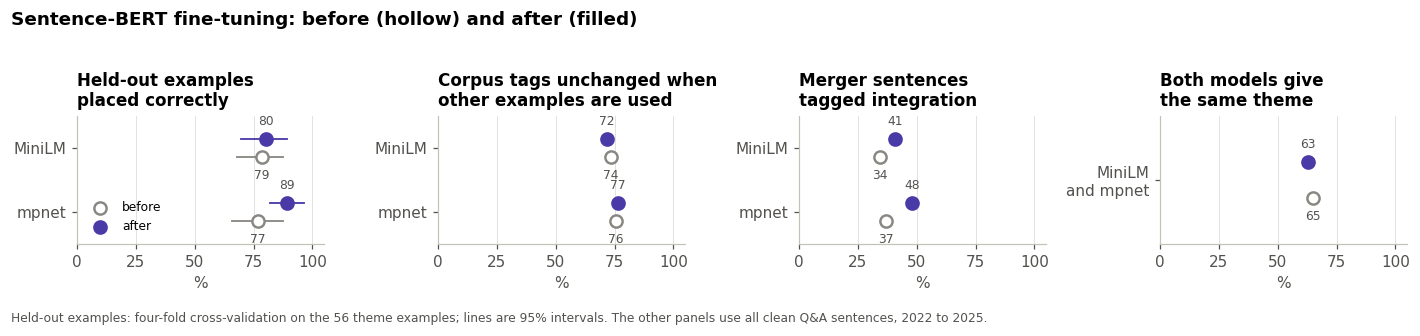

wrote themes_sentence.csv (10,059 sentences); fine-tuned models in sbert_themes_<model>/


In [37]:
# 5.3 the final fine-tuning: each model trained on all 56 examples, then the whole corpus tagged again. Before and
# after on real transcript sentences, the chart for the fine-tuning slide, and the final model by the rule above.
# Each fine-tuned model, its vectors and its theme centroids are saved; a later run reloads them.
loss_log, C_ft = {}, {}
for tag in MODELS:
    name = f"{tag}_finetuned"
    E = cached(name, qa["cache_key"])
    c_path, l_path = OUT / f"centroids_{name}.npy", OUT / f"finetune_loss_{tag}.csv"
    if E is not None and c_path.exists() and l_path.exists():
        C_ft[tag], loss_log[tag] = np.load(c_path), pd.read_csv(l_path)["loss"].tolist()
        print(f"{tag}: fine-tuned vectors loaded from emb_qa_{name}.npy")
    else:
        t0 = time.time()
        model, loss_log[tag] = fine_tune(tag, ex_text, ex_label)
        E = encode(model, qa["text"], batch_size=128)
        C_ft[tag] = centroids(encode(model, ex_text), ex_label)
        model.save(str(OUT / f"sbert_themes_{tag}"))
        save_vectors(name, E, qa["cache_key"])
        np.save(c_path, C_ft[tag])
        pd.Series(loss_log[tag], name="loss").to_csv(l_path, index=False)
        del model
        free_gpu()
        print(f"{tag}: {len(loss_log[tag])} steps in {time.time() - t0:.0f}s")
    print(f"{tag}: training loss {np.mean(loss_log[tag][:10]):.3f} (first 10 steps) to "
          f"{np.mean(loss_log[tag][-10:]):.3f} (last 10)")
    emb[name] = E
    qa[f"theme_ft_{tag}"], qa[f"margin_ft_{tag}"] = tag_themes(E, C_ft[tag])

rows = []
for stage, p in (("before", "base"), ("after", "ft")):
    both = qa[f"theme_{p}_MiniLM"] == qa[f"theme_{p}_mpnet"]
    for tag in MODELS:
        t = qa[f"theme_{p}_{tag}"]
        rows.append({"model": tag, "stage": stage,
                     "held-out examples right %": cv_summary.loc[(tag, stage), "accuracy %"],
                     "tags unchanged across folds %": cv_summary.loc[(tag, stage), "tags unchanged across folds %"],
                     "same theme as the other model %": 100 * both.mean(),
                     "merger sentences tagged integration %": 100 * (t[qa["merger_keyword"]] == "integration").mean(),
                     "other %": 100 * (t == "other").mean(),
                     "median margin": qa[f"margin_{p}_{tag}"].median()})
diag = pd.DataFrame(rows).set_index(["model", "stage"])
display(diag.round(1))
for stage, p in (("before", "base"), ("after", "ft")):
    print(f"MiniLM against mpnet, {stage} fine-tuning: kappa "
          f"{cohen_kappa_score(qa[f'theme_{p}_MiniLM'], qa[f'theme_{p}_mpnet']):.2f}")

acc = cv[cv["stage"] == "after"].groupby("model")["correct"].sum()
best, runner = acc.idxmax(), acc.idxmin()
CHOSEN = best if acc[best] - acc[runner] > 2 else diag.xs("after", level="stage")["tags unchanged across folds %"].idxmax()
print(f"held-out examples right after fine-tuning: {acc.to_dict()} of {len(ex_label)}  ->  chosen model: {CHOSEN}")

# chart: before (hollow, grey) and after (filled) for each check; lines are 95% intervals
STAGE_STYLE = {"before": {"facecolors": "white", "edgecolors": "#898781"},
               "after": {"facecolors": "#4a3aa7", "edgecolors": "#4a3aa7"}}
OFFSET = {"before": 0.14, "after": -0.14}

def before_after_dots(ax, values, title, intervals=None):
    # values: {row label: {stage: value}}; intervals: {row label: {stage: (low, high)}}
    for y, (label, v) in enumerate(values.items()):
        for stage in ("before", "after"):
            yy = y + OFFSET[stage]
            if intervals:
                lo, hi = intervals[label][stage]
                ax.plot([lo, hi], [yy, yy], color=STAGE_STYLE[stage]["edgecolors"], lw=1.2, zorder=2)
            ax.scatter([v[stage]], [yy], s=64, linewidths=1.6, zorder=3, label=stage if y == 0 else None,
                       **STAGE_STYLE[stage])
            up = stage == "after"                          # after-labels above, before-labels below
            ax.annotate(f"{v[stage]:.0f}", (v[stage], yy), xytext=(0, 7 if up else -8), textcoords="offset points",
                        ha="center", va="bottom" if up else "top", fontsize=8, color="#52514e")
    ax.set_yticks(range(len(values)), list(values))
    ax.set_ylim(len(values) - 0.5, -0.5)
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, 105)
    ax.set_xlabel("%")
    ax.set_title(title, loc="left")

def per_model(col):
    return {t: {s: diag.loc[(t, s), col] for s in ("before", "after")} for t in MODELS}

ci = {t: {s: tuple(cv_summary.loc[(t, s), ["95% low", "95% high"]]) for s in ("before", "after")} for t in MODELS}
fig, axes = plt.subplots(1, 4, figsize=(13, 2.9))
before_after_dots(axes[0], per_model("held-out examples right %"), "Held-out examples\nplaced correctly", ci)
before_after_dots(axes[1], per_model("tags unchanged across folds %"), "Corpus tags unchanged when\nother examples are used")
before_after_dots(axes[2], per_model("merger sentences tagged integration %"), "Merger sentences\ntagged integration")
before_after_dots(axes[3], {"MiniLM\nand mpnet": per_model("same theme as the other model %")["MiniLM"]},
                  "Both models give\nthe same theme")
axes[0].legend(loc="lower left", fontsize=8)
fig.suptitle("Sentence-BERT fine-tuning: before (hollow) and after (filled)", x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.005, "Held-out examples: four-fold cross-validation on the 56 theme examples; lines are 95% "
         "intervals. The other panels use all clean Q&A sentences, 2022 to 2025.", fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.05, 1, 0.95))
fig.savefig(FIG / "fig_5.3_finetuning.png", dpi=150, bbox_inches="tight")
plt.show()

qa["theme"] = qa[f"theme_ft_{CHOSEN}"]
qa[["key", "sentence_id", "call_type", "theme"] + [f"theme_{p}_{t}" for p in ("base", "ft") for t in MODELS]] \
    .to_csv(OUT / "themes_sentence.csv", index=False)
print(f"wrote themes_sentence.csv ({len(qa):,} sentences); fine-tuned models in sbert_themes_<model>/")

Fine-tunes both models on all 56 examples and picks mpnet by the rule fixed in advance (50 against 45 held-out examples right). On real sentences mpnet now sends more merger-keyword sentences to integration (48%, from 37%), which is what a merger reading needs.

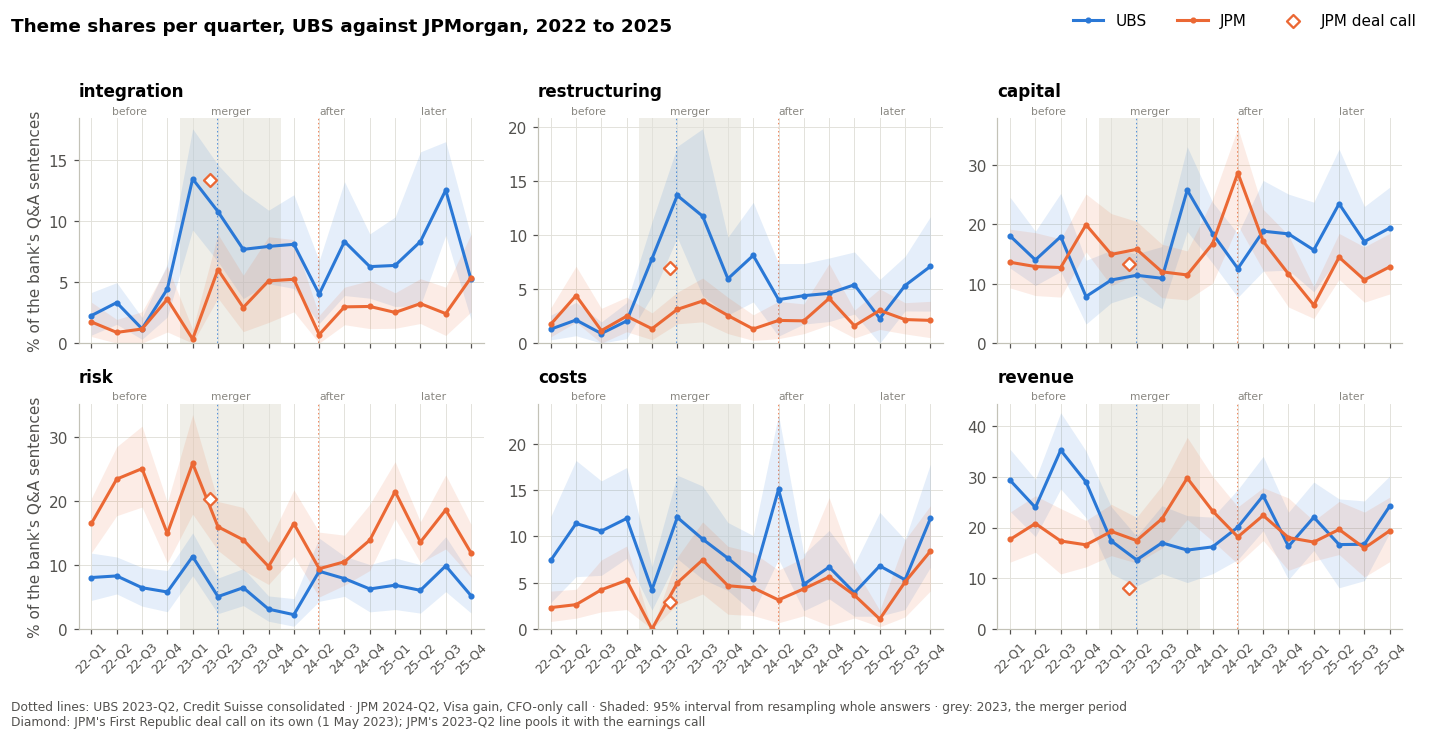

theme share by bank and period (% of sentences)


UBS                             JPM                  
              whole dataset  2022  2023  2024 whole dataset  2022  2023  2024
theme                                                                        
integration             6.7   2.8   9.9   6.8           3.1   1.9   3.8   3.1
restructuring           5.4   1.6   9.6   5.3           2.4   2.5   2.8   2.3
capital                16.1  14.6  15.4  17.2          14.4  15.0  14.0  18.4
risk                    6.8   7.3   6.3   6.3          16.3  19.6  16.7  12.6
costs                   8.7  10.4   8.4   7.8           4.2   3.6   4.4   4.4
revenue                21.7  29.1  15.8  19.7          19.5  18.1  21.1  20.9
other                  34.7  34.2  34.6  36.9          40.1  39.2  37.3  38.3

theme changes from 2022 to 2023 whose 95% interval excludes zero


,bank,theme,2022 %,2023 %,lo,hi,change,clear
0,UBS,integration,2.8,9.9,5.1,9.2,7.2,True
1,UBS,restructuring,1.6,9.6,5.4,10.7,8.0,True
5,UBS,revenue,29.1,15.8,-17.9,-9.1,-13.3,True
7,JPM,integration,1.9,3.8,0.3,3.5,1.9,True


theme changes from 2022 to 2024 whose 95% interval excludes zero


,bank,theme,2022 %,2024 %,lo,hi,change,clear
0,UBS,integration,2.8,6.8,1.9,6.0,4.0,True
1,UBS,restructuring,1.6,5.3,1.9,5.6,3.7,True
5,UBS,revenue,29.1,19.7,-13.9,-4.7,-9.4,True
10,JPM,risk,19.6,12.6,-10.7,-3.6,-7.0,True


themes whose change from 2022 differs between UBS and JPMorgan beyond the 95% interval (UBS minus JPMorgan, points)


,theme,UBS minus JPM 2023,lo 2023,hi 2023,clear 2023,UBS minus JPM 2024,lo 2024,hi 2024,clear 2024
0,integration,5.2,2.7,8.0,True,2.7,0.2,5.3,True
1,restructuring,7.7,4.9,10.7,True,3.9,1.8,6.2,True
3,risk,1.9,-2.6,6.3,False,6.0,1.8,10.0,True
5,revenue,-16.2,-22.2,-10.6,True,-12.2,-18.5,-6.3,True


In [38]:
# 5.4 theme shares per bank and quarter (fine-tuned tagger), with 95% intervals from resampling whole utterances.
# JPM 2023-Q2 pools the earnings call and the deal call; the diamond shows the deal call alone. Then the shares per
# period (the whole dataset, 2022, 2023 and 2024), the change from 2022 to 2023 and to 2024, and UBS's change
# minus JPMorgan's (the test of 4.14).
rng = np.random.default_rng(SEED)
records = []
for (b, q), g in qa.groupby(["bank", "quarter"]):
    point, boot = shares(g, "theme", THEMES, rng)
    lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)
    records += [{"bank": b, "quarter": q, "theme": t, "share": 100 * point[k], "lo": 100 * lo[k],
                 "hi": 100 * hi[k]} for k, t in enumerate(THEMES)]
prevalence = pd.DataFrame(records)
prevalence.round(2).to_csv(OUT / "theme_shares_bank_quarter.csv", index=False)
deal_themes = pd.Series(100 * shares(qa[qa["call_type"] == "event"], "theme", THEMES, rng)[0], index=THEMES)

fig, axes = plt.subplots(2, 3, figsize=(13, 6.6), sharex=True)
for ax, t in zip(axes.flat, [t for t in THEMES if t != "other"]):
    p = prevalence[prevalence["theme"] == t].set_index(["bank", "quarter"])
    for b in BANKS:
        s = p.xs(b, level="bank").reindex(QUARTERS)
        ax.fill_between(X, s["lo"], s["hi"], color=BANK_COLOR[b], alpha=0.12, lw=0)
        ax.plot(X, s["share"], color=BANK_COLOR[b], marker="o", ms=3, label=b)
    mark_event(ax, deal_themes[t])
    time_axis(ax, t)
    ax.set_ylim(bottom=0)
for ax in axes[:, 0]:
    ax.set_ylabel("% of the bank's Q&A sentences")
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper right", ncol=3)
fig.suptitle("Theme shares per quarter, UBS against JPMorgan, 2022 to 2025", x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.005, BREAK_NOTE + " · Shaded: 95% interval from resampling whole answers · grey: 2023, the merger period\n"
         + EVENT_NOTE + "; JPM's 2023-Q2 line pools it with the earnings call", fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.05, 1, 0.96))
fig.savefig(FIG / "fig_5.4_theme_shares.png", dpi=150, bbox_inches="tight")
plt.show()

PERIODS = {"whole dataset": YEARS, **{str(y): [y] for y in FOCUS_YEARS}}
theme_period = pd.concat({(b, p): 100 * qa[(qa["bank"] == b) & qa["year"].isin(yrs)]["theme"]
                          .value_counts(normalize=True).reindex(THEMES, fill_value=0)
                          for b in BANKS for p, yrs in PERIODS.items()}, axis=1)
theme_period.round(2).to_csv(OUT / "theme_shares_bank_period.csv")
print("theme share by bank and period (% of sentences)")
display(theme_period.round(1))
for w, y in (("merger", "2023"), ("after", "2024")):
    tm = window_change(qa, "theme", THEMES, "before", w, np.random.default_rng(SEED)).rename(
        columns={"topic": "theme", "before %": "2022 %", f"{w} %": f"{y} %"})
    tm.round(2).to_csv(OUT / f"theme_change_2022_to_{y}.csv", index=False)
    print(f"theme changes from 2022 to {y} whose 95% interval excludes zero")
    display(tm[tm["clear"]].round(1))
did_themes = ubs_minus_jpm(qa, "theme", THEMES, np.random.default_rng(SEED))      # the UBS-minus-JPMorgan test of 4.14
did_themes.round(2).to_csv(OUT / "ubs_minus_jpm_themes.csv", index=False)
print("themes whose change from 2022 differs between UBS and JPMorgan beyond the 95% interval (UBS minus JPMorgan, points)")
display(did_themes[did_themes["clear 2023"] | did_themes["clear 2024"]]
        [["theme", "UBS minus JPM 2023", "lo 2023", "hi 2023", "clear 2023", "UBS minus JPM 2024", "lo 2024", "hi 2024",
          "clear 2024"]].round(1))

Theme shares by quarter and per period. At UBS integration goes from 2.8% of its Q&A in 2022 to 9.9% in 2023 and 6.8% in 2024, restructuring from 1.6% to 9.6% and 5.3%, and revenue talk falls from 29% to 16% and 20%, all beyond normal variation. At JPMorgan integration rises only from 1.9% to 3.8% in 2023, and risk talk falls from 20% to 13% by 2024. Against JPMorgan, UBS's rise in integration (+5.2 points by 2023) and restructuring (+7.7) and its fall in revenue talk (-16.2) are its own, and they are still clear in 2024 (+2.7, +3.9, -12.2). The themes confirm the topic model's picture with a second, independent method.

adjusted mutual information, topics against themes: 0.25
sentences whose theme is their topic's main theme: 61.1%
main theme of the topics: {'integration': 1, 'restructuring': 0, 'capital': 4, 'risk': 1, 'costs': 1, 'revenue': 8, 'other': 2}
unassigned sentences by theme (%): {'integration': 5.2, 'restructuring': 4.7, 'capital': 14.7, 'risk': 13.7, 'costs': 7.9, 'revenue': 17.2, 'other': 36.4}
merger-related topics: share of their sentences the tagger calls integration (%) {'10: credit suisse, swiss, switzerland': np.float64(26.7)}


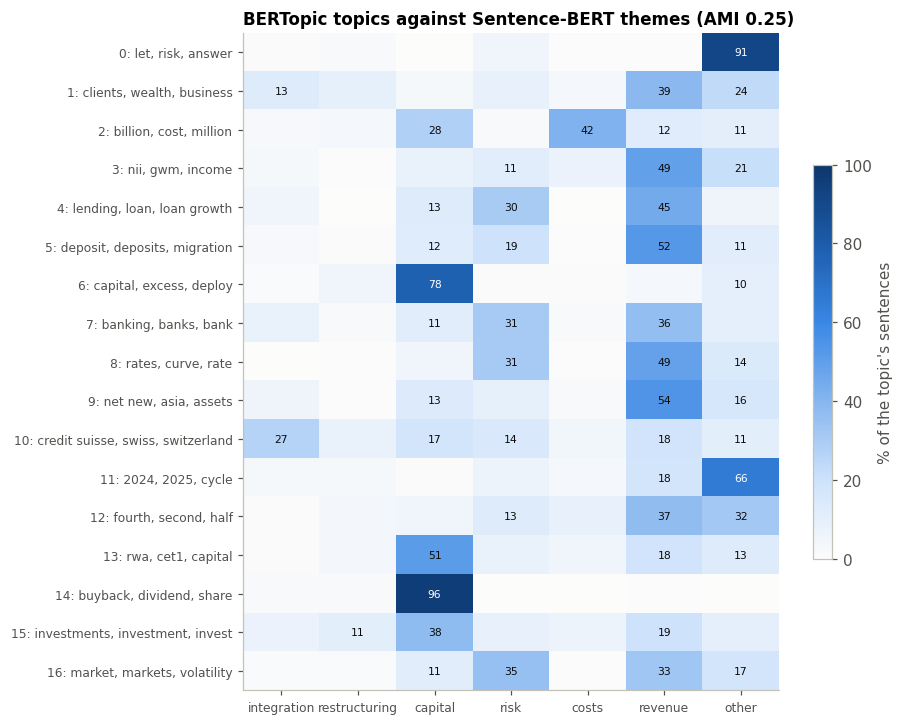


2022: main theme of the year topics: {'integration': 0, 'restructuring': 0, 'capital': 6, 'risk': 3, 'costs': 3, 'revenue': 13, 'other': 11}


,label,sentences,UBS %,JPM %,main theme,main theme %,merger-related
0,"2022-0: answer, let, second",335,10.0,15.2,other,97.6,False
1,"2022-1: nii, guidance, billion",92,4.3,2.6,revenue,41.3,False
2,"2022-2: loan, leverage, loan growth",92,2.3,4.7,revenue,38.0,False
3,"2022-3: forwards, strategy, forecast",87,3.4,3.1,other,66.7,False
4,"2022-4: billion, million, savings",86,3.5,2.9,capital,59.3,False
5,"2022-5: fourth, change, end fourth",82,3.4,2.8,other,50.0,False
6,"2022-6: rates, income, rate",72,1.8,3.7,revenue,59.7,False
7,"2022-7: deposit, deposits, betas",63,2.6,2.1,revenue,42.9,False
8,"2022-8: net new, assets, feegenerating",60,4.3,0.2,revenue,68.3,False
9,"2022-9: business, shape, consumer",59,2.3,2.1,other,30.5,False



2023: main theme of the year topics: {'integration': 0, 'restructuring': 0, 'capital': 2, 'risk': 1, 'costs': 1, 'revenue': 4, 'other': 3}


,label,sentences,UBS %,JPM %,main theme,main theme %,merger-related
0,"2023-0: point, let, trying",417,12.9,19.8,other,88.7,False
1,"2023-1: credit, credit suisse, bank",277,5.5,15.9,risk,34.3,True
2,"2023-2: billion, cost, revenue",256,15.2,5.6,costs,27.0,False
3,"2023-3: capital, market, pricing",152,6.1,6.0,capital,40.1,False
4,"2023-4: deposit, deposits, migration",109,2.4,6.0,revenue,55.0,False
5,"2023-5: rates, rate, higher",78,0.7,5.3,revenue,44.9,False
6,"2023-6: clients, client, services",74,3.9,2.0,revenue,24.3,False
7,"2023-7: cet1, rwa, return",72,4.7,1.2,capital,48.6,False
8,"2023-8: number, normalized, numbers",66,2.4,2.8,other,71.2,False
9,"2023-9: nii, billion, guidance",64,1.8,3.2,revenue,46.9,False



2024: main theme of the year topics: {'integration': 0, 'restructuring': 0, 'capital': 1, 'risk': 1, 'costs': 1, 'revenue': 3, 'other': 1}


,label,sentences,UBS %,JPM %,main theme,main theme %,merger-related
0,"2024-0: taking, let, answer",523,22.0,23.9,other,90.8,False
1,"2024-1: capital, business, wealth",238,11.3,10.1,capital,47.5,False
2,"2024-2: banking, clients, market",141,4.4,7.4,revenue,33.3,False
3,"2024-3: lending, private, credit",91,1.8,5.5,risk,41.8,False
4,"2024-4: cost, integration, ncl",79,5.5,2.2,costs,58.2,True
5,"2024-5: nii, deposit, nii ex",75,1.8,4.3,revenue,41.3,False
6,"2024-6: deposit, deposits, sweep",72,3.2,3.2,revenue,48.6,False


In [39]:
# 5.5 the most relevant topics described by the themes: how the whole-dataset topics spread over the themes, each
# topic's main theme, and the main theme of each year model's topics. Agreement is measured with adjusted mutual
# information (0 = no more than chance, 1 = the same grouping) on assigned sentences.
theme_mix = pd.crosstab(qa["topic"], qa["theme"], normalize="index").reindex(columns=THEMES, fill_value=0)
topic_table["main theme"] = theme_mix.idxmax(axis=1).reindex(topic_table.index)
topic_table["main theme %"] = 100 * theme_mix.max(axis=1).reindex(topic_table.index)
topic_table.round(3).to_csv(OUT / "topic_info.csv")
from sklearn.metrics import adjusted_mutual_info_score

assigned = qa[qa["topic"] != -1]
ct = pd.crosstab(assigned["topic"], assigned["theme"]).reindex(columns=THEMES, fill_value=0)
ct.to_csv(OUT / "topic_theme_crosstab.csv")
ami = adjusted_mutual_info_score(assigned["topic"], assigned["theme"])
print(f"adjusted mutual information, topics against themes: {ami:.2f}")
print(f"sentences whose theme is their topic's main theme: {100 * ct.max(axis=1).sum() / ct.to_numpy().sum():.1f}%")
print("main theme of the topics:", topic_table["main theme"].value_counts().reindex(THEMES, fill_value=0).to_dict())
print("unassigned sentences by theme (%):",
      (100 * qa.loc[qa["topic"] == -1, "theme"].value_counts(normalize=True)).reindex(THEMES).round(1).to_dict())
print("merger-related topics: share of their sentences the tagger calls integration (%)",
      {topic_label(t): round(100 * (qa.loc[qa["topic"] == t, "theme"] == "integration").mean(), 1) for t in MERGER_TOPICS})

rown = 100 * ct.loc[show].div(ct.loc[show].sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(8.5, 0.3 * len(show) + 1.6))
im = ax.imshow(rown.to_numpy(), aspect="auto", cmap=BLUES, vmin=0, vmax=100)
for (i, j), v in np.ndenumerate(rown.to_numpy()):
    if v >= 10:
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7, color="white" if v > 60 else "#0b0b0b")
ax.set_xticks(range(len(THEMES)), THEMES, fontsize=8)
ax.set_yticks(range(len(show)), [topic_label(t) for t in show], fontsize=8)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.6, label="% of the topic's sentences")
ax.set_title(f"BERTopic topics against Sentence-BERT themes (AMI {ami:.2f})", loc="left")
plt.tight_layout()
fig.savefig(FIG / "fig_5.5_topics_vs_themes.png", dpi=150, bbox_inches="tight")
plt.show()

for y, ym in year_models.items():
    s = ym["sentences"].merge(qa[["key", "theme"]], on="key")
    mix = pd.crosstab(s["year_topic"], s["theme"], normalize="index").reindex(columns=THEMES, fill_value=0)
    ym["table"]["main theme"] = mix.idxmax(axis=1).reindex(ym["table"].index)
    ym["table"]["main theme %"] = 100 * mix.max(axis=1).reindex(ym["table"].index)
    ym["table"].round(3).to_csv(OUT / f"year_topics_{y}.csv")
    print(f"\n{y}: main theme of the year topics:",
          ym["table"]["main theme"].value_counts().reindex(THEMES, fill_value=0).to_dict())
    display(ym["table"][["label", "sentences", "UBS %", "JPM %", "main theme", "main theme %", "merger-related"]].round(1))

Describes the topics by their themes. The 17 topics are mainly revenue (8), capital (4), other (2) and one each of integration, risk and costs; topics and themes agree only modestly (adjusted mutual information 0.25) because the topics are finer than the seven themes. Only 27% of the Credit Suisse topic is tagged integration, as the topic also holds Swiss business and capital talk. Each year model's topics get a main theme too, so every topic has a business reading.

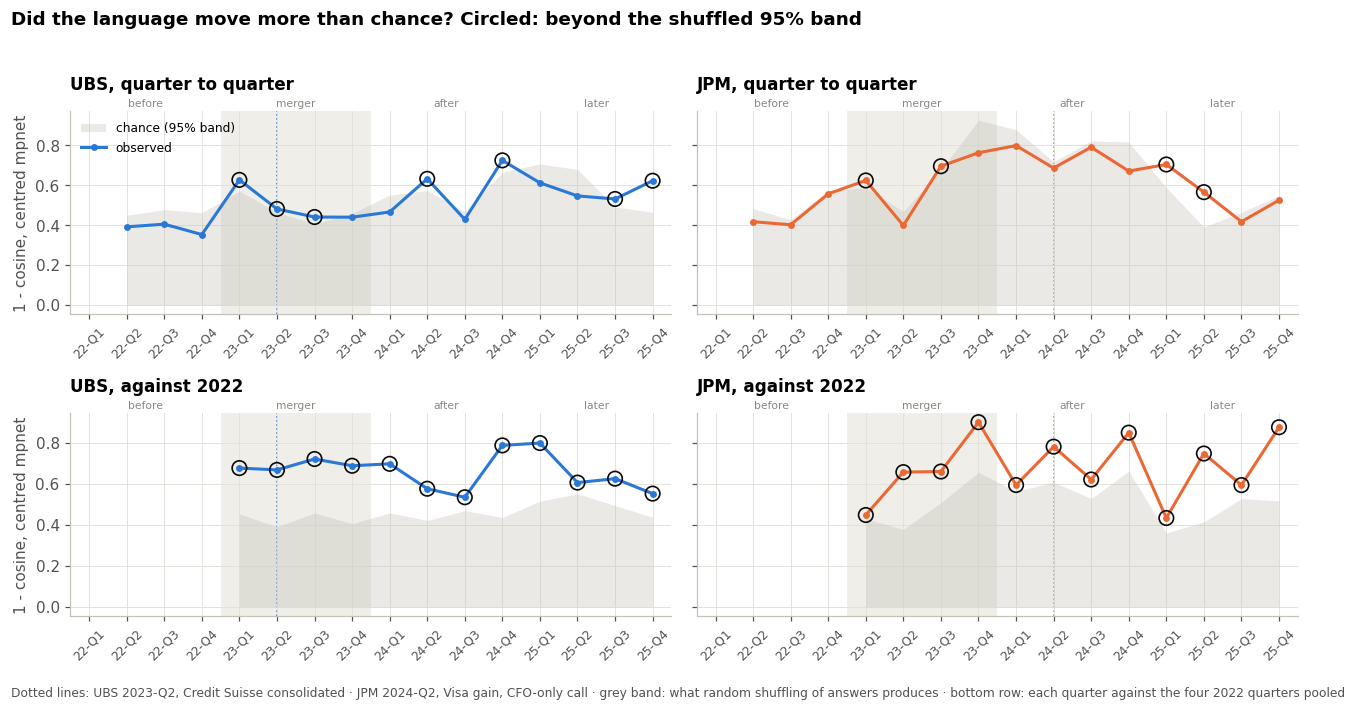

steps beyond chance, out of those tested


variant                  mpnet, pre-trained MiniLM, pre-trained  \
bank measure                                                      
UBS  quarter to quarter             7 of 15             7 of 15   
     against 2022                  12 of 12            12 of 12   
     window against 2022             3 of 3              3 of 3   
JPM  quarter to quarter             4 of 15             4 of 15   
     against 2022                  12 of 12            11 of 12   
     window against 2022             3 of 3              3 of 3   

variant                  mpnet, fine-tuned  \
bank measure                                 
UBS  quarter to quarter            7 of 15   
     against 2022                 12 of 12   
     window against 2022            3 of 3   
JPM  quarter to quarter            5 of 15   
     against 2022                  9 of 12   
     window against 2022            3 of 3   

variant                  mpnet, pre-trained, earnings calls only  
bank measure                                                      
UBS  quarter to quarter                                  7 of 15  
     against 2022                                       12 of 12  
     window against 2022                                  3 of 3  
JPM  quarter to quarter                                  4 of 15  
     against 2022                                       12 of 12  
     window against 2022                                  3 of 3

correlation of the excess over chance with the main run: {'MiniLM, pre-trained': np.float64(0.91), 'mpnet, fine-tuned': np.float64(0.86), 'mpnet, pre-trained, earnings calls only': np.float64(0.96)}
each window against 2022 (main run): distance, chance level and excess


observed  chance  chance 95%  excess  beyond chance
bank period                                                     
UBS  merger    0.6036  0.1530      0.2349  0.4506           True
     after     0.5236  0.1674      0.2442  0.3562           True
     later     0.5071  0.1721      0.2572  0.3350           True
JPM  merger    0.4778  0.2040      0.2818  0.2738           True
     after     0.5459  0.2500      0.3509  0.2959           True
     later     0.5515  0.1597      0.2288  0.3918           True

In [40]:
# 5.6 semantic drift, tested against chance. Embeddings are centred on the pooled mean, so the banking vocabulary
# both banks share cancels out, then averaged per group. Distance = 1 - cosine between two group centroids, and
# every distance is compared with the same measure after shuffling whole utterances between the two groups
# (500 times): only a value above the shuffled 95% band is a real change.
# Three questions: quarter to quarter; each quarter against 2022 (the year before the deals); and each window
# against 2022. The main run uses the chosen model's pre-trained vectors on purpose: drift should catch any change
# in language, not only change along the seven themes. Checks: the other model, the fine-tuned vectors, and the
# earnings calls alone (deal call left out).
N_SHUFFLE = 500
OTHER = next(t for t in MODELS if t != CHOSEN)
VARIANTS = {f"{CHOSEN}, pre-trained": (CHOSEN, qa.index),
            f"{OTHER}, pre-trained": (OTHER, qa.index),
            f"{CHOSEN}, fine-tuned": (f"{CHOSEN}_finetuned", qa.index),
            f"{CHOSEN}, pre-trained, earnings calls only": (CHOSEN, qa.index[qa["call_type"] == "earnings"])}
MAIN = next(iter(VARIANTS))

def utterance_sums(E, g):
    codes, units = pd.factorize(g["turn_id"])
    sums = np.zeros((len(units), E.shape[1]))
    np.add.at(sums, codes, E[g.index.to_numpy()])
    return sums, np.bincount(codes)

def distance_vs_chance(sums_a, n_a, sums_b, n_b, rng):
    # 1 - cosine between the two groups' centroids, and the same after shuffling utterances between the groups
    observed = 1 - unit(sums_a.sum(0) / n_a.sum()) @ unit(sums_b.sum(0) / n_b.sum())
    S, n = np.vstack([sums_a, sums_b]), np.concatenate([n_a, n_b])
    in_a = np.zeros((N_SHUFFLE, len(n)))
    for i in range(N_SHUFFLE):
        in_a[i, rng.permutation(len(n))[:len(n_a)]] = 1
    ca, cb = unit((in_a @ S) / (in_a @ n)[:, None]), unit(((1 - in_a) @ S) / ((1 - in_a) @ n)[:, None])
    null = 1 - (ca * cb).sum(axis=1)
    return observed, null.mean(), np.percentile(null, 97.5)

rng = np.random.default_rng(SEED)
drift_rows = []
for name, (tag, rows_used) in VARIANTS.items():
    used = qa.loc[rows_used]
    E = emb[tag] - emb[tag][used.index].mean(axis=0)
    parts = {(b, q): utterance_sums(E, g) for (b, q), g in used.groupby(["bank", "quarter"])}
    windows = {(b, w): utterance_sums(E, g) for (b, w), g in used.groupby(["bank", "window"])}
    for b in BANKS:
        for i, q in enumerate(QUARTERS):
            tests = {"against 2022": windows[b, "before"]} if q not in WINDOWS["before"] else {}
            if i > 0:
                tests["quarter to quarter"] = parts[b, QUARTERS[i - 1]]
            for measure, ref in tests.items():
                obs, chance, band = distance_vs_chance(*ref, *parts[b, q], rng)
                drift_rows.append({"variant": name, "bank": b, "measure": measure, "period": q,
                                   "observed": obs, "chance": chance, "chance 95%": band})
        for w in WINDOW_NAMES[1:]:
            obs, chance, band = distance_vs_chance(*windows[b, "before"], *windows[b, w], rng)
            drift_rows.append({"variant": name, "bank": b, "measure": "window against 2022", "period": w,
                               "observed": obs, "chance": chance, "chance 95%": band})
drift = pd.DataFrame(drift_rows)
drift["beyond chance"] = drift["observed"] > drift["chance 95%"]
drift["excess"] = drift["observed"] - drift["chance"]
drift.round(4).to_csv(OUT / "drift_bank_quarter.csv", index=False)

d = drift[drift["variant"] == MAIN]
fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), sharey="row")
for col, b in enumerate(BANKS):
    for row, measure in enumerate(["quarter to quarter", "against 2022"]):
        ax = axes[row, col]
        s = d[(d["bank"] == b) & (d["measure"] == measure)].set_index("period").reindex(QUARTERS)
        ax.fill_between(X, 0, s["chance 95%"], color="#c3c2b7", alpha=0.35, lw=0, label="chance (95% band)")
        ax.plot(X, s["observed"], color=BANK_COLOR[b], marker="o", ms=3.5, label="observed")
        hits = s["beyond chance"].eq(True).to_numpy()
        ax.scatter(X[hits], s["observed"].to_numpy()[hits], s=90, facecolors="none", edgecolors="#0b0b0b",
                   lw=1.1, zorder=3)
        time_axis(ax, f"{b}, {measure}", [b])
for ax in axes[:, 0]:
    ax.set_ylabel(f"1 - cosine, centred {CHOSEN}")
axes[0, 0].legend(loc="upper left", fontsize=8)
fig.suptitle("Did the language move more than chance? Circled: beyond the shuffled 95% band",
             x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.005, BREAK_NOTE + " · grey band: what random shuffling of answers produces · "
         "bottom row: each quarter against the four 2022 quarters pooled", fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.03, 1, 0.96))
fig.savefig(FIG / "fig_5.6_drift_vs_chance.png", dpi=150, bbox_inches="tight")
plt.show()

print("steps beyond chance, out of those tested")
display(drift.groupby(["bank", "measure", "variant"], sort=False)["beyond chance"]
        .agg(lambda s: f"{s.sum()} of {s.count()}").unstack("variant")[list(VARIANTS)])
wide = drift.pivot_table(index=["bank", "measure", "period"], columns="variant", values="excess")
print("correlation of the excess over chance with the main run:",
      {v: round(wide[MAIN].corr(wide[v]), 2) for v in VARIANTS if v != MAIN})
print("each window against 2022 (main run): distance, chance level and excess")
display(d[d["measure"] == "window against 2022"].set_index(["bank", "period"])
        [["observed", "chance", "chance 95%", "excess", "beyond chance"]].round(4))

Tests whether the overall wording moved more than random reshuffling of answers would produce. Against 2022, every later year differs beyond chance at both banks; quarter to quarter, UBS's wording moves beyond chance in 7 of 15 steps and JPMorgan's in 4 of 15, with the same result for the other model, the fine-tuned vectors and the earnings calls alone. UBS's distance from 2022 is largest in 2023 (0.60 against a chance level of 0.15): a third, model-free sign that its conversation changed most around the merger.

### Summary

The Sentence-BERT tagger, fine-tuned on 56 example sentences and checked on examples it never saw (50 of 56 right), reads every sentence against seven fixed themes. It confirms the topic model with an independent method: at UBS integration rises from 2.8% of the Q&A in 2022 to 9.9% in 2023 and stays at 6.8% in 2024, restructuring from 1.6% to 9.6% and 5.3%, while JPMorgan's integration share stays at 2% to 4% and its risk talk falls. Against JPMorgan, the rises in integration and restructuring are UBS's own in both years. Every topic of step 4 now also has a theme, and the wording itself moved beyond chance more often at UBS than at JPMorgan (7 of 15 quarter-to-quarter steps against 4); against 2022 it is further away at UBS only in 2023.

The fixed themes give a measure that can be tracked quarter by quarter and compared across banks, which is what supervision needs. How sure: the themes rest on a small set of examples and the two networks agree on only about two sentences in three, so the shares are read as directions and sizes, not exact values.

## 6. Topics against the team's sentiment labels

The sentiment track labels every sentence with three sentiment models (FinBERT, FinBERT-tone and RoBERTa). Its two output files, one per bank, sit in the data folder with the sentence key, and this section joins them to the topics and themes (the files also hold an emotion model, which is not used here). If the files change, only `LABEL_FILES` and `LABEL_DEFS` at the top of 6.1 need editing.

**Definition.** A sentence is negative when FinBERT calls it negative: FinBERT is the model trained on financial text and the one in the project's scope. A strict version counts a sentence as negative only when at least two of the three sentiment models agree. Two questions per bank, for 2022, 2023, 2024 and the three years together: which topics do the negative sentences talk about, and which topics are most often negative? 6.4 draws the slide chart, 6.5 checks the results, and 6.6 asks whether the quarters the sentiment models flagged also show a change in what was said.

**Limit.** The sentiment track's models read cleaned text, from which negations, numbers and many direction words are removed (for example "we don't expect a loss" reaches the model as "expect loss"). The labels used here carry that limit; they are the sentiment track's results, not a new sentiment model.

In [41]:
# 6.1 join the sentiment labels on the sentence key, and the share of negative sentences by bank and period under
# each definition, per year and for 2022 to 2024 together, with 95% intervals from resampling utterances.
# The labels are the sentiment group's own files, one per bank, in the data folder (read only). To use other files change
# LABEL_FILES and, if their columns differ, LABEL_DEFS: name used below -> (label column in the file, value that means negative).
LABEL_FILES = [DATA / f"sentiment_classification_output_{b}.csv" for b in BANKS]
LABEL_DEFS = {"neg_finbert": ("main_sentiment", "negative"),
              "neg_finbert_tone": ("FBT_Main_Sentiment", "Negative"),
              "neg_roberta": ("RBT_main_sentiment", "RBT_negative")}
missing_files = [p.name for p in LABEL_FILES if not p.exists()]
if missing_files:
    raise FileNotFoundError(f"label files {missing_files} are not in {DATA}: copy the sentiment group's output files there "
                            f"or set LABEL_FILES")
USE = KEY + ["section"] + [col for col, _ in LABEL_DEFS.values()]          # text columns are never read
for p in LABEL_FILES:
    absent = [c for c in USE if c not in pd.read_csv(p, nrows=0).columns]
    if absent:
        raise KeyError(f"{p.name} lacks the columns {absent}")
lab = pd.concat([pd.read_csv(p, usecols=USE) for p in LABEL_FILES], ignore_index=True)
lab["key"] = lab[KEY].astype(str).agg("|".join, axis=1)
assert lab["key"].is_unique, "the label files have more than one row for the same sentence key"
neg = pd.DataFrame({"key": lab["key"]})
for name, (col, value) in LABEL_DEFS.items():
    neg[name] = lab[col].astype(str).str.lower().eq(value.lower())
neg["neg_2of3"] = neg[list(LABEL_DEFS)].sum(axis=1) >= 2
qa = qa.drop(columns=[c for c in neg.columns if c != "key" and c in qa.columns])
qa = qa.merge(neg, on="key", how="left", validate="one_to_one")
unlabelled = qa["neg_finbert"].isna()
if unlabelled.any():
    raise ValueError(f"{int(unlabelled.sum()):,} of {len(qa):,} topic-corpus sentences have no label in the label files "
                     f"({len(lab):,} rows, sections {sorted(lab['section'].unique())}); "
                     f"first missing keys: {qa.loc[unlabelled, 'key'].head(3).tolist()}")
NEG = {"FinBERT (main)": "neg_finbert", "at least 2 of 3": "neg_2of3",
       "FinBERT-tone": "neg_finbert_tone", "RoBERTa": "neg_roberta"}

NEG_PERIODS = {**{str(y): [y] for y in FOCUS_YEARS}, "2022-24": FOCUS_YEARS}
rng = np.random.default_rng(SEED)
rows = []
for b in BANKS:
    for p, yrs in NEG_PERIODS.items():
        g = qa[(qa["bank"] == b) & qa["year"].isin(yrs)]
        for name, col in NEG.items():
            point, boot = shares(g, col, [False, True], rng)
            lo, hi = np.percentile(boot[:, 1], [2.5, 97.5])
            rows.append({"bank": b, "period": p, "definition": name, "negative %": 100 * point[1],
                         "range": f"{100 * lo:.1f} to {100 * hi:.1f}", "negative sentences": int(g[col].sum())})
neg_share = pd.DataFrame(rows)
neg_share.to_csv(OUT / "negative_share_bank_period.csv", index=False)
print(f"labels from {len(LABEL_FILES)} files ({len(lab):,} sentences, {', '.join(p.name for p in LABEL_FILES)}) "
      f"joined for all {len(qa):,} sentences of the topic corpus")
cols_p = pd.MultiIndex.from_product([BANKS, list(NEG_PERIODS)])
display(neg_share.pivot_table(index="definition", columns=["bank", "period"], values="negative %")
        .reindex(index=list(NEG), columns=cols_p).round(1))
display(neg_share[neg_share["definition"] == "FinBERT (main)"].set_index(["bank", "period"])
        [["negative %", "range", "negative sentences"]].reindex(cols_p))

labels from 2 files (16,513 sentences, sentiment_classification_output_UBS.csv, sentiment_classification_output_JPM.csv) joined for all 10,059 sentences of the topic corpus


UBS                     JPM                    
                2022 2023 2024 2022-24  2022  2023  2024 2022-24
definition                                                      
FinBERT (main)   5.5  5.9  6.5     5.9   8.7   8.1   6.8     7.8
at least 2 of 3  3.8  3.3  2.5     3.3   6.7   6.5   5.3     6.1
FinBERT-tone     8.4  7.7  6.6     7.7  12.9  15.2  12.8    13.6
RoBERTa          2.2  2.7  2.4     2.4   8.2   6.3   6.2     6.9

negative %        range  negative sentences
UBS 2022       5.498534   4.2 to 6.8                  75
    2023       5.931495   4.5 to 7.5                  71
    2024       6.531532   4.9 to 8.3                  58
    2022-24    5.914758   5.1 to 6.8                 204
JPM 2022       8.652374  7.1 to 10.2                 113
    2023       8.075472   6.5 to 9.7                 107
    2024       6.783370   5.5 to 8.2                  93
    2022-24    7.821089   6.9 to 8.7                 313

Joins the team's sentiment labels to all 10,059 sentences on the sentence key; every sentence finds its label. FinBERT calls 5.5% to 6.5% of UBS's Q&A sentences negative and 6.8% to 8.7% of JPMorgan's, with overlapping ranges across 2022, 2023 and 2024: negative tone is rare and its share did not clearly change. The four definitions differ in level, so comparisons stay within one definition.

FinBERT-negative sentences per bank and year: {'JPM': {2022: 113, 2023: 107, 2024: 93}, 'UBS': {2022: 75, 2023: 71, 2024: 58}}
same topic mix under the strict definition? correlation of the shares: {'UBS 2022': np.float64(0.97), 'UBS 2023': np.float64(0.94), 'UBS 2024': np.float64(0.83), 'UBS 2022-24': np.float64(0.96), 'JPM 2022': np.float64(0.99), 'JPM 2023': np.float64(0.97), 'JPM 2024': np.float64(0.99), 'JPM 2022-24': np.float64(0.99)}


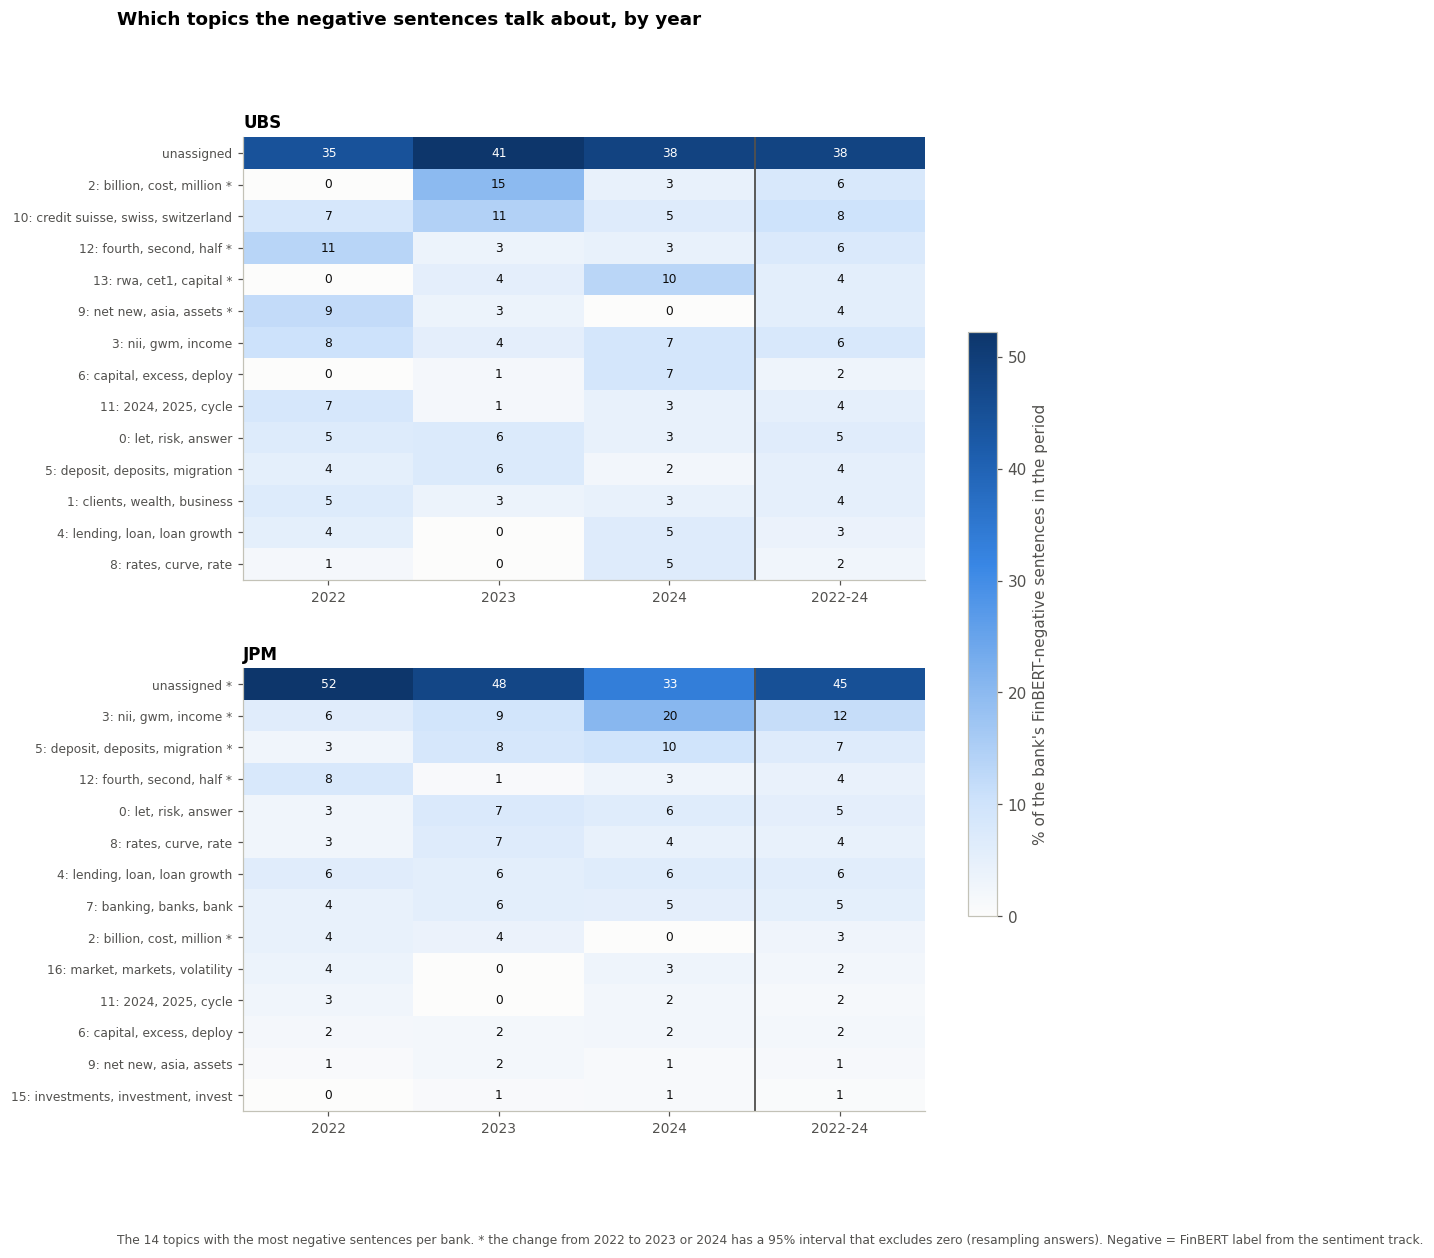

changes in the topic mix of negative sentences from 2022 to 2023 whose 95% interval excludes zero


label  2022  2023  2022 to 2023  lo 2023  \
bank topic                                                                 
UBS  2      2: billion, cost, million   0.0  15.5          15.5      7.0   
     12      12: fourth, second, half  10.7   2.8          -7.8    -16.3   
JPM  12      12: fourth, second, half   8.0   0.9          -7.0    -13.8   

            hi 2023  
bank topic           
UBS  2         25.4  
     12        -0.2  
JPM  12        -1.7

changes in the topic mix of negative sentences from 2022 to 2024 whose 95% interval excludes zero


label  2022  2024  2022 to 2024  \
bank topic                                                              
JPM  -1                          unassigned  52.2  33.3         -18.9   
      3                 3: nii, gwm, income   6.2  20.4          14.2   
UBS   13             13: rwa, cet1, capital   0.0  10.3          10.3   
      9            9: net new, asia, assets   9.3   0.0          -9.3   
JPM   5     5: deposit, deposits, migration   2.7   9.7           7.0   
      2           2: billion, cost, million   4.4   0.0          -4.4   

            lo 2024  hi 2024  
bank topic                    
JPM  -1       -32.3     -5.1  
      3         5.0     24.2  
UBS   13        1.8     20.4  
      9       -16.9     -3.7  
JPM   5         0.7     14.9  
      2        -9.2     -0.9

In [42]:
# 6.2 which topics the negative sentences talk about, per bank, in 2022, 2023, 2024 and the three years together: the
# topic mix of FinBERT-negative sentences (whole-dataset topics) with 95% intervals from resampling utterances, and the
# change from 2022 to 2023 and from 2022 to 2024. The strict definition (2 of 3 models) is the check.
def period_mix(col, rng, df=None):
    df = qa if df is None else df
    point, boot = {}, {}
    for b in BANKS:
        for p, yrs in NEG_PERIODS.items():
            g = df[(df["bank"] == b) & df["year"].isin(yrs) & df[col]]
            point[b, p], boot[b, p] = shares(g, "topic", TOPICS, rng)
    rows = []
    for b in BANKS:
        for k, t in enumerate(TOPICS):
            row = {"bank": b, "topic": t, **{p: 100 * point[b, p][k] for p in NEG_PERIODS}}
            for p in ("2023", "2024"):
                lo, hi = np.percentile(100 * (boot[b, p][:, k] - boot[b, "2022"][:, k]), [2.5, 97.5])
                row[f"2022 to {p}"] = row[p] - row["2022"]
                row[f"lo {p}"], row[f"hi {p}"] = lo, hi
                row[f"clear {p}"] = bool(lo > 0 or hi < 0)
            rows.append(row)
    return pd.DataFrame(rows).set_index(["bank", "topic"]), point, boot

neg_mix, neg_point, neg_boot = period_mix("neg_finbert", np.random.default_rng(SEED))
strict_mix, _, _ = period_mix("neg_2of3", np.random.default_rng(SEED))
neg_mix.insert(0, "label", [topic_label(t) for _, t in neg_mix.index])
neg_mix.round(2).to_csv(OUT / "negative_topics_by_period.csv")
print("FinBERT-negative sentences per bank and year:",
      qa[qa["neg_finbert"] & qa["year"].isin(FOCUS_YEARS)].groupby(["bank", "year"]).size().unstack().to_dict("index"))
print("same topic mix under the strict definition? correlation of the shares:",
      {f"{b} {p}": round(neg_mix.loc[b, p].corr(strict_mix.loc[b, p]), 2) for b in BANKS for p in NEG_PERIODS})

fig, axes = plt.subplots(2, 1, figsize=(10, 11.5))
for ax, b in zip(axes, BANKS):
    m = neg_mix.loc[b]
    m = m.loc[m[list(NEG_PERIODS)].max(axis=1).sort_values(ascending=False).index[:14]]
    mat = m[list(NEG_PERIODS)].to_numpy()
    im = ax.imshow(mat, aspect="auto", cmap=BLUES, vmin=0)
    for (i, j), v in np.ndenumerate(mat):
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8, color="white" if v > 0.6 * mat.max() else "#0b0b0b")
    ax.set_xticks(range(len(NEG_PERIODS)), list(NEG_PERIODS), fontsize=9)
    ax.set_yticks(range(len(m)), [topic_label(t) + (" *" if (m.at[t, "clear 2023"] or m.at[t, "clear 2024"]) else "")
                                  for t in m.index], fontsize=8)
    ax.axvline(2.5, color="#52514e", lw=1.2)
    ax.grid(False)
    ax.set_title(b, loc="left")
fig.colorbar(im, ax=axes, shrink=0.6, label="% of the bank's FinBERT-negative sentences in the period")
fig.suptitle("Which topics the negative sentences talk about, by year", x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.005, "The 14 topics with the most negative sentences per bank. * the change from 2022 to 2023 or 2024 has a "
         "95% interval that excludes zero (resampling answers). Negative = FinBERT label from the sentiment track.",
         fontsize=8, color="#52514e")
fig.savefig(FIG / "fig_6.2_negative_topics_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

for p in ("2023", "2024"):
    clear = neg_mix[neg_mix[f"clear {p}"]]
    print(f"changes in the topic mix of negative sentences from 2022 to {p} whose 95% interval excludes zero")
    display(clear.reindex(clear[f"2022 to {p}"].abs().sort_values(ascending=False).index)
            [["label", "2022", p, f"2022 to {p}", f"lo {p}", f"hi {p}"]].round(1))

Which topics the negative sentences are about, year by year. At UBS, costs go from none of the negative sentences in 2022 to 15.5% in 2023 (beyond normal variation) and back to 3.4% in 2024, when capital ratios rise to 10%; at JPMorgan, NII rises from 6% of negative sentences to 20% by 2024 and deposits from 3% to 10%. A stricter definition (two of three models agree) gives the same mix (correlation 0.83 to 0.99). The tone did not get more negative, but its subject moved: towards costs and then capital ratios at UBS, and towards NII and deposits at JPMorgan. Whether this follows the merger at UBS or interest rates at JPMorgan is a reading, not something tested here.

In [43]:
# 6.3 which topics are most often negative: the share of a topic's sentences that FinBERT calls negative, 2022 to 2024
# together (topics with at least 40 sentences at the bank); and the theme mix of the negative sentences per period
three = qa[qa["year"].isin(NEG_PERIODS["2022-24"])]
rate = (three.groupby(["bank", "topic"]).agg(sentences=("key", "size"), negative=("neg_finbert", "sum"))
        .query("sentences >= 40"))
rate["negative %"] = 100 * rate["negative"] / rate["sentences"]
rate.insert(0, "name", [topic_label(t) for _, t in rate.index])
rate.round(1).to_csv(OUT / "negative_rate_by_topic.csv")
for b in BANKS:
    print(f"{b}: the most and least negative topics, 2022 to 2024 "
          f"(rate for all its sentences {100 * three.loc[three['bank'] == b, 'neg_finbert'].mean():.1f}%)")
    r = rate.loc[b].sort_values("negative %", ascending=False)
    display(pd.concat([r.head(6), r.tail(3)]).round(1))

neg_themes = pd.concat({(b, p): 100 * qa[qa["neg_finbert"] & (qa["bank"] == b) & qa["year"].isin(yrs)]["theme"]
                        .value_counts(normalize=True).reindex(THEMES, fill_value=0)
                        for b in BANKS for p, yrs in NEG_PERIODS.items()}, axis=1)
neg_themes.round(2).to_csv(OUT / "negative_themes_by_period.csv")
print("theme mix of FinBERT-negative sentences (% of the bank's negative sentences in the period)")
display(neg_themes.round(1))

UBS: the most and least negative topics, 2022 to 2024 (rate for all its sentences 5.9%)


,name,sentences,negative,negative %
topic,,,,
12,"12: fourth, second, half",78,12,15.4
10,"10: credit suisse, swiss, switzerland",162,16,9.9
3,"3: nii, gwm, income",136,13,9.6
13,"13: rwa, cet1, capital",95,9,9.5
11,"11: 2024, 2025, cycle",86,8,9.3
5,"5: deposit, deposits, migration",98,8,8.2
0,"0: let, risk, answer",490,10,2.0
14,"14: buyback, dividend, share",65,1,1.5
7,"7: banking, banks, bank",44,0,0.0


JPM: the most and least negative topics, 2022 to 2024 (rate for all its sentences 7.8%)


,name,sentences,negative,negative %
topic,,,,
3,"3: nii, gwm, income",168,36,21.4
12,"12: fourth, second, half",67,13,19.4
5,"5: deposit, deposits, migration",151,21,13.9
7,"7: banking, banks, bank",129,16,12.4
4,"4: lending, loan, loan growth",176,19,10.8
16,"16: market, markets, volatility",70,7,10.0
14,"14: buyback, dividend, share",47,1,2.1
13,"13: rwa, cet1, capital",48,1,2.1
1,"1: clients, wealth, business",111,1,0.9


theme mix of FinBERT-negative sentences (% of the bank's negative sentences in the period)


UBS                       JPM                    
               2022  2023  2024 2022-24  2022  2023  2024 2022-24
theme                                                            
integration     0.0   0.0   5.2     1.5   0.9   3.7   4.3     2.9
restructuring   2.7  14.1   3.4     6.9   4.4   2.8   1.1     2.9
capital        10.7  16.9  22.4    16.2  15.0  16.8  14.0    15.3
risk           21.3  19.7  25.9    22.1  40.7  34.6  37.6    37.7
costs          16.0   9.9   8.6    11.8   5.3   3.7   2.2     3.8
revenue        38.7  26.8  24.1    30.4  25.7  28.0  28.0    27.2
other          10.7  12.7  10.3    11.3   8.0  10.3  12.9    10.2

Which topics are most often negative over 2022 to 2024: at JPMorgan NII (21% of its sentences negative), quarterly results (19%) and deposits (14%), against 7.8% overall; at UBS quarterly results (15%) and Credit Suisse (10%), against 5.9%. By theme, UBS's negative sentences lean to restructuring in 2023 (14%) and capital in 2024 (22%), while JPMorgan's stay mostly about risk (35% to 41%). These are the passages a supervisor would read first.

,subject,bank,topic,year,share %,lo,hi,sentences,negative sentences,change from 2022 beyond normal variation
0,UBS: costs,UBS,"2: billion, cost, million",2022,0.0,0.0,0.0,0,75,
1,UBS: costs,UBS,"2: billion, cost, million",2023,15.5,7.0,25.4,11,71,True
2,UBS: costs,UBS,"2: billion, cost, million",2024,3.4,0.0,8.9,2,58,False
3,JPMorgan: net interest income (NII),JPM,"3: nii, gwm, income",2022,6.2,2.4,11.1,7,113,
4,JPMorgan: net interest income (NII),JPM,"3: nii, gwm, income",2023,9.3,4.0,15.0,10,107,False
5,JPMorgan: net interest income (NII),JPM,"3: nii, gwm, income",2024,20.4,12.9,29.6,19,93,True


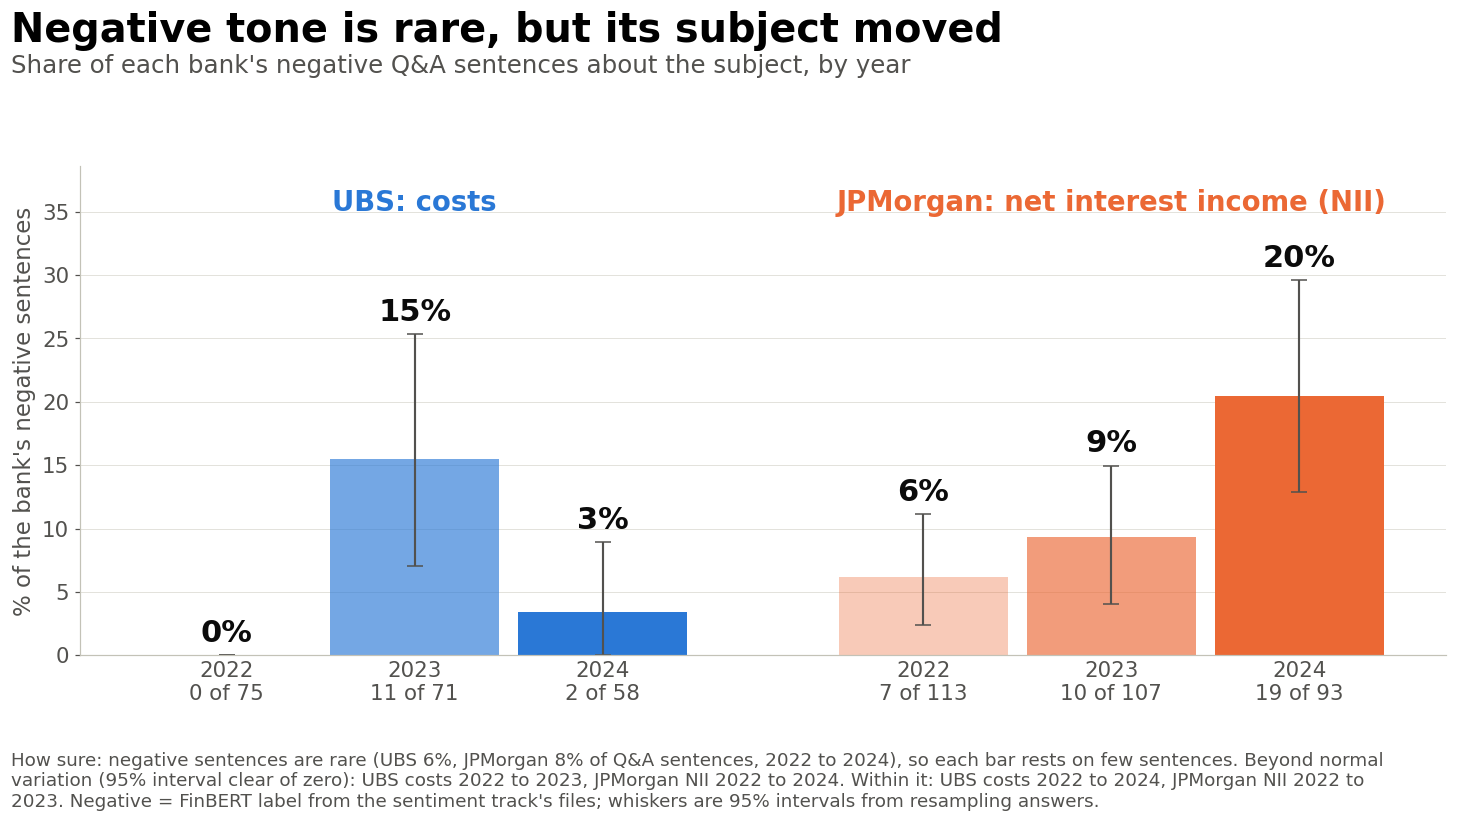

How sure: negative sentences are rare (UBS 6%, JPMorgan 8% of Q&A sentences, 2022 to 2024), so each bar rests on few sentences. Beyond normal variation (95% interval clear of zero): UBS costs 2022 to 2023, JPMorgan NII 2022 to 2024. Within it: UBS costs 2022 to 2024, JPMorgan NII 2022 to 2023. Negative = FinBERT label from the sentiment track's files; whiskers are 95% intervals from resampling answers.


In [44]:
# 6.4 the slide chart: the share of each bank's negative sentences about the subject that moved most, UBS costs and
# JPMorgan net interest income (NII), in 2022, 2023 and 2024. The topics are found by a top word, not by their number,
# so a rerun that renumbers the topics still finds them. Whiskers: 95% intervals from resampling answers; under each
# bar, the sentence count. The footnote says which changes from 2022 are beyond normal variation.
import textwrap

def topic_with(word):
    hits = [t for t in topic_table.index if word in words[t]]
    assert hits, f"no topic has '{word}' among its top words"
    return min(hits, key=lambda t: words[t].index(word))

S3 = [("UBS", topic_with("cost"), "UBS: costs"), ("JPM", topic_with("nii"), "JPMorgan: net interest income (NII)")]
YEARS3 = [str(y) for y in FOCUS_YEARS]
rows = []
for b, t, name in S3:
    k = TOPICS.index(t)
    for p in YEARS3:
        lo, hi = np.percentile(100 * neg_boot[b, p][:, k], [2.5, 97.5])
        g = qa[qa["neg_finbert"] & (qa["bank"] == b) & (qa["year"] == int(p))]
        rows.append({"subject": name, "bank": b, "topic": topic_label(t), "year": p, "share %": 100 * neg_point[b, p][k],
                     "lo": lo, "hi": hi, "sentences": int((g["topic"] == t).sum()), "negative sentences": len(g),
                     "change from 2022 beyond normal variation": "" if p == "2022" else bool(neg_mix.loc[(b, t), f"clear {p}"])})
s3 = pd.DataFrame(rows)
s3.round(2).to_csv(OUT / "S3_negative_subjects.csv", index=False)
display(s3.round(1))

fb = neg_share[neg_share["definition"] == "FinBERT (main)"].set_index(["bank", "period"])["negative %"]
beyond, within = [], []
for b, t, name in S3:
    short_name = "UBS costs" if b == "UBS" else "JPMorgan NII"
    for p in ("2023", "2024"):
        (beyond if neg_mix.loc[(b, t), f"clear {p}"] else within).append(f"{short_name} 2022 to {p}")
note = (f"How sure: negative sentences are rare (UBS {fb[('UBS', '2022-24')]:.0f}%, JPMorgan {fb[('JPM', '2022-24')]:.0f}% "
        f"of Q&A sentences, 2022 to 2024), so each bar rests on few sentences. Beyond normal variation (95% interval clear "
        f"of zero): {', '.join(beyond) or 'none'}. Within it: {', '.join(within) or 'none'}. Negative = FinBERT label from "
        f"the sentiment track's files; whiskers are 95% intervals from resampling answers.")

shade = dict(zip(YEARS3, (0.35, 0.65, 1.0)))
width = 0.27
fig, ax = plt.subplots(figsize=(13.33, 7.5))
ticks, ticklabels = [], []
for i, (b, t, name) in enumerate(S3):
    d = s3[s3["subject"] == name].set_index("year")
    for j, p in enumerate(YEARS3):
        x = i + (j - 1) * width
        v = d.at[p, "share %"]
        ax.bar(x, v, width=width * 0.9, color=BANK_COLOR[b], alpha=shade[p])
        ax.errorbar(x, v, yerr=[[v - d.at[p, "lo"]], [d.at[p, "hi"] - v]], color="#52514e", lw=1.4, capsize=5)
        ax.text(x, d.at[p, "hi"] + 0.6, f"{v:.0f}%", ha="center", va="bottom", fontsize=20, fontweight="bold",
                color="#0b0b0b")
        ticks.append(x)
        ticklabels.append(f"{p}\n{d.at[p, 'sentences']} of {d.at[p, 'negative sentences']}")
    ax.text(i, s3["hi"].max() + 5, name, ha="center", va="bottom", fontsize=18, fontweight="bold", color=BANK_COLOR[b])
ax.set_xticks(ticks, ticklabels, fontsize=14)
ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", labelsize=14)
ax.set_ylabel("% of the bank's negative sentences", fontsize=15)
ax.set_ylim(0, s3["hi"].max() + 9)
ax.grid(axis="x", visible=False)
fig.suptitle("Negative tone is rare, but its subject moved", x=0.01, y=0.98, ha="left", fontsize=26, fontweight="bold")
fig.text(0.01, 0.905, "Share of each bank's negative Q&A sentences about the subject, by year", fontsize=16,
         color="#52514e")
fig.text(0.01, 0.01, "\n".join(textwrap.wrap(note, 150)), fontsize=12, color="#52514e", va="bottom")
plt.tight_layout(rect=(0, 0.12, 1, 0.88))
fig.savefig(FIG / "fig_S3_negative_subjects.png", dpi=150)
plt.show()
print(note)

The slide chart: UBS costs and JPMorgan NII as a share of each bank's negative sentences in 2022, 2023 and 2024. UBS's negative cost talk belongs to the merger year (0%, 15.5%, 3.4%; the 2023 rise is beyond normal variation), and JPMorgan's concern about NII grew into 2024 (6.2%, 9.3%, 20.4%; the 2024 rise is beyond normal variation). The footnote says how sure: each bar rests on 58 to 113 negative sentences.

In [45]:
# 6.5 do the results depend on the courtesy and procedure sentences? The main results keep every sentence of the topic
# corpus, the same sentences the sentiment track labels. Here the sentences tagged in 1.4 and the topics whose main
# theme is "other" (conversation and procedure; rule fixed here, theme from 5.3) are left out, and three results are
# computed again: the before-and-after changes in the topic mix (4.5), the negative share (6.1) and the topic mix of
# the negative sentences per year (6.2). A result that keeps its direction and its range does not depend on them.
NONSUB = [t for t in topic_table.index if topic_table.at[t, "main theme"] == "other"]
core = qa[~qa["is_procedural"] & ~qa["topic"].isin(NONSUB)].reset_index(drop=True)
print(f"left out: {int(qa['is_procedural'].sum()):,} tagged sentences and {len(NONSUB)} topics "
      f"{[topic_label(t) for t in NONSUB]}; {len(core):,} of {len(qa):,} sentences remain")

moves_core = before_after(core, "topic", TOPICS, np.random.default_rng(SEED))
chk = moves[~moves["topic"].isin(NONSUB + [-1])].merge(moves_core, on=["bank", "topic"], suffixes=("", ", without"))
chk["same direction"] = np.sign(chk["change"]) == np.sign(chk["change, without"])
kept = chk[chk["clear"]]
print(f"(a) topic changes beyond their range in 4.5: {len(kept)}; without the left-out sentences they keep their "
      f"direction in {int(kept['same direction'].sum())} and stay beyond their range in "
      f"{int((kept['same direction'] & kept['clear, without']).sum())}")
chk.round(2).to_csv(OUT / "sensitivity_topic_changes.csv", index=False)

share_all = pd.Series({(b, p): 100 * qa[(qa["bank"] == b) & qa["year"].isin(yrs)]["neg_finbert"].mean()
                       for b in BANKS for p, yrs in NEG_PERIODS.items()})
share_core = pd.Series({(b, p): 100 * core[(core["bank"] == b) & core["year"].isin(yrs)]["neg_finbert"].mean()
                        for b in BANKS for p, yrs in NEG_PERIODS.items()})
print("(b) FinBERT-negative share, % of the bank's sentences in the period")
display(pd.DataFrame({"all sentences": share_all, "without": share_core, "difference": share_core - share_all}).round(1))

mix_core, _, _ = period_mix("neg_finbert", np.random.default_rng(SEED), core)
idx = [i for i in neg_mix.index if i[1] not in NONSUB + [-1]]
a_, c_ = neg_mix.loc[idx], mix_core.loc[idx]
for p in ("2023", "2024"):
    shown = a_[f"clear {p}"]
    same = np.sign(a_.loc[shown, f"2022 to {p}"]) == np.sign(c_.loc[shown, f"2022 to {p}"])
    print(f"(c) changes in the topic mix of negative sentences from 2022 to {p} beyond their range in 6.2: "
          f"{int(shown.sum())}; without the left-out sentences they keep their direction in {int(same.sum())} and stay "
          f"beyond their range in {int((same & c_.loc[shown, f'clear {p}']).sum())}")

left out: 293 tagged sentences and 2 topics ['0: let, risk, answer', '11: 2024, 2025, cycle']; 7,924 of 10,059 sentences remain
(a) topic changes beyond their range in 4.5: 7; without the left-out sentences they keep their direction in 7 and stay beyond their range in 7
(b) FinBERT-negative share, % of the bank's sentences in the period


all sentences  without  difference
UBS 2022               5.5      5.8         0.3
    2023               5.9      6.9         1.0
    2024               6.5      7.6         1.1
    2022-24            5.9      6.6         0.7
JPM 2022               8.7     10.6         2.0
    2023               8.1      9.4         1.4
    2024               6.8      8.0         1.2
    2022-24            7.8      9.3         1.5

(c) changes in the topic mix of negative sentences from 2022 to 2023 beyond their range in 6.2: 3; without the left-out sentences they keep their direction in 3 and stay beyond their range in 3
(c) changes in the topic mix of negative sentences from 2022 to 2024 beyond their range in 6.2: 5; without the left-out sentences they keep their direction in 5 and stay beyond their range in 4


Checks the results without the 293 courtesy sentences and the two topics with no subject of their own (7,924 sentences left). The topic changes of step 4 all hold; the negative share rises by 0.3 to 2.0 points because the left-out sentences are rarely negative; and the changes in the topics of negative sentences hold (3 of 3 for 2023, 4 of 5 stay beyond normal variation for 2024). The levels depend on what is counted, the comparisons do not.

### The quarters the sentiment models flagged

The team's sentiment analysis ran four models (FinBERT, FinBERT-tone, RoBERTa and an emotion model) on the same release and flagged six quarters where the tone changed. None of those changes was confirmed by more than two models at once. The last check asks whether the language itself also moved in those quarters: does the topic mix, the theme mix or the overall meaning (drift, 5.6) change more than chance from the quarter before? The same tests run on every other quarter, so the flagged quarters can be compared with a base rate.

In [46]:
# 6.6 quarter-to-quarter shift in the topic mix and the theme mix, tested against chance like the drift in 5.6:
# total variation distance (half the sum of absolute share differences) between two quarters, against the same
# measure after shuffling whole utterances between them 500 times. Then the six flagged quarters against the rest.
# the six quarters named in the sentiment group's report ("Sentiment Classification"); update if their list changes
FLAGGED = {("UBS", "2022-Q4"): "FinBERT-tone, prepared remarks",
           ("UBS", "2024-Q1"): "RoBERTa, more negative Q&A",
           ("UBS", "2025-Q4"): "RoBERTa, more negative Q&A",
           ("JPM", "2024-Q3"): "RoBERTa, more negative Q&A",
           ("JPM", "2025-Q1"): "RoBERTa, more negative Q&A",
           ("JPM", "2025-Q2"): "RoBERTa, more negative Q&A"}

def mix_shift_vs_chance(counts_a, counts_b, rng):
    tvd = lambda a, b: 0.5 * np.abs(a / a.sum(-1, keepdims=True) - b / b.sum(-1, keepdims=True)).sum(-1)
    observed = tvd(counts_a.sum(0), counts_b.sum(0))
    S = np.vstack([counts_a, counts_b])
    in_a = np.zeros((N_SHUFFLE, len(S)))
    for i in range(N_SHUFFLE):
        in_a[i, rng.permutation(len(S))[:len(counts_a)]] = 1
    null = tvd(in_a @ S, (1 - in_a) @ S)
    return observed, null.mean(), np.percentile(null, 97.5)

rng = np.random.default_rng(SEED)
shift_rows = []
for b in BANKS:
    for i in range(1, len(QUARTERS)):
        prev, q = QUARTERS[i - 1], QUARTERS[i]
        ga, gb = qa[(qa["bank"] == b) & (qa["quarter"] == prev)], qa[(qa["bank"] == b) & (qa["quarter"] == q)]
        row = {"bank": b, "quarter": q, "flagged": FLAGGED.get((b, q), "")}
        for col, cats in (("topic", TOPICS), ("theme", THEMES)):
            obs, chance, band = mix_shift_vs_chance(unit_counts(ga, col, cats), unit_counts(gb, col, cats), rng)
            row[f"{col} shift"], row[f"{col} beyond chance"] = obs, obs > band
            pa, pb = (100 * g[col].value_counts(normalize=True) for g in (ga, gb))
            diff = pb.reindex(cats, fill_value=0) - pa.reindex(cats, fill_value=0)
            top_move = diff.abs().idxmax()
            row[f"largest {col} move"] = (f"{topic_label(top_move) if col == 'topic' else top_move} "
                                          f"{diff[top_move]:+.1f} pts")
        dd = drift[(drift["variant"] == MAIN) & (drift["bank"] == b) & (drift["measure"] == "quarter to quarter")
                   & (drift["period"] == q)].iloc[0]
        row["drift beyond chance"] = bool(dd["beyond chance"])
        shift_rows.append(row)
shift = pd.DataFrame(shift_rows)
shift.round(4).to_csv(OUT / "sentiment_quarters_check.csv", index=False)

print("the six quarters flagged by the sentiment models")
display(shift[shift["flagged"] != ""].set_index(["bank", "quarter"])[
    ["flagged", "drift beyond chance", "topic beyond chance", "theme beyond chance",
     "largest topic move", "largest theme move"]])
tests = ["drift beyond chance", "topic beyond chance", "theme beyond chance"]
base_rate = shift.assign(group=np.where(shift["flagged"] != "", "flagged quarters", "other quarters")) \
            .groupby("group")[tests].agg(lambda s: f"{s.sum()} of {s.count()}")
print("how often the language moved beyond chance: flagged quarters against the rest")
display(base_rate)

the six quarters flagged by the sentiment models


flagged  drift beyond chance  \
bank quarter                                                        
UBS  2022-Q4  FinBERT-tone, prepared remarks                False   
     2024-Q1      RoBERTa, more negative Q&A                False   
     2025-Q4      RoBERTa, more negative Q&A                 True   
JPM  2024-Q3      RoBERTa, more negative Q&A                False   
     2025-Q1      RoBERTa, more negative Q&A                 True   
     2025-Q2      RoBERTa, more negative Q&A                 True   

              topic beyond chance  theme beyond chance  \
bank quarter                                             
UBS  2022-Q4                False                 True   
     2024-Q1                False                False   
     2025-Q4                False                 True   
JPM  2024-Q3                False                False   
     2025-Q1                False                False   
     2025-Q2                False                 True   

                                          largest topic move  \
bank quarter                                                   
UBS  2022-Q4           1: clients, wealth, business +9.2 pts   
     2024-Q1                   0: let, risk, answer +7.1 pts   
     2025-Q4  10: credit suisse, swiss, switzerland -9.9 pts   
JPM  2024-Q3                             unassigned -4.4 pts   
     2025-Q1                             unassigned +7.1 pts   
     2025-Q2             6: capital, excess, deploy +4.0 pts   

             largest theme move  
bank quarter                     
UBS  2022-Q4    other +11.3 pts  
     2024-Q1     other +7.4 pts  
     2025-Q4   revenue +7.5 pts  
JPM  2024-Q3  capital -11.5 pts  
     2025-Q1      risk +7.6 pts  
     2025-Q2   capital +8.1 pts

how often the language moved beyond chance: flagged quarters against the rest


,drift beyond chance,topic beyond chance,theme beyond chance
group,,,
flagged quarters,3 of 6,0 of 6,3 of 6
other quarters,8 of 24,4 of 24,4 of 24


Checks the six quarters the sentiment models flagged: the wording moved beyond chance in 3 of them (8 of the 24 other quarters), the theme mix in 3 of 6 (4 of 24) and the topic mix in none. Six quarters are too few to prove a link, and the clearest match is UBS 2025-Q4, when Credit Suisse talk dropped by 10 points. A weak result: tone flags and changes of subject only partly coincide.

### Summary

The team's sentiment labels were joined to the topics sentence by sentence. Negative tone is rare in the Q&A (about 6% of UBS's sentences and 8% of JPMorgan's) and its share did not clearly change between 2022, 2023 and 2024. What changed is its subject. At UBS, negative remarks about costs appear in the merger year (15.5% of negative sentences in 2023, none in 2022) and fade in 2024, when capital ratios take their place; at JPMorgan, negative remarks move to net interest income (6% in 2022, 20% in 2024) and to deposits. The results hold under a stricter definition of negative and without the courtesy sentences, while the sentiment flags of single quarters only partly coincide with changes in what was said.

How sure: each yearly share rests on 58 to 113 negative sentences, and the labels come from cleaned text in which negations can be lost, so these results point to where to read rather than measure a change in tone.

## 7. Findings and discoveries

Every number below is taken from the results above; nothing is typed by hand.

In [47]:
# 7.1 the findings in one table: what was found, the evidence (numbers from the cells above) and how sure we are
def pct(x):
    return f"{x:.1f}%"

F = []
tw = topic_win.set_index(["bank", "window", "topic"])["share"]
F.append({"step": "4.2, 4.3", "finding": "BERTopic finds the subjects of the Q&A without being told what to look for",
          "evidence": f"{len(topic_table)} topics (minimum cluster size {MIN_TOPIC}); "
                      f"{pct(100 * (qa['topic'] == -1).mean())} of sentences belong to no topic",
          "how sure": f"same topics with other random starts (ARI {tuning.at[MIN_TOPIC, 'agreement across seeds (ARI)']:.2f}); "
                      "sensitive to small changes in the text (4.9)"})
for t in MERGER_TOPICS:
    F.append({"step": "4.5, 4.6", "finding": f"The merger topic belongs to UBS ({topic_label(t)})",
              "evidence": "UBS " + ", ".join(f"{y} {pct(tw[('UBS', w, t)])}" for w, y in zip(WINDOW_NAMES, YEARS))
                          + f"; JPMorgan at most {pct(max(tw[('JPM', w, t)] for w in WINDOW_NAMES))}",
              "how sure": "the keyword search (2.4) and the integration theme (5.4) rise in the same year"})
um = moves[(moves["bank"] == "UBS") & moves["clear"] & (moves["topic"] != -1)]
F.append({"step": "4.5", "finding": "UBS's agenda changed from 2022 to 2024; JPMorgan's hardly did",
          "evidence": "UBS: " + "; ".join(f"{r['label']} {r['before %']:.1f}% to {r['after %']:.1f}%" for _, r in um.iterrows())
                      + f". JPMorgan: {int((moves['bank'].eq('JPM') & moves['clear'] & moves['topic'].ne(-1)).sum())} topic(s) beyond their range",
          "how sure": "95% intervals from resampling answers exclude zero; the same with every sentence given a topic (4.8)"})
for y, ym in year_models.items():
    only = matching[(matching["year"] == y) & matching["only in the year model"]]["year topic"].tolist()
    F.append({"step": "4.10, 4.11", "finding": f"{y} read on its own",
              "evidence": f"{len(ym['table'])} topics; subjects only this year's model finds: {', '.join(only) or 'none'}",
              "how sure": f"setting chosen by the rule (ARI of at least {MIN_ARI}); agreement with the whole-dataset "
                          f"model AMI {year_vs_whole.at[y, 'agreement with the whole model (AMI)']:.2f}"})
for b in BANKS:
    F.append({"step": "5.4", "finding": f"{b}: integration and restructuring themes by year",
              "evidence": "; ".join(f"{p}: integration {pct(theme_period.at['integration', (b, p)])}, "
                                    f"restructuring {pct(theme_period.at['restructuring', (b, p)])}" for p in YEARS3),
              "how sure": f"fine-tuned tagger places {acc[CHOSEN]} of {len(ex_label)} held-out examples correctly (5.2)"})
dq = drift[(drift["variant"] == MAIN) & (drift["measure"] == "quarter to quarter")].groupby("bank")["beyond chance"].agg(["sum", "count"])
F.append({"step": "5.6", "finding": "The wording of the calls moved more often at UBS than at JPMorgan",
          "evidence": "; ".join(f"{b}: {int(dq.at[b, 'sum'])} of {int(dq.at[b, 'count'])} quarter-to-quarter steps beyond chance" for b in BANKS),
          "how sure": "against 500 random reshuffles of the answers; the same with the other model and the fine-tuned vectors"})
F.append({"step": "6.1", "finding": "Negative tone is rare and its share did not clearly change",
          "evidence": "; ".join(f"{b}: " + " / ".join(pct(fb[(b, p)]) for p in YEARS3) for b in BANKS)
                      + " of Q&A sentences in 2022 / 2023 / 2024",
          "how sure": "the yearly ranges overlap; labels come from the sentiment track's cleaned text"})
for b, t, name in S3:
    d = s3[s3["subject"] == name].set_index("year")
    F.append({"step": "6.2, 6.4", "finding": f"Negative sentences about {name.split(': ')[1]} ({b})",
              "evidence": " / ".join(f"{p}: {d.at[p, 'share %']:.1f}% ({d.at[p, 'sentences']} of {d.at[p, 'negative sentences']})"
                                     for p in YEARS3),
              "how sure": "; ".join(f"2022 to {p} {'beyond' if neg_mix.loc[(b, t), f'clear {p}'] else 'within'} normal variation"
                                    for p in ("2023", "2024"))})
ga = gap[(gap["window"] == "all") & (gap["topic"] != -1) & ((gap["lo"] > 0) | (gap["hi"] < 0))]
for b in BANKS:
    top = ga[(ga["bank"] == b) & (ga["gap"] > 0)].sort_values("gap", ascending=False).head(2)
    F.append({"step": "4.7", "finding": f"{b}: what analysts ask about more than management talks about it",
              "evidence": ", ".join(f"{r['name']} (+{r['gap']:.1f} points)" for _, r in top.iterrows()) or "none beyond range",
              "how sure": "95% intervals from resampling answers exclude zero"})
tested = {y: int(content[f"p {y}"].notna().sum()) for y in ("2023", "2024")}
moved = {y: int(content[f"content changed {y}"].sum()) for y in ("2023", "2024")}
cs = content[(content["bank"] == "UBS") & content["topic"].isin(MERGER_TOPICS)]
F.append({"step": "4.13", "finding": "Topics changed what they are about, not only their size",
          "evidence": "; ".join(f"2022 to {y}: {moved[y]} of {tested[y]} bank-topic pairs" for y in ("2023", "2024"))
                      + "".join(f". UBS {r['label']}: 2022 '{r['words 2022']}', 2023 '{r['words 2023']}', 2024 '{r['words 2024']}'"
                                for _, r in cs.iterrows()),
          "how sure": "meaning of the sentences compared against 500 reshuffles of answers; corrected for multiple testing (5% false discovery rate)"})
for y in (2023, 2024):
    d = did_topics[did_topics[f"clear {y}"] & (did_topics["topic"] != -1)]
    d = d.reindex(d[f"UBS minus JPM {y}"].abs().sort_values(ascending=False).index)
    F.append({"step": "4.14", "finding": f"Topics that moved at UBS differently from JPMorgan, 2022 to {y}",
              "evidence": "; ".join(f"{r['label']} {r[f'UBS minus JPM {y}']:+.1f} points" for _, r in d.iterrows()) or "none",
              "how sure": "UBS's change minus JPMorgan's (difference-in-differences), 95% intervals from resampling answers"})
dt = did_themes[did_themes["clear 2023"] | did_themes["clear 2024"]]
F.append({"step": "5.4", "finding": "Themes that moved at UBS differently from JPMorgan",
          "evidence": "; ".join(f"{r['theme']} {r['UBS minus JPM 2023']:+.1f} points to 2023, {r['UBS minus JPM 2024']:+.1f} to 2024"
                                for _, r in dt.iterrows()) or "none",
          "how sure": "difference-in-differences, 95% intervals from resampling answers"})
findings = pd.DataFrame(F)
findings.to_csv(OUT / "findings.csv", index=False)
with pd.option_context("display.max_colwidth", 400):
    display(findings)

,step,finding,evidence,how sure
0,"4.2, 4.3",BERTopic finds the subjects of the Q&A without being told what to look for,17 topics (minimum cluster size 150); 40.5% of sentences belong to no topic,same topics with other random starts (ARI 0.93); sensitive to small changes in the text (4.9)
1,"4.5, 4.6","The merger topic belongs to UBS (10: credit suisse, swiss, switzerland)","UBS 2022 1.8%, 2023 7.9%, 2024 4.7%, 2025 6.3%; JPMorgan at most 0.2%",the keyword search (2.4) and the integration theme (5.4) rise in the same year
2,4.5,UBS's agenda changed from 2022 to 2024; JPMorgan's hardly did,"UBS: 1: clients, wealth, business 10.2% to 4.8%; 6: capital, excess, deploy 0.7% to 3.9%; 9: net new, asia, assets 8.3% to 1.7%; 10: credit suisse, swiss, switzerland 1.8% to 4.7%; 13: rwa, cet1, capital 1.1% to 3.5%. JPMorgan: 2 topic(s) beyond their range",95% intervals from resampling answers exclude zero; the same with every sentence given a topic (4.8)
3,"4.10, 4.11",2022 read on its own,"36 topics; subjects only this year's model finds: 2022-9: business, shape, consumer, 2022-10: productivity, advisors, financial, 2022-14: cecl, scb, reserve, 2022-17: cost, inflation, costs, 2022-20: flows, outflows, positive, 2022-21: taking, presentation, calling, 2022-22: fx, cost, exfx, 2022-28: recession, mild recession, probability, 2022-29: qt, rrp, deposits, 2022-30: 17, adverse, 17 ta...",setting chosen by the rule (ARI of at least 0.8); agreement with the whole-dataset model AMI 0.76
4,"4.10, 4.11",2023 read on its own,"11 topics; subjects only this year's model finds: 2023-8: number, normalized, numbers, 2023-10: taking, presentation, welcome",setting chosen by the rule (ARI of at least 0.8); agreement with the whole-dataset model AMI 0.74
5,"4.10, 4.11",2024 read on its own,7 topics; subjects only this year's model finds: none,setting chosen by the rule (ARI of at least 0.8); agreement with the whole-dataset model AMI 0.80
6,5.4,UBS: integration and restructuring themes by year,"2022: integration 2.8%, restructuring 1.6%; 2023: integration 9.9%, restructuring 9.6%; 2024: integration 6.8%, restructuring 5.3%",fine-tuned tagger places 50 of 56 held-out examples correctly (5.2)
7,5.4,JPM: integration and restructuring themes by year,"2022: integration 1.9%, restructuring 2.5%; 2023: integration 3.8%, restructuring 2.8%; 2024: integration 3.1%, restructuring 2.3%",fine-tuned tagger places 50 of 56 held-out examples correctly (5.2)
8,5.6,The wording of the calls moved more often at UBS than at JPMorgan,UBS: 7 of 15 quarter-to-quarter steps beyond chance; JPM: 4 of 15 quarter-to-quarter steps beyond chance,against 500 random reshuffles of the answers; the same with the other model and the fine-tuned vectors
9,6.1,Negative tone is rare and its share did not clearly change,UBS: 5.5% / 5.9% / 6.5%; JPM: 8.7% / 8.1% / 6.8% of Q&A sentences in 2022 / 2023 / 2024,the yearly ranges overlap; labels come from the sentiment track's cleaned text


Brings the main results into one table, each with its evidence and how sure we are, all computed from the cells above. It is the source for the report and the slides: any number quoted there can be traced back to a step of this notebook.

### Findings and discoveries

1. **The merger left a clear footprint at UBS and almost none at JPMorgan.** BERTopic's Credit Suisse topic grows from 1.8% of UBS's Q&A in 2022 to 7.9% in 2023 and is still 4.7% in 2024, with a new peak in 2025-Q3. The fixed themes agree (integration 2.8%, 9.9%, 6.8%), and so does a simple keyword count. At JPMorgan the merger shows only in its First Republic deal call and a small rise in integration talk in 2023.
2. **UBS's agenda moved and JPMorgan's hardly did; part of the change is UBS's own.** From 2022 to 2024 UBS talked less about wealth, clients and net new assets in Asia and more about Credit Suisse and capital. Measured against JPMorgan over the same years, the rises of the Credit Suisse topic and of capital ratios, the falls in wealth, clients and net new assets in Asia, and the rises of the integration and restructuring themes are UBS's own; the topic about spare capital and its use rose at both banks, so it is not. JPMorgan's own 2023 shift was towards deposits, banks and rates. UBS's wording also moved beyond chance more often (7 of 15 quarter-to-quarter steps against 4).
3. **Topics changed what they are about, not only their size.** 5 of 12 and 6 of 11 testable bank-topic pairs talk about different things in 2023 and 2024 than in 2022: UBS's costs topic moved from cost/income to costs and the 2026 horizon, and the Credit Suisse topic moved from Swiss business in 2022 to Credit Suisse itself.
4. **In the merger year the two banks talked about different things.** UBS about the takeover, costs and capital ratios; JPMorgan about deposits, banks, lending and rates. Modelled on its own, 2023 joins Credit Suisse with JPMorgan's banking talk, and 2024 shows UBS's integration costs and non-core unit.
5. **Negative tone is rare, but its subject moved.** About 6% of UBS's and 8% of JPMorgan's Q&A sentences are negative, with no clear change over the three years. UBS's negative remarks turned to costs in the merger year and to capital ratios after it; JPMorgan's turned to NII.
6. **Analysts push on guidance.** At both banks analysts ask about NII guidance more than management raises it, and at UBS also about capital ratios.

**What this means for the Bank.** The Q&A of results calls shows how long a merger stays on the agenda (for UBS, still above its 2022 level two years later) and which subjects carry the concern. Read with the sentiment labels, it points a supervisor to the passages worth reading: UBS's cost and capital remarks in 2023 and 2024, and JPMorgan's NII and deposit remarks in 2024.

**How sure.** Each finding is supported by at least two of the topic model, the fixed themes, the keyword count and the drift test, by ranges from resampling whole answers, and, for the changes, by the comparison with JPMorgan. The limits: 40.5% of sentences belong to no topic, the topic model is sensitive to small text changes, the themes rest on 56 examples, negative sentences are few, and two banks are not a sample of the sector. Nothing here proves cause.

## Next

- **Negative topics on raw text.** If the sentiment group moves its models to the raw sentence, put its new output files in the data folder under the same names and rerun step 6: negations would then reach the models, and the negative topics may change.
- **Emotion.** The labels file also holds the emotion model's labels. They could describe the negative topics further, as a description only, since that model was trained on tweets.
- **One topic model for the report.** Agree with the topics group which BERTopic setting goes into the final notebook, so the report shows one topic model and its tuning record.
- **Prepared remarks.** The tagger and the topic model can also read the prepared remarks, which would line up with the sentiment track's comparison of prepared remarks and Q&A.
- Before any commit: clear all outputs (public repository) and add only this notebook.